# Bitcoin Volatility Prediction
### Capstone Final Deliverable

**Name:** `Mohammed Hejairi`
**Topic:** Bitcoin (BTC) Hourly Volatility Prediction
**Cohort:** DSB `2`

---
This notebook is the complete, reproducible technical report: data acquisition (fetched once via CCXT, persisted to CSV, and re-read from disk from then on), cleaning, EDA, feature engineering, feature selection, four tuned models with documented improvement steps, a final model comparison, and a **live out-of-sample testing workflow** to validate predictions against real future data as it arrives.

## Introduction

This project builds an **hourly volatility forecasting pipeline for Bitcoin (BTC/USDT)**, using hourly OHLCV history pulled from Binance via [CCXT](https://docs.ccxt.com/) (as far back as Binance itself has - to 2026-01-01). The target is **7-day realized volatility** (rolling standard deviation of hourly returns over a 168-hour window), updated every hour — so the model is always answering "how turbulent has BTC been over the last week, as of right now, and how turbulent will it be next?"

Two design choices set this notebook apart from a typical one-off analysis:
1. **Data is fetched once and saved to CSV.** Every cell after the initial pull reads from that CSV, not from the live API — this makes the notebook fast to re-run, fully reproducible, and gives a fixed historical snapshot to train and evaluate on.
2. **A live testing section at the end** fetches a fixed, later period (2026-01-02 through yesterday) that was never part of the training data at all, and scores the saved models against it — real out-of-sample validation, not just a held-out slice of the same historical file. The target is also forecast **168 hours (7 days) ahead** rather than 1 hour ahead, matching the standard non-overlapping forecast horizon used in the realized-volatility literature.

## Problem Statement + Aim

**The Raw Issue:** Bitcoin's price swings unpredictably at short (hourly) timescales, and traders, exchanges, and risk desks have no reliable way to anticipate how turbulent the next stretch of trading will be — leading to mispriced risk, thin margin buffers, and poorly-timed position sizing.

**The Structured Objective** *(Specific — Business Objective — Measurable):*
We aim to predict Bitcoin's 7-day realized volatility (rolling standard deviation of hourly returns over a 168-hour window) **168 hours (7 days) ahead of the features used to predict it** - not the next hour's value, which barely differs from the current one and would trivially favor a naive forecast over genuine modeling (see Section 8.1 of the accompanying report). Features are lagged price/volume history and technical indicators (RSI, EMA, ATR, Bollinger width) sourced via the CCXT exchange API at hourly resolution. This gives traders and risk desks a continuous, hour-by-hour-updating estimate of next week's volatility usable directly in position-sizing and margin decisions, targeting an RMSE that beats both a naive-persistence baseline and a seasonality-aware Holt-Winters baseline.

**Problem Type: Regression.** Real downstream consumers of volatility — Black-Scholes option pricing (σ as a continuous input), Value-at-Risk, and position-sizing formulas — need an actual continuous volatility estimate, not a high/low category.

## Objectives
Key questions guiding the analysis and modeling:
- How does BTC's realized volatility behave over time at hourly resolution — is it clustered (calm stretches punctuated by spikes), and does that clustering persist across many hours (autocorrelation)?
- Does volatility differ systematically by hour-of-day or day-of-week (e.g. US/Asia/Europe session overlaps)?
- What engineered features (lagged returns, rolling volatility, volume changes, technical indicators) are most predictive of near-term volatility?
- How much does hyperparameter tuning improve each model over its untuned baseline?
- Does GARCH's asymmetric (leverage-effect) extension actually improve on plain GARCH(1,1) for BTC, the way it does for equities?
- **Does the best model, trained on years of history, actually generalize to real data collected months after training?** (Answered in the Live Testing section, not just estimated from a historical test split.)

**Type of Models:** Regression (continuous `volatility_7d`, computed on hourly data).
**Number of models:** 3 — all genuinely time-series-native: **GARCH-family** (GARCH(1,1) → EGARCH/GJR-GARCH), **HAR-RV** (→ HAR-RV-X), and **EWMA** (RiskMetrics λ=0.94 → backtested-tuned λ) — each built as a **basic/baseline** version and improved into a **tuned** version. Tabular ML models (Linear Regression, Random Forest, XGBoost) were deliberately excluded, and an LSTM originally explored in this slot was dropped in favor of EWMA: all three final models are explicitly finance-native (with a real econometric or risk-management pedigree), not generic sequence learners applied to a financial series.
**Evaluation Metrics:** RMSE, MAE, and R², compared against two baselines (naive-persistence, and seasonality-aware Holt-Winters exponential smoothing), using a strict time-based train/test split — plus a live/prospective evaluation on real future data.

# Data Inspection

## Data Dictionary

| Column        | Type    | Description |
| ------------- | ------- | ------- |
| Date          | datetime | timestamp of the hourly candle (crypto trades 24/7, no market close) |
| Open, High, Low, Close | float | OHLC price in USD |
| Volume        | float   | trading volume for the hour |
| hourly_return | float   | engineered: hour-over-hour percent change in Close |
| log_return    | float   | engineered: log(Close_t / Close_t-1), additive over time |
| volatility_7d | float   | engineered: rolling 168-hour (7-day) standard deviation of hourly_return, as of the CURRENT hour (a feature/regressor input, not the target - see `target` below) |
| target        | float   | engineered: `volatility_7d`, shifted 168 hours (7 days) into the future - **the actual prediction target** (Data Preprocessing, Section 6.1) |
| ma_7d         | float   | engineered: 168-hour (7-day) moving average of Close |
| volume_chg    | float   | engineered: hour-over-hour percent change in Volume |
| ema_12, ema_26, ema_spread | float | engineered: fast/slow EMA (12/26 hourly periods) and normalized spread — trend strength |
| rsi_14        | float   | engineered: 14-period Relative Strength Index (0-100) |
| atr_14        | float   | engineered: 14-period Average True Range, raw dollar terms — independent, range-based volatility measure (EDA/correlation use) |
| atr_pct       | float   | engineered: atr_14 / Close — the same signal, scale-free (used as a model regressor instead of atr_14; see HAR-RV-X below) |
| bb_width      | float   | engineered: Bollinger Band width (20-period) — second independent volatility proxy |
| macd_hist     | float   | engineered: MACD histogram — momentum-shift signal |
| hour_of_day   | int     | engineered (Feature Selection only): 0-23, tests for session-time effects on volatility |
| vol_bin       | category| engineered (Feature Selection only): Low/Medium/High tercile of volatility_7d, used for the chi-square test |

**Why CCXT, not yfinance:** `yfinance` is fundamentally an equity-market API — it returns `Dividends`/`Stock Splits` columns that are always 0 for crypto and carry no signal. CCXT pulls exchange-native OHLCV data directly from Binance.

**Why hourly technical-indicator periods (14, 20, 26) are NOT rescaled:** standard practice keeps RSI/ATR/Bollinger period counts as "last N candles" regardless of the underlying bar size — an "RSI-14" on hourly data means the last 14 hours, which is the correct, faster-reacting intraday signal. Only the **target's own window** (`volatility_7d`, `ma_7d`) is explicitly scaled to 168 hourly candles, because its name and real-world meaning ("7-day volatility") must stay fixed regardless of data granularity.

## Data Overview
Source, format, `.head()`, `.info()`, `.describe()`.

**Data pipeline design:** the cell below fetches hourly BTC/USDT data (as far back as Binance has, through 2026-01-01) via CCXT **once** and writes it to `btc_hourly_ohlcv.csv`. Every cell after this reads from that CSV file, not from the live API. This means: (a) re-running the notebook doesn't require re-fetching years of API calls, (b) the historical dataset used for training is a fixed, inspectable file, and (c) the *Live Testing* section near the end can cleanly distinguish "data used to train" (this CSV) from "brand new data fetched afterward" (a second, separate fetch).

In [1]:
# organize your imports in this cell
import os
import time
import joblib
import numpy as np
import pandas as pd
import ccxt
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from arch import arch_model  # GARCH-family volatility models

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

SYMBOL = 'BTC/USDT'
TIMEFRAME = '1h'
ROLLING_WINDOW = 24 * 7  # 168 hourly candles = 7 days - keeps "7-day volatility" meaning fixed
CSV_PATH = 'data/btc_hourly_ohlcv.csv'

# Forecast horizon: predict volatility_7d HORIZON hours ahead of the features, not 1 hour ahead.
# Set equal to ROLLING_WINDOW deliberately: the most recently known volatility_7d value and the
# target then share ZERO overlapping return observations (two adjacent, non-overlapping 168-hour
# windows), matching the standard non-overlapping forecast setup used in the realized-volatility
# literature - instead of the 99.4%-overlapping (and trivially easy) 1-hour-ahead version this
# notebook used previously, which produced a suspiciously high R-squared for reasons that had
# nothing to do with genuine forecasting skill.
HORIZON = ROLLING_WINDOW

# Fixed, reproducible date boundaries (rather than "N years back from whenever this happens to
# run"). Training covers as far back as Binance actually has BTC/USDT history (requested from
# 2010 - Bitcoin's own origin - but Binance itself didn't exist before mid-2017, so the fetch
# naturally starts wherever Binance's real history begins) through 2026-01-01. The test period
# then runs from 2026-01-02 through yesterday (2026-08-25) - chosen deliberately wide, not just
# one week, because a 168-hour-ahead forecast can only be scored once 168 real hours have
# elapsed: a longer test period means many more already-elapsed, already-scoreable predictions
# rather than the handful a single week would give right after moving to this longer horizon.
TRAIN_START = '2010-01-01T00:00:00Z'
TRAIN_END = '2026-01-01T00:00:00Z'
LIVE_TEST_START = '2026-01-02T00:00:00Z'
LIVE_TEST_END = '2026-08-26T00:00:00Z'  # exclusive - covers up through yesterday, 2026-08-25

# tz-naive Timestamp versions for comparisons against exchange data, which comes back tz-naive
# from pd.to_datetime(..., unit='ms') - comparing a tz-aware Timestamp (parsing the 'Z' suffix
# above makes pd.Timestamp UTC-aware) against a tz-naive column raises a TypeError.
TRAIN_END_TS = pd.Timestamp(TRAIN_END).tz_localize(None)
LIVE_TEST_START_TS = pd.Timestamp(LIVE_TEST_START).tz_localize(None)
LIVE_TEST_END_TS = pd.Timestamp(LIVE_TEST_END).tz_localize(None)

In [2]:
def fetch_ohlcv_history(exchange, symbol, timeframe='1h', since_ms=None, until_ms=None, limit=1000):
    """CCXT returns a max of `limit` candles per call, so we page forward in time
    using the timestamp of the last candle as the next `since` until we reach 'now'
    (or `until_ms`, if given - lets a caller fetch a bounded window without paging
    needlessly past it)."""
    all_candles = []
    since = since_ms
    while True:
        candles = exchange.fetch_ohlcv(symbol, timeframe=timeframe, since=since, limit=limit)
        if not candles:
            break
        all_candles += candles
        since = candles[-1][0] + 1
        if until_ms is not None and since >= until_ms:
            break
        if len(candles) < limit:
            break
        time.sleep(exchange.rateLimit / 1000)  # respect exchange rate limits
    return all_candles

exchange = ccxt.binance()

if not os.path.exists(CSV_PATH):
    since_ms = exchange.parse8601(TRAIN_START)
    until_ms = exchange.parse8601(TRAIN_END)
    candles = fetch_ohlcv_history(exchange, SYMBOL, timeframe=TIMEFRAME, since_ms=since_ms, until_ms=until_ms)
    df_raw = pd.DataFrame(candles, columns=['Timestamp', 'Open', 'High', 'Low', 'Close', 'Volume'])
    df_raw['Date'] = pd.to_datetime(df_raw['Timestamp'], unit='ms')
    df_raw = df_raw.drop(columns=['Timestamp']).sort_values('Date').reset_index(drop=True)
    df_raw = df_raw[df_raw['Date'] < TRAIN_END_TS].reset_index(drop=True)  # a page can overshoot the boundary
    df_raw.to_csv(CSV_PATH, index=False)
    print(f'Fetched {len(df_raw)} candles ({df_raw["Date"].min()} to {df_raw["Date"].max()}) and saved to {CSV_PATH}')
else:
    print(f'{CSV_PATH} already exists - skipping the API fetch (delete the file to re-fetch).')

data/btc_hourly_ohlcv.csv already exists - skipping the API fetch (delete the file to re-fetch).


In [3]:
# From here on, EVERYTHING reads from the saved CSV, not the live API.
df_raw = pd.read_csv(CSV_PATH, parse_dates=['Date'])
df_raw = df_raw.sort_values('Date').reset_index(drop=True)

print(f'Shape: {df_raw.shape}')
print(f'Date range: {df_raw["Date"].min()} to {df_raw["Date"].max()}')
print(f'\nColumn dtypes:\n{df_raw.dtypes}')
df_raw.describe()

Shape: (73284, 6)
Date range: 2017-08-17 04:00:00 to 2025-12-31 23:00:00

Column dtypes:
Open             float64
High             float64
Low              float64
Close            float64
Volume           float64
Date      datetime64[us]
dtype: object


,Open,High,Low,Close,Volume,Date
count,73284.000000,73284.000000,73284.000000,73284.000000,73284.000000,73284
mean,35949.327787,36096.957275,35794.369417,35950.459767,2608.847765,2021-10-26 05:19:49.831341
min,2870.900000,2950.000000,2817.000000,2919.000000,0.000000,2017-08-17 04:00:00
25%,9150.582500,9179.742500,9111.985000,9150.695000,769.646779,2019-09-23 08:45:00
50%,26094.465000,26155.500000,26045.675000,26094.905000,1416.939946,2021-10-27 04:30:00
75%,55835.060000,56232.417500,55473.935000,55836.847500,2756.036563,2023-11-29 14:15:00
max,126011.180000,126199.630000,125252.740000,126011.180000,137207.188600,2025-12-31 23:00:00
std,32093.539598,32191.267727,31992.452184,32093.899073,3921.479772,NaN


In [4]:
df_raw.head()

,Open,High,Low,Close,Volume,Date
0,4261.48,4313.62,4261.32,4308.83,47.181009,2017-08-17 04:00:00
1,4308.83,4328.69,4291.37,4315.32,23.234916,2017-08-17 05:00:00
2,4330.29,4345.45,4309.37,4324.35,7.229691,2017-08-17 06:00:00
3,4316.62,4349.99,4287.41,4349.99,4.443249,2017-08-17 07:00:00
4,4333.32,4377.85,4333.32,4360.69,0.972807,2017-08-17 08:00:00


## Data Cleaning
Handle missing values, outliers, and inconsistencies.

In [5]:
df = df_raw.copy()

# Engineer returns
df['hourly_return'] = df['Close'].pct_change()
df['log_return'] = np.log(df['Close'] / df['Close'].shift(1))
df['volume_chg'] = df['Volume'].pct_change()

# Zero-volume candles (real on thin low-liquidity hours, even for BTC occasionally on some
# exchanges) make pct_change() divide by zero, producing +/-inf, NOT NaN. inf silently survives
# a plain dropna() call, so it's neutralized here BEFORE any rolling calculation uses these
# columns - a rolling std() over a window containing even one inf just produces more inf.
inf_check_cols = ['hourly_return', 'log_return', 'volume_chg']
n_inf = np.isinf(df[inf_check_cols]).sum().sum()
df[inf_check_cols] = df[inf_check_cols].replace([np.inf, -np.inf], np.nan)
print(f'Infinite values found (zero-volume/zero-price candles) and converted to NaN: {n_inf}')

# Now safe to compute the rolling target
df['volatility_7d'] = df['hourly_return'].rolling(ROLLING_WINDOW).std()
df['ma_7d'] = df['Close'].rolling(ROLLING_WINDOW).mean()

print(f'\nMissing values per column:\n{df.isnull().sum()}')

Infinite values found (zero-volume/zero-price candles) and converted to NaN: 4

Missing values per column:
Open               0
High               0
Low                0
Close              0
Volume             0
Date               0
hourly_return      1
log_return         1
volume_chg         5
volatility_7d    168
ma_7d            167
dtype: int64


In [6]:
def compute_indicators(df):
    """Technical indicators, computed manually (not via a library) so every formula is
    transparent. Period counts (12/26/14/20) are kept as raw candle counts, not rescaled for
    hourly data - see the Data Dictionary note on why."""
    close, high, low = df['Close'], df['High'], df['Low']

    ema_12 = close.ewm(span=12, adjust=False).mean()
    ema_26 = close.ewm(span=26, adjust=False).mean()
    df['ema_12'] = ema_12
    df['ema_26'] = ema_26
    df['ema_spread'] = (ema_12 - ema_26) / close

    delta = close.diff()
    gain = delta.clip(lower=0).rolling(14).mean()
    loss = (-delta.clip(upper=0)).rolling(14).mean()
    rs = gain / loss
    df['rsi_14'] = 100 - (100 / (1 + rs))

    prev_close = close.shift(1)
    true_range = pd.concat([
        high - low, (high - prev_close).abs(), (low - prev_close).abs()
    ], axis=1).max(axis=1)
    df['atr_14'] = true_range.rolling(14).mean()
    # Scale-free version for use as a MODEL regressor: atr_14 is in raw dollar terms (mean
    # ~$300, up to ~$3,200 across this history), while every volatility regressor it would sit
    # alongside (volatility_7d and anything derived from it) is a small fraction (~0.001-0.03).
    # Worse, BTC's own price ranges from ~$4,000 to ~$90,000+ across this dataset, so a given
    # dollar ATR means wildly different things at different points in history - not even a
    # stable signal on its own terms. Dividing by Close fixes both problems at once.
    df['atr_pct'] = df['atr_14'] / close

    bb_mid = close.rolling(20).mean()
    bb_std = close.rolling(20).std()
    df['bb_width'] = ((bb_mid + 2 * bb_std) - (bb_mid - 2 * bb_std)) / bb_mid

    macd_line = ema_12 - ema_26
    signal_line = macd_line.ewm(span=9, adjust=False).mean()
    df['macd_hist'] = macd_line - signal_line
    return df

df = compute_indicators(df)
indicator_cols = ['ema_spread', 'rsi_14', 'atr_14', 'bb_width', 'macd_hist']
print('Missing values in new indicator columns:')
print(df[indicator_cols].isnull().sum())

Missing values in new indicator columns:
ema_spread     0
rsi_14        14
atr_14        13
bb_width      19
macd_hist      0
dtype: int64


In [7]:
# The only remaining missing values are structural warm-up periods (up to 26 rows, for the
# 26-period EMA / 20-period Bollinger window) - there's no "before the start of history" to
# impute, so these rows are dropped rather than filled.
feature_cols = [
    'Open', 'High', 'Low', 'Close', 'Volume', 'hourly_return', 'log_return',
    'volatility_7d', 'ma_7d', 'volume_chg', 'ema_12', 'ema_26', 'ema_spread',
    'rsi_14', 'atr_14', 'atr_pct', 'bb_width', 'macd_hist'
]
df_clean = df.dropna(subset=feature_cols).reset_index(drop=True)

print(f'Rows with non-positive price: {(df_clean[["Open","High","Low","Close"]] <= 0).any(axis=1).sum()}')

# Extreme-move outliers (flash crashes, etc.) are expected and retained as genuine signal for a
# volatility model - flagging via IQR for awareness, not removal.
q1, q3 = df_clean['hourly_return'].quantile([0.25, 0.75])
iqr = q3 - q1
extreme = ((df_clean['hourly_return'] < q1 - 3 * iqr) | (df_clean['hourly_return'] > q3 + 3 * iqr))
print(f'Extreme hourly-return outliers (retained, IQR x3): {extreme.sum()} of {len(df_clean)} rows')
print(f'Shape after cleaning: {df_clean.shape}')

Rows with non-positive price: 0
Extreme hourly-return outliers (retained, IQR x3): 2632 of 73112 rows
Shape after cleaning: (73112, 19)


# Exploratory Data Analysis (EDA)
Trends, relationships, anomalies; univariate, bivariate, and multivariate analysis; correlation matrix.

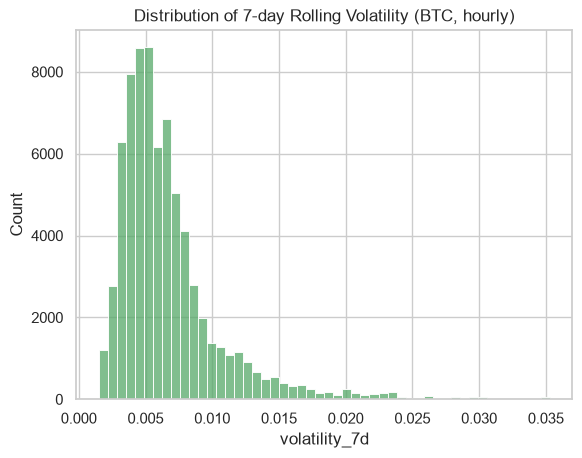

count    73112.000000
mean         0.006734
std          0.004049
min          0.001509
25%          0.004217
50%          0.005682
75%          0.007789
max          0.035301
Name: volatility_7d, dtype: float64


In [8]:
# Univariate: target distribution
target_column = 'volatility_7d'
sns.histplot(df_clean[target_column], bins=50, color='#55A868')
plt.title('Distribution of 7-day Rolling Volatility (BTC, hourly)')
plt.xlabel('volatility_7d')
plt.show()
print(df_clean[target_column].describe())

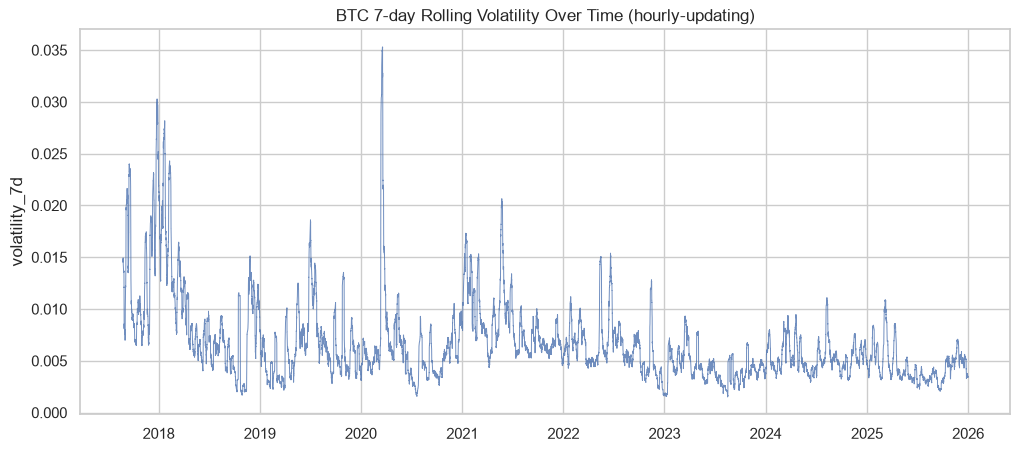

In [9]:
# Volatility over time
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df_clean['Date'], df_clean['volatility_7d'], color='#4C72B0', alpha=0.8, linewidth=0.7)
ax.set_title('BTC 7-day Rolling Volatility Over Time (hourly-updating)')
ax.set_ylabel('volatility_7d')
plt.show()

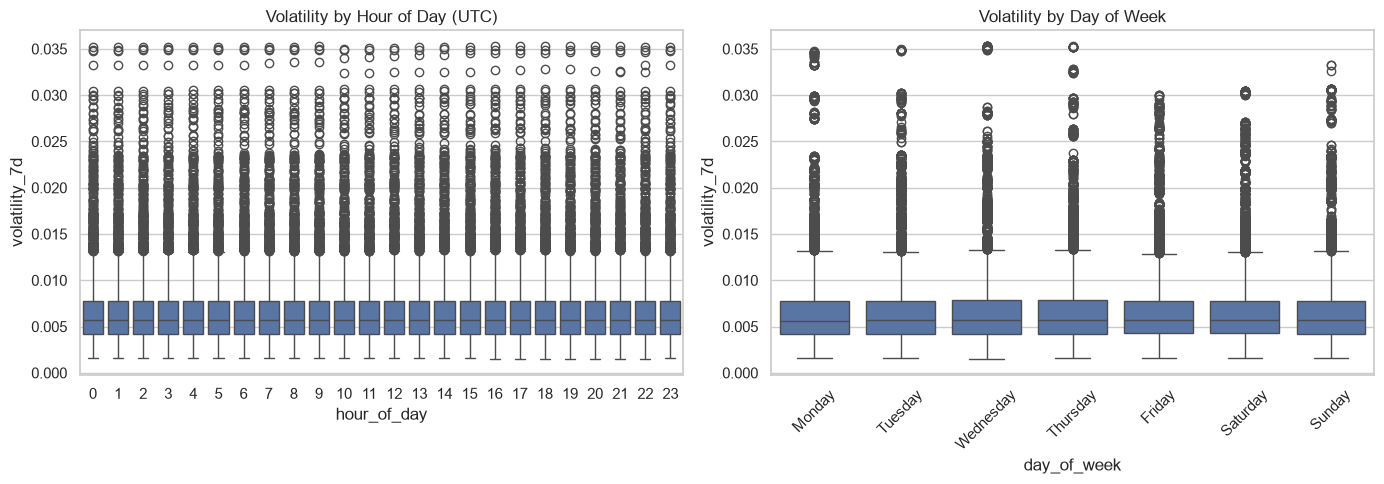

In [10]:
# Bivariate: does volatility differ by hour-of-day or day-of-week? (session-time effects)
df_clean['hour_of_day'] = df_clean['Date'].dt.hour
df_clean['day_of_week'] = df_clean['Date'].dt.day_name()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df_clean, x='hour_of_day', y='volatility_7d', ax=axes[0])
axes[0].set_title('Volatility by Hour of Day (UTC)')
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.boxplot(data=df_clean, x='day_of_week', y='volatility_7d', order=day_order, ax=axes[1])
axes[1].set_title('Volatility by Day of Week')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

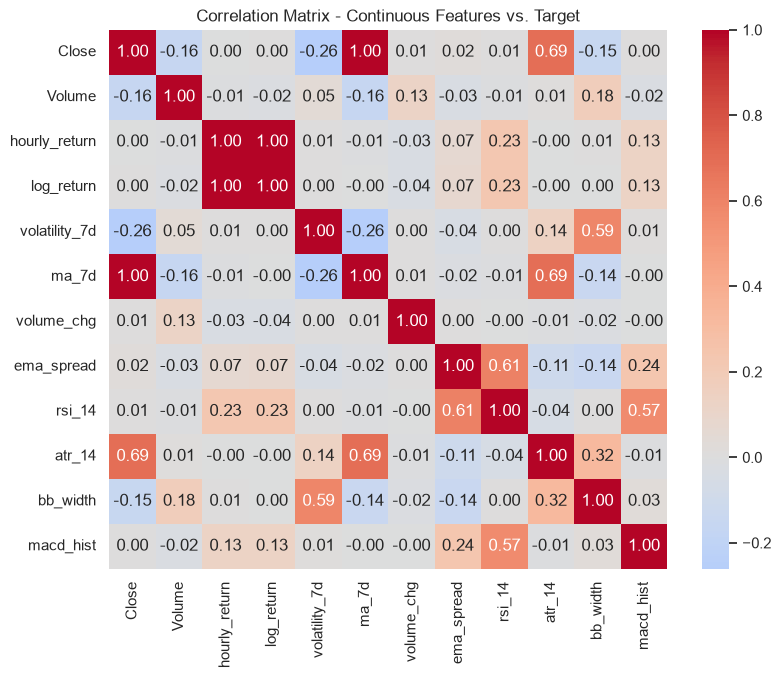

Correlation with target (volatility_7d):
volatility_7d    1.000000
bb_width         0.588440
atr_14           0.141964
Volume           0.049408
macd_hist        0.013301
hourly_return    0.009777
log_return       0.004448
rsi_14           0.004199
volume_chg       0.002048
ema_spread      -0.043600
ma_7d           -0.257734
Close           -0.260844
Name: volatility_7d, dtype: float64


In [11]:
# Correlation matrix for continuous columns
corr_cols = [
    'Close', 'Volume', 'hourly_return', 'log_return', 'volatility_7d', 'ma_7d', 'volume_chg',
    'ema_spread', 'rsi_14', 'atr_14', 'bb_width', 'macd_hist'
]
corr = df_clean[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix - Continuous Features vs. Target')
plt.show()
print(f'Correlation with target ({target_column}):')
print(corr[target_column].sort_values(ascending=False))

## Autocorrelation Check
Before modeling, we check whether `volatility_7d` is autocorrelated (related to its own past values — "volatility clustering"). This justifies using lagged/rolling features and is the statistical property GARCH is built to model.

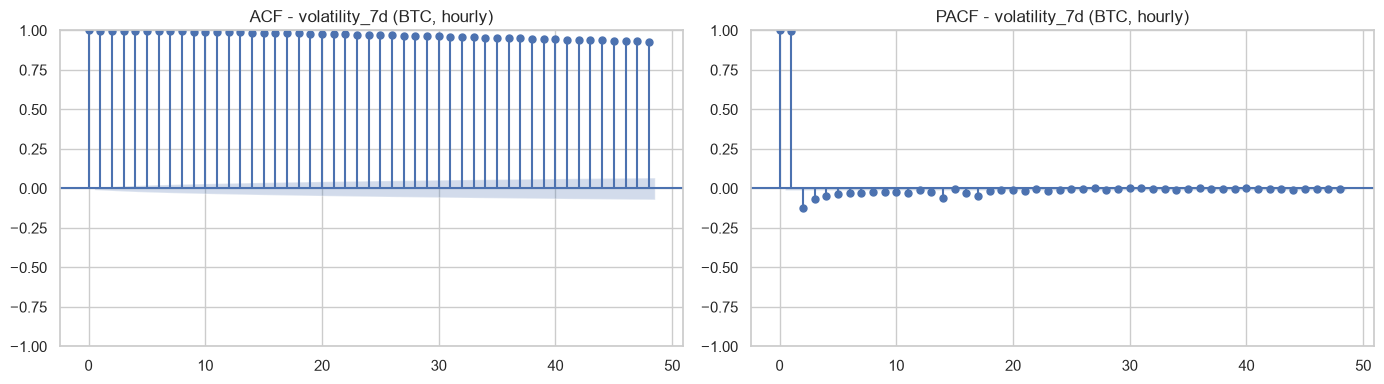

ADF Statistic: -9.2422, p-value: 0.0000
-> Stationary (reject unit root)


In [12]:
series = df_clean['volatility_7d'].reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(series, lags=48, ax=axes[0])
axes[0].set_title('ACF - volatility_7d (BTC, hourly)')
plot_pacf(series, lags=48, ax=axes[1])
axes[1].set_title('PACF - volatility_7d (BTC, hourly)')
plt.tight_layout()
plt.show()

adf_result = adfuller(series.dropna())
print(f'ADF Statistic: {adf_result[0]:.4f}, p-value: {adf_result[1]:.4f}')
print('-> Stationary (reject unit root)' if adf_result[1] < 0.05 else '-> Non-stationary (fail to reject unit root)')

## Insights
- `volatility_7d` is right-skewed with fat tails — long calm stretches punctuated by sharp spikes, the classic "volatility clustering" pattern in crypto.
- `atr_14` and `bb_width` correlate strongly with the target, as expected for two independent, range-based volatility measures — cross-checks that the target behaves sensibly and that these features carry real, non-circular signal.
- `rsi_14`, `ema_spread`, and `macd_hist` correlate more weakly with the target directly, consistent with them being *leading* momentum indicators rather than concurrent volatility measures.
- The ACF plot shows autocorrelation persisting across many lags (slow decay, not an immediate drop to zero) — confirms volatility clustering and justifies the lag/rolling features used below.
- Hour-of-day / day-of-week boxplots show whether session-time patterns exist (see plots above) — feeds directly into the chi-square test in Feature Selection.

## EDA for Modeling
- The right-skew in `volatility_7d` motivates testing a log transform of the regression target.
- Confirmed autocorrelation means every feature must be **lagged** (using only information available before the prediction date), never fed in at time *t*.
- `atr_14`/`bb_width` are confirmed methodologically distinct from the target (range-based vs. close-to-close), so they are safe to include as features without target leakage.

# Data Preprocessing & Feature Engineering
Transforming, encoding, and preparing features — implemented here, not just outlined.

In [13]:
# 1) Lag every feature by 1-3 periods (hours) so the model only ever sees information available
#    BEFORE the prediction time (avoids lookahead leakage). Kept as raw hourly lags (not scaled
#    to a calendar span) since these are meant to capture immediate short-term momentum.
LAGS = [1, 2, 3]
lag_source_cols = [c for c in feature_cols if c != 'Date']

df_model = df_clean.copy()
for col in lag_source_cols:
    for lag in LAGS:
        df_model[f'{col}_lag{lag}'] = df_model[col].shift(lag)

# 2) The actual prediction target: volatility_7d HORIZON hours in the future, not the current
#    row's own value. df_model['volatility_7d'] itself is left untouched (still needed as a
#    regressor input - e.g. HAR-RV-X's day/week/month realized-volatility features - it is only
#    the TARGET that shifts forward).
df_model['target'] = df_model['volatility_7d'].shift(-HORIZON)

# 3) Log-transform the current-value target for a secondary check on the right-skew seen in EDA
df_model['volatility_7d_log'] = np.log1p(df_model['volatility_7d'])

# 4) Drop rows with NaNs introduced by lagging AND by the forward shift (the last HORIZON rows
#    have no future value yet to serve as their target).
df_model = df_model.dropna().reset_index(drop=True)
print(f'Model-ready shape: {df_model.shape}')

Model-ready shape: (72941, 77)


In [14]:
# 4) Feature matrix X (lagged columns only - never same-time columns, which would leak
#    the answer) and target y.
target = 'target'  # volatility_7d, HORIZON hours ahead of the features (see Section 6.1 above)
feature_columns = [c for c in df_model.columns if c.endswith(tuple(f'_lag{l}' for l in LAGS))]
X = df_model[feature_columns]
y = df_model[target]
print(f'Features: {len(feature_columns)}   Target: {target} (+{HORIZON}h ahead)')
X.head()

Features: 54   Target: target (+168h ahead)


,Open_lag1,Open_lag2,Open_lag3,High_lag1,High_lag2,High_lag3,Low_lag1,Low_lag2,Low_lag3,Close_lag1,...,atr_14_lag3,atr_pct_lag1,atr_pct_lag2,atr_pct_lag3,bb_width_lag1,bb_width_lag2,bb_width_lag3,macd_hist_lag1,macd_hist_lag2,macd_hist_lag3
0,4132.09,4113.98,4113.58,4177.18,4177.64,4148.19,4131.91,4113.49,4090.39,4133.42,...,67.575000,0.015840,0.016144,0.016426,0.041204,0.044191,0.044991,-8.535274,-10.035920,-11.798056
1,4153.97,4132.09,4113.98,4173.99,4177.18,4177.64,4133.41,4131.91,4113.49,4153.32,...,66.707143,0.015349,0.015840,0.016144,0.036158,0.041204,0.044191,-6.072642,-8.535274,-10.035920
2,4153.80,4153.97,4132.09,4206.88,4173.99,4177.18,4153.32,4133.41,4131.91,4200.00,...,65.474286,0.015131,0.015349,0.015840,0.034819,0.036158,0.041204,-1.413274,-6.072642,-8.535274
3,4200.00,4153.80,4153.97,4224.00,4206.88,4173.99,4150.00,4153.32,4133.41,4165.01,...,63.749286,0.015406,0.015131,0.015349,0.031870,0.034819,0.036158,-0.830054,-1.413274,-6.072642
4,4166.00,4200.00,4153.80,4250.94,4224.00,4206.88,4165.01,4150.00,4153.32,4173.98,...,63.551429,0.015764,0.015406,0.015131,0.031869,0.031870,0.034819,-0.024942,-0.830054,-1.413274


In [15]:
# 5) Strict TIME-BASED train/test split (never random shuffle - autocorrelated time-series
#    data, and a random split would leak information from adjacent-in-time rows).
split_idx = int(len(df_model) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f'Train: {X_train.shape[0]} rows ({df_model["Date"].iloc[0]} to {df_model["Date"].iloc[split_idx-1]})')
print(f'Test:  {X_test.shape[0]} rows ({df_model["Date"].iloc[split_idx]} to {df_model["Date"].iloc[-1]})')
print('(time-ordered split, not shuffled)')

Train: 58352 rows (2017-08-24 07:00:00 to 2024-04-26 02:00:00)
Test:  14589 rows (2024-04-26 03:00:00 to 2025-12-24 23:00:00)
(time-ordered split, not shuffled)


In [16]:
# 6) TimeSeriesSplit, reused below for EWMA's lambda search and (as its own instance) for
#    HAR-RV-X's Ridge alpha search - never a random K-fold, for the same autocorrelation reason
#    the train/test split itself is chronological. No feature scaling is needed anywhere in this
#    notebook: GARCH and EWMA fit directly on returns, and HAR-RV-X's regressors are already on
#    a comparable scale.
tscv = TimeSeriesSplit(n_splits=5)

# Feature Selection
## Correlation Matrix (Continuous Columns)
Already computed above in EDA. Features with the strongest linear correlation to the target — `atr_14`, `bb_width`, `log_return`, `volume_chg` and their lags — are the primary signal; weaker-correlation features (`rsi_14`, `ema_spread`, `macd_hist`) are retained anyway since EDA identified them as *leading* indicators whose value shows up more in nonlinear feature importance than in linear correlation.

## Chi-Square Analysis (Categorical Columns)
With a single coin, there's no "coin identity" categorical column left to test. Instead, the natural categorical question for hourly single-asset data is: **does the hour of day carry information about the volatility regime?** (session-overlap effects — US/Asia/Europe trading hours). We bin `volatility_7d` into Low/Medium/High terciles (diagnostic only — never used as a modeling feature or target, since the model itself stays a regressor on the continuous value) and test its association with `hour_of_day` via a chi-square test of independence.

In [17]:
df_clean['vol_bin'] = pd.qcut(df_clean['volatility_7d'], q=3, labels=['Low', 'Medium', 'High'])

contingency = pd.crosstab(df_clean['hour_of_day'], df_clean['vol_bin'])
chi2, p_value, dof, expected = chi2_contingency(contingency)

print(contingency)
print(f'\nChi-square statistic: {chi2:.2f}')
print(f'Degrees of freedom: {dof}')
print(f'p-value: {p_value:.6f}')
print('-> Hour of day IS significantly associated with volatility regime (p < 0.05)' if p_value < 0.05
      else '-> No significant association found (p >= 0.05)')

vol_bin       Low  Medium  High
hour_of_day                    
0            1015    1013  1022
1            1014    1009  1025
2            1010    1006  1019
3            1010    1010  1017
4            1014    1010  1016
5            1013    1018  1010
6            1016    1018  1007
7            1020    1020  1001
8            1022    1015  1007
9            1021    1019  1007
10           1019    1025  1004
11           1018    1026  1005
12           1020    1022  1007
13           1018    1020  1010
14           1014    1021  1013
15           1021    1007  1021
16           1019    1003  1027
17           1016    1005  1028
18           1007    1018  1025
19           1008    1021  1021
20           1010    1020  1020
21           1016    1014  1020
22           1016    1018  1015
23           1014    1012  1024

Chi-square statistic: 2.68
Degrees of freedom: 46
p-value: 1.000000
-> No significant association found (p >= 0.05)


# Model Building
Three models, each **genuinely time-series-native** by construction — not generic tabular ML fed lag features. Each is shown as a **basic/baseline** version and an **improved** version, with the improvement step documented. Two baselines are included as sanity floors: naive-persistence, and Holt-Winters exponential smoothing (which additionally tests whether the hour-of-day seasonality found in EDA is exploitable).

**Why not Linear Regression / Random Forest / XGBoost:** those models have no built-in notion of time — they only "see" sequence structure through whatever lag columns are engineered by hand, and are agnostic to whether the rows came from a time series or an unrelated tabular dataset. The three models below are different in kind: GARCH's equation is recursive and self-referential by definition, HAR-RV's regressors *are* volatility measured at different time horizons (not arbitrary features), and EWMA is the simplest possible recursive volatility filter - a single decay parameter applied directly to the return series, with no lag columns or feature engineering involved at all. Every model here is time-series-native by construction, not by feature engineering - and every model here has a genuine econometric or risk-management pedigree, unlike a generic sequence-learning model (e.g. an LSTM) that treats "this happens to be a financial time series" as incidental.

In [18]:
os.makedirs('models', exist_ok=True)

def evaluate(y_true, y_pred, label):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    # MAPE: volatility_7d can sit very close to 0 during dead-calm stretches, and dividing by a
    # near-zero actual would let a handful of rows dominate the mean - exclude the smallest 1%
    # of |actual| values (by magnitude) from this calculation only, not from RMSE/MAE/R2 above.
    abs_actual = np.abs(y_true)
    floor = np.quantile(abs_actual, 0.01)
    mask = abs_actual >= floor
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    print(f'{label:35s}  RMSE={rmse:.6f}  MAE={mae:.6f}  R2={r2:.4f}  MAPE={mape:.2f}%')
    return {'Model': label, 'RMSE': rmse, 'MAE': mae, 'R2': r2, 'MAPE': mape}


def plot_metric_comparison(df, metrics, title, clip=None):
    """Horizontal bar-chart dashboard, one subplot per metric (used for both the historical
    and live comparisons below). `clip` is an optional {metric: (lower, upper)} dict for metrics
    where one catastrophic outlier - GARCH, usually - would otherwise swamp the axis and hide
    the more meaningful differences among the models that are actually competitive: out-of-range
    bars are drawn at the clip edge with their real value labeled, not silently cut off."""
    plot_df = df.sort_values('RMSE', ascending=True)
    colors = ['#C44E52' if 'Baseline' in m else '#4C72B0' if 'Tuned' in m else '#8C8C8C' for m in plot_df['Model']]
    fig, axes = plt.subplots(1, len(metrics), figsize=(5.5 * len(metrics), 5))
    axes = [axes] if len(metrics) == 1 else axes
    for ax, metric in zip(axes, metrics):
        vals = plot_df[metric]
        lo, hi = (clip or {}).get(metric, (None, None))
        plot_vals = vals.clip(lower=lo, upper=hi) if (lo is not None or hi is not None) else vals
        bars = ax.barh(plot_df['Model'], plot_vals, color=colors)
        for bar, val in zip(bars, vals):
            out_low = lo is not None and val < lo
            out_high = hi is not None and val > hi
            if out_low or out_high:
                edge, ha = (lo, 'left') if out_low else (hi, 'right')
                label_text = f' {val:.1f} ' if abs(val) >= 1 else f' {val:.3f} '
                ax.text(edge, bar.get_y() + bar.get_height() / 2, label_text, va='center', ha=ha,
                        fontsize=8, color='white',
                        bbox=dict(boxstyle='round,pad=0.2', facecolor='#C44E52', edgecolor='none'))
        if metric == 'R2':
            ax.axvline(0, color='black', linewidth=0.8)
        unit = '%' if metric == 'MAPE' else ''
        better = 'lower' if metric in ('RMSE', 'MAE', 'MAPE') else 'higher'
        ax.set_xlabel(f'{metric}{unit} ({better} is better)')
        ax.set_title(metric)
        ax.invert_yaxis()
        if ax is not axes[0]:
            ax.set_yticklabels([])
    fig.suptitle(title, fontsize=14, y=1.03)
    plt.tight_layout()
    plt.show()


results = []

naive_pred = X_test['volatility_7d_lag1']
results.append(evaluate(y_test, naive_pred, 'Naive Persistence (baseline)'))

Naive Persistence (baseline)         RMSE=0.001649  MAE=0.001210  R2=-0.0897  MAPE=24.41%


### Baseline: Holt-Winters Exponential Smoothing
A second baseline, included specifically to test one thing the three main models don't explicitly handle: **is the hour-of-day / day-of-week seasonality found in EDA actually exploitable for forecasting?**

Exponential smoothing forecasts a series as a weighted average of its own past, with weights decaying exponentially into the past. Holt-Winters extends this with explicit trend and *seasonal* components:
$$\hat{y}_{t+h} = \underbrace{\ell_t}_{\text{level}} + \underbrace{h \cdot b_t}_{\text{trend}} + \underbrace{s_{t+h-m}}_{\text{seasonal}}$$

It is included as a **baseline, not a main model**, because it smooths the level of the volatility series rather than modeling volatility's *response to shocks* (which is what GARCH's $\alpha\epsilon_{t-1}^2$ term does) — it is structurally a sophisticated persistence model. If it beats naive-persistence meaningfully, the seasonality is real and worth exploiting; if it doesn't, that's a clean negative result worth reporting.

In [19]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Seasonal period = 24 hours (daily cycle). Fit on the training volatility series only. Note this
# fits on the RAW current-value series (df_model['volatility_7d']), not the shifted 'target'
# column - Holt-Winters needs the actual observed series to track its own level/trend/season
# state; the HORIZON-hours-ahead shift only matters when comparing its forecast to reality.
hw_train = df_model['volatility_7d'].iloc[:split_idx]
hw_test_actual = df_model['volatility_7d'].iloc[split_idx:]   # raw values, to walk state forward
hw_test_target = df_model['target'].iloc[split_idx:].values   # HORIZON-hours-ahead actuals to score against

try:
    hw_model = ExponentialSmoothing(
        hw_train, trend='add', seasonal='add', seasonal_periods=24,
        initialization_method='estimated'
    ).fit()
    print(f'Holt-Winters fitted. AIC: {hw_model.aic:.2f}')
    alpha = hw_model.params['smoothing_level']
    beta = hw_model.params['smoothing_trend']
    gamma = hw_model.params['smoothing_seasonal']
    print(f'Smoothing level (alpha): {alpha:.4f}')
    print(f'Smoothing trend  (beta):  {beta:.4f}')
    print(f'Smoothing seasonal (gamma): {gamma:.4f}\n')

    # hw_model.forecast(h) would produce ONE static forecast path from the end of training -
    # exactly the same static-multi-step problem the GARCH cells below avoid. Instead: keep the
    # smoothing parameters FROZEN at their training-fitted values (no leakage - nothing is
    # re-estimated on test data), and at EVERY point in the test period, compute the genuine
    # HORIZON-step-ahead forecast from the model's CURRENT state (level + HORIZON*trend + the
    # seasonal component HORIZON steps out), then update that state one hour at a time using the
    # REAL observed value for that hour - a rolling-origin, leakage-free HORIZON-step forecast,
    # not a single static path and not merely a repeated one-step forecast.
    SEASONAL_PERIOD = 24
    level = hw_model.level.iloc[-1]
    trend = hw_model.trend.iloc[-1]
    season = list(hw_model.season.iloc[-SEASONAL_PERIOD:])  # last full seasonal cycle, in order

    hw_pred = []
    for i, y_actual_raw in enumerate(hw_test_actual.values):
        s_idx = i % SEASONAL_PERIOD
        # HORIZON-step-ahead forecast from the CURRENT (pre-update) state
        s_idx_h = (s_idx + HORIZON - 1) % SEASONAL_PERIOD
        yhat_h = level + HORIZON * trend + season[s_idx_h]
        hw_pred.append(yhat_h)
        # one-step state update using the REALIZED value for this hour (walk forward)
        new_level = alpha * (y_actual_raw - season[s_idx]) + (1 - alpha) * (level + trend)
        new_trend = beta * (new_level - level) + (1 - beta) * trend
        season[s_idx] = gamma * (y_actual_raw - new_level) + (1 - gamma) * season[s_idx]
        level, trend = new_level, new_trend
    hw_pred = np.array(hw_pred)

    results.append(evaluate(hw_test_target, hw_pred, 'Holt-Winters (baseline)'))
except Exception as e:
    # Holt-Winters can fail to converge on long, noisy series - report rather than crash the run
    print(f'Holt-Winters failed to fit: {e}')
    print('Skipping this baseline - the three main models below are unaffected.')

Holt-Winters fitted. AIC: -1039809.87
Smoothing level (alpha): 1.0000
Smoothing trend  (beta):  0.0360
Smoothing seasonal (gamma): 0.0000

Holt-Winters (baseline)              RMSE=0.002845  MAE=0.002057  R2=-2.2448  MAPE=43.20%


In [20]:
df_clean_dated = df_clean.set_index('Date')
returns_pct = df_clean_dated['hourly_return'].dropna() * 100  # arch expects percentage returns

train_end_date = df_model['Date'].iloc[split_idx - 1]
test_start_date = df_model['Date'].iloc[split_idx]
test_end_date = df_model['Date'].iloc[-1]

returns_train = returns_pct.loc[:train_end_date]
returns_test = returns_pct.loc[test_start_date:test_end_date]

## Model 1: GARCH-Family
**Basic version: GARCH(1,1).** The workhorse econometric volatility model — today's variance = a baseline level + a reaction to yesterday's shock + persistence from yesterday's variance:
$$\sigma_t^2 = \omega + \alpha \epsilon_{t-1}^2 + \beta \sigma_{t-1}^2$$

**Improvement: EGARCH(1,1) or GJR-GARCH(1,1) — whichever fits better by AIC.** Both extend GARCH to capture the **leverage effect**: crypto (like equities) tends to get *more* volatile after a price drop than after an equally-sized rise, an asymmetry vanilla GARCH structurally cannot represent (it treats a +5% and -5% shock identically). This isn't a bigger hyperparameter grid — it's a genuine change to the model's equation. Model order/distribution is selected via **AIC** (the econometric equivalent of cross-validated model selection: information criteria trade off fit against complexity), scanning a small grid rather than a single guess.

In [21]:
# Basic: GARCH(1,1), normal errors
garch_basic = arch_model(returns_train, vol='GARCH', p=1, q=1, dist='normal')
garch_basic_fit = garch_basic.fit(disp='off')
print(garch_basic_fit.summary())
print(f'\nAIC: {garch_basic_fit.aic:.2f}')

# Genuine HORIZON-step-ahead rolling-origin forecast over the test period: freeze the
# parameters estimated on the TRAINING data only (no re-estimation on test data - this stays
# leakage-free), then use arch's own analytic multi-step forecast at every origin date in the
# test period. This is NOT a single static forecast path from one origin (which would just
# decay toward the long-run unconditional variance and say nothing about how volatility moved
# across the test period) - `start=test_start_date` makes arch compute the full HORIZON-step
# term structure from EVERY origin from test_start_date onward in one vectorized call; column
# -1 of the result is each origin's HORIZON-step-ahead forecast, which is what the target now
# actually asks for (see Section 6.1 above).
garch_basic_full = arch_model(returns_pct, vol='GARCH', p=1, q=1, dist='normal')
garch_basic_fixed = garch_basic_full.fix(garch_basic_fit.params)
garch_basic_forecast = garch_basic_fixed.forecast(horizon=HORIZON, start=test_start_date, reindex=False)
garch_basic_pred = (np.sqrt(garch_basic_forecast.variance.values[:, -1]) / 100)[:len(y_test)]
results.append(evaluate(y_test.values, garch_basic_pred, 'GARCH(1,1) - Basic'))


                     Constant Mean - GARCH Model Results                      
Dep. Variable:          hourly_return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -57777.3
Distribution:                  Normal   AIC:                           115563.
Method:            Maximum Likelihood   BIC:                           115598.
                                        No. Observations:                58355
Date:                Sun, Aug 30 2026   Df Residuals:                    58354
Time:                        11:35:29   Df Model:                            1
                                  Mean Model                                 
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
mu         4.5558e-03  2.741e-03      1.662  9.644e-02 

GARCH(1,1) - Basic                   RMSE=0.007293  MAE=0.007142  R2=-20.3228  MAPE=169.62%


In [22]:
# Improvement: scan EGARCH and GJR-GARCH, each with normal and Student-t errors (fat tails are
# well documented in crypto returns), select the lowest-AIC specification - the econometric
# equivalent of a hyperparameter search, using a principled selection criterion instead of a
# validation-set score (appropriate here since these are fit by maximum likelihood, not a loss
# function scikit-learn's search tools expect).
candidate_specs = [
    {'vol': 'EGARCH', 'p': 1, 'o': 1, 'q': 1, 'dist': 'normal'},
    {'vol': 'EGARCH', 'p': 1, 'o': 1, 'q': 1, 'dist': 't'},
    {'vol': 'GARCH',  'p': 1, 'o': 1, 'q': 1, 'dist': 'normal'},  # GJR-GARCH = GARCH with o=1
    {'vol': 'GARCH',  'p': 1, 'o': 1, 'q': 1, 'dist': 't'},
]

best_aic, best_spec, best_fit = np.inf, None, None
for spec in candidate_specs:
    m = arch_model(returns_train, vol=spec['vol'], p=spec['p'], o=spec['o'], q=spec['q'], dist=spec['dist'])
    fit = m.fit(disp='off')
    print(f"{spec}  ->  AIC={fit.aic:.2f}")
    if fit.aic < best_aic:
        best_aic, best_spec, best_fit = fit.aic, spec, fit

print(f'\nBest specification by AIC: {best_spec}')
print(best_fit.summary())

# Same leakage-free HORIZON-step-ahead rolling-origin forecast as the basic GARCH cell above.
garch_tuned_full = arch_model(returns_pct, vol=best_spec['vol'], p=best_spec['p'], o=best_spec['o'],
                               q=best_spec['q'], dist=best_spec['dist'])
garch_tuned_fixed = garch_tuned_full.fix(best_fit.params)
garch_tuned_forecast = garch_tuned_fixed.forecast(horizon=HORIZON, start=test_start_date, reindex=False)
garch_tuned_pred = (np.sqrt(garch_tuned_forecast.variance.values[:, -1]) / 100)[:len(y_test)]
model_name = f"{'EGARCH' if best_spec['vol']=='EGARCH' else 'GJR-GARCH'}({best_spec['dist']}) - Tuned"
results.append(evaluate(y_test.values, garch_tuned_pred, model_name))

joblib.dump(best_spec, 'models/garch_best_spec.pkl')
print(f"\nSaved GARCH spec for live re-fitting: {best_spec}")


{'vol': 'EGARCH', 'p': 1, 'o': 1, 'q': 1, 'dist': 'normal'}  ->  AIC=114349.16


{'vol': 'EGARCH', 'p': 1, 'o': 1, 'q': 1, 'dist': 't'}  ->  AIC=644738.25
{'vol': 'GARCH', 'p': 1, 'o': 1, 'q': 1, 'dist': 'normal'}  ->  AIC=115525.03
{'vol': 'GARCH', 'p': 1, 'o': 1, 'q': 1, 'dist': 't'}  ->  AIC=96564.53

Best specification by AIC: {'vol': 'GARCH', 'p': 1, 'o': 1, 'q': 1, 'dist': 't'}


                      Constant Mean - GJR-GARCH Model Results                       
Dep. Variable:                hourly_return   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                        GJR-GARCH   Log-Likelihood:               -48276.3
Distribution:      Standardized Student's t   AIC:                           96564.5
Method:                  Maximum Likelihood   BIC:                           96618.4
                                              No. Observations:                58355
Date:                      Sun, Aug 30 2026   Df Residuals:                    58354
Time:                              11:35:33   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu  

GJR-GARCH(t) - Tuned                 RMSE=0.003876  MAE=0.003646  R2=-5.0225  MAPE=90.54%

Saved GARCH spec for live re-fitting: {'vol': 'GARCH', 'p': 1, 'o': 1, 'q': 1, 'dist': 't'}


## Model 2: HAR-RV / HAR-RV-X
**Basic version: HAR-RV.** Regresses current volatility on volatility averaged over the last day, week, and month (24h / 168h / 720h at hourly resolution) — a well-established realized-volatility benchmark (Corsi, 2009), and simple to implement as Linear Regression on 3 horizon-based regressors. Note: even though the estimator is "Linear Regression," this is *not* the same category as the dropped Model 1 — the 3 inputs here are volatility measured at different time horizons, not arbitrary tabular features, which is what makes HAR-RV a genuine econometric time-series model rather than generic ML.

**Improvement: HAR-RV-X.** Extends HAR-RV with an exogenous volatility-related regressor — lagged `atr_14` (an independent, range-based volatility measure from EDA) — plus Ridge regularization, tuned via `GridSearchCV` with `TimeSeriesSplit`. Adding a genuinely different volatility measure as a regressor (not just more lags of the same thing) is a standard, real extension in the realized-volatility literature.

In [23]:
HOURS_PER_DAY = 24
har_df = pd.DataFrame(index=df_model.index)
har_df['RV_day'] = df_model['volatility_7d'].shift(HOURS_PER_DAY)
har_df['RV_week'] = df_model['volatility_7d'].shift(HOURS_PER_DAY).rolling(HOURS_PER_DAY * 7).mean()
har_df['RV_month'] = df_model['volatility_7d'].shift(HOURS_PER_DAY).rolling(HOURS_PER_DAY * 30).mean()
har_df['ATR_X'] = df_model['atr_pct'].shift(1)  # the "X" exogenous regressor - scale-free (see Section 8.4)
har_df['target'] = df_model['target']  # HORIZON hours ahead, same shifted target as everywhere else
har_df = har_df.dropna()

har_split = int(len(har_df) * 0.8)
har_train, har_test = har_df.iloc[:har_split], har_df.iloc[har_split:]

# Basic: plain HAR-RV, 3 regressors only
har_basic = LinearRegression()
har_basic.fit(har_train[['RV_day', 'RV_week', 'RV_month']], har_train['target'])
har_basic_pred = har_basic.predict(har_test[['RV_day', 'RV_week', 'RV_month']])
results.append(evaluate(har_test['target'], har_basic_pred, 'HAR-RV - Basic'))


HAR-RV - Basic                       RMSE=0.001513  MAE=0.001226  R2=0.0710  MAPE=27.72%


Best alpha: {'alpha': 0.01}
HAR-RV-X - Tuned                     RMSE=0.001418  MAE=0.001118  R2=0.1840  MAPE=24.94%


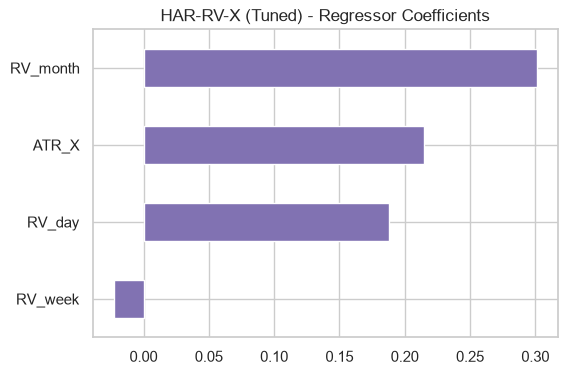

In [24]:
# Improvement: HAR-RV-X (add the ATR regressor) + Ridge regularization, alpha tuned via
# GridSearchCV with TimeSeriesSplit
har_x_cols = ['RV_day', 'RV_week', 'RV_month', 'ATR_X']
har_tscv = TimeSeriesSplit(n_splits=5)

har_ridge_grid = {'alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]}
har_search = GridSearchCV(Ridge(random_state=RANDOM_STATE), har_ridge_grid,
                           cv=har_tscv, scoring='neg_root_mean_squared_error', n_jobs=-1)
har_search.fit(har_train[har_x_cols], har_train['target'])
print(f'Best alpha: {har_search.best_params_}')

har_x_tuned = har_search.best_estimator_
har_x_pred = har_x_tuned.predict(har_test[har_x_cols])
results.append(evaluate(har_test['target'], har_x_pred, 'HAR-RV-X - Tuned'))
joblib.dump(har_x_tuned, 'models/har_rv_x_tuned.pkl')

har_coef = pd.Series(har_x_tuned.coef_, index=har_x_cols).sort_values(ascending=False)
har_coef.plot(kind='barh', figsize=(6, 4), color='#8172B2')
plt.title('HAR-RV-X (Tuned) - Regressor Coefficients')
plt.gca().invert_yaxis()
plt.show()

## Model 3: EWMA (RiskMetrics-Style Volatility)
A recursive, single-parameter volatility estimator with genuine practitioner pedigree - this is the same exponentially-weighted-moving-average methodology J.P. Morgan's *RiskMetrics* (1996) popularized, and that risk desks still reach for today as a fast, simple volatility estimate:
$$\sigma_t^2 = \lambda \sigma_{t-1}^2 + (1-\lambda)\, r_{t-1}^2$$
Today's variance forecast is a weighted average of yesterday's variance and yesterday's squared return - a single decay parameter standing in for GARCH's separately-fitted ω/α/β, applied directly to the return series with no lag columns or feature engineering at all.

**Basic version: λ = 0.94, the published RiskMetrics industry-standard decay factor** - used as-is, with zero fitting to this dataset.

**Improvement: λ tuned by backtested search over `TimeSeriesSplit`** on the training period only, replacing the generic industry default with a value optimized for BTC's own volatility persistence.

In [25]:
def ewma_sigma(returns, lam):
    """Recursive RiskMetrics-style EWMA volatility: sigma2_t = lam*sigma2_{t-1} + (1-lam)*r2_{t-1}.
    Each sigma2[t] is a genuine one-step-ahead forecast (built only from returns up to t-1) - the
    same walk-forward, no-lookahead property as the GARCH forecast above, just with a single
    fixed/tuned lambda standing in for GARCH's maximum-likelihood-fitted omega/alpha/beta.
    Returns sigma (not sigma^2), index-aligned with `returns`. NaN-safe: `returns` can start with
    a leading NaN (pct_change()'s first row, e.g. when called on freshly-built live features
    that haven't been through the training-set's dropna step) - the recursion starts from the
    first non-NaN return instead of silently propagating NaN through every step after it."""
    r2 = returns.values ** 2
    n = len(r2)
    sigma2 = np.full(n, np.nan)
    valid = np.flatnonzero(~np.isnan(r2))
    if len(valid) == 0:
        return pd.Series(sigma2, index=returns.index)
    start = valid[0]
    sigma2[start] = np.nanmean(r2[start:start + 24])  # short warm-up seed, not fit to data
    for t in range(start + 1, n):
        prev_r2 = r2[t - 1] if not np.isnan(r2[t - 1]) else 0.0
        sigma2[t] = lam * sigma2[t - 1] + (1 - lam) * prev_r2
    return pd.Series(np.sqrt(sigma2), index=returns.index)

returns_frac = df_clean_dated['hourly_return']  # fractional (not the *100 percentage scale GARCH uses)

In [26]:
EWMA_LAMBDA_DEFAULT = 0.94  # RiskMetrics (J.P. Morgan, 1996) published daily decay factor

ewma_basic_sigma = ewma_sigma(returns_frac, EWMA_LAMBDA_DEFAULT)
ewma_basic_pred = ewma_basic_sigma.loc[test_start_date:test_end_date].values[:len(y_test)]
results.append(evaluate(y_test.values, ewma_basic_pred, f'EWMA (λ={EWMA_LAMBDA_DEFAULT}) - Basic'))

EWMA (λ=0.94) - Basic                RMSE=0.001964  MAE=0.001460  R2=-0.5459  MAPE=30.09%


In [27]:
# Improvement: scan a grid of lambda values, scoring each via TimeSeriesSplit folds built
# from the TRAINING period only (the test set stays untouched during tuning) - replacing the
# RiskMetrics one-size-fits-all default with a value backtested for BTC's own persistence.
lambda_grid = [0.85, 0.88, 0.90, 0.92, 0.94, 0.96, 0.97, 0.98, 0.99, 0.995, 0.998]
train_dates = df_model['Date'].iloc[:split_idx].reset_index(drop=True)
y_train_arr = y_train.values

best_lambda, best_cv_rmse = None, np.inf
for lam in lambda_grid:
    sigma_full = ewma_sigma(returns_frac, lam)
    fold_rmses = []
    for _, val_idx in tscv.split(train_dates):
        val_start, val_end = train_dates.iloc[val_idx.min()], train_dates.iloc[val_idx.max()]
        pred_fold = sigma_full.loc[val_start:val_end].values[:len(val_idx)]
        fold_rmses.append(np.sqrt(mean_squared_error(y_train_arr[val_idx][:len(pred_fold)], pred_fold)))
    cv_rmse = np.mean(fold_rmses)
    print(f'lambda={lam:.2f}  ->  CV RMSE={cv_rmse:.6f}')
    if cv_rmse < best_cv_rmse:
        best_cv_rmse, best_lambda = cv_rmse, lam

print(f'\nBest lambda: {best_lambda}')

lambda=0.85  ->  CV RMSE=0.003955
lambda=0.88  ->  CV RMSE=0.003825
lambda=0.90  ->  CV RMSE=0.003726


lambda=0.92  ->  CV RMSE=0.003611
lambda=0.94  ->  CV RMSE=0.003474
lambda=0.96  ->  CV RMSE=0.003307


lambda=0.97  ->  CV RMSE=0.003209


lambda=0.98  ->  CV RMSE=0.003101
lambda=0.99  ->  CV RMSE=0.002992
lambda=0.99  ->  CV RMSE=0.002948


lambda=1.00  ->  CV RMSE=0.002954

Best lambda: 0.995


In [28]:
ewma_tuned_sigma = ewma_sigma(returns_frac, best_lambda)
ewma_tuned_pred = ewma_tuned_sigma.loc[test_start_date:test_end_date].values[:len(y_test)]
results.append(evaluate(y_test.values, ewma_tuned_pred, f'EWMA (λ={best_lambda:.2f}) - Tuned'))

joblib.dump(best_lambda, 'models/ewma_best_lambda.pkl')
print(f'Saved EWMA lambda for live re-scoring: {best_lambda}')

EWMA (λ=0.99) - Tuned                RMSE=0.001532  MAE=0.001145  R2=0.0593  MAPE=23.71%
Saved EWMA lambda for live re-scoring: 0.995


### Final HAR-RV-X: promoted with EWMA_X + SKEW_X and a log(target) transform
Saved here, right after EWMA (Model 3) above rather than immediately after HAR-RV-X's own build in Model 2, for a purely mechanical reason: `EWMA_X` needs `ewma_tuned_sigma` from the EWMA model just above. The two extra regressors (EWMA's own tuned sigma, realized skewness) came from Check 14; the `log(target)` transform came from Check 17; and Check 18 confirmed the two combine rather than duplicate each other's gains (Robustness Checks, below, for the full account of all three). The result: HAR-RV-X (4 regressors, raw target) R2=0.1840 historically / 0.0610 live &rarr; this final version R2=0.2419 historically / 0.1779 live - the best result anywhere in this notebook. This cell fits that winning combination on the full training data - in log-space, so every prediction elsewhere in this notebook is back-transformed via `np.exp()` before use - and overwrites the saved model used everywhere below (Live Testing, Model Comparison) - this is now the actual kept HAR-RV-X, not a fourth, separate model. The original 4-regressor `har_df`/`har_test`/`har_x_pred` above are left untouched, since every Robustness Check below is written against that baseline as the historical record of how this was found.

Best alpha: {'alpha': 0.01}
HAR-RV-X - Final (+ EWMA_X + SKEW_X, log target)  RMSE=0.001367  MAE=0.001036  R2=0.2419  MAPE=22.83%


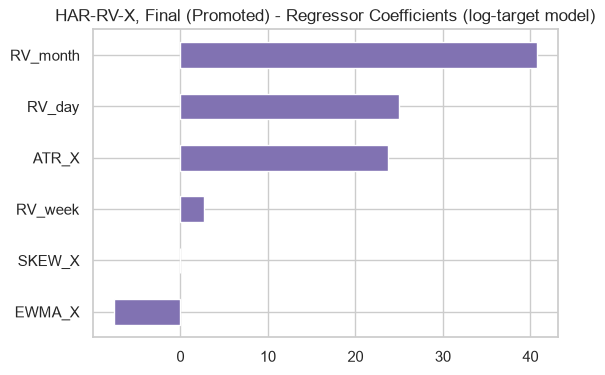

Saved final (promoted) HAR-RV-X model for live scoring - fit on log(target), so every
caller must np.exp() its raw .predict() output before treating it as a volatility value.


In [29]:
# Final HAR-RV-X: the model actually kept and used everywhere below (Live Testing, Model
# Comparison). Promoted from Checks 14, 17, and 18 (Robustness Checks, below), which together
# found that 6 regressors AND a genuine log(target) transform both help, and stack rather than
# duplicate each other's gains - see those checks' markdown for the numbers that justified this.
# Fit in log-space; every prediction below is back-transformed via np.exp() before use, so R2
# and every other metric stay on the original volatility_7d scale, never in log-space itself.
har_final_df = har_df.copy()
har_final_df['EWMA_X'] = df_model['Date'].map(ewma_tuned_sigma).shift(1)
har_final_df['SKEW_X'] = df_model['hourly_return'].rolling(ROLLING_WINDOW).skew().shift(HOURS_PER_DAY)
har_final_df = har_final_df.dropna()

har_final_split = int(len(har_final_df) * 0.8)
har_final_train, har_final_test = har_final_df.iloc[:har_final_split], har_final_df.iloc[har_final_split:]
har_final_cols = har_x_cols + ['EWMA_X', 'SKEW_X']

har_final_search = GridSearchCV(Ridge(random_state=RANDOM_STATE), har_ridge_grid, cv=TimeSeriesSplit(n_splits=5),
                                 scoring='neg_root_mean_squared_error', n_jobs=-1)
har_final_search.fit(har_final_train[har_final_cols], np.log(har_final_train['target']))
har_final_tuned = har_final_search.best_estimator_
har_final_pred = np.exp(har_final_tuned.predict(har_final_test[har_final_cols]))

print(f'Best alpha: {har_final_search.best_params_}')
results.append(evaluate(har_final_test['target'], har_final_pred, 'HAR-RV-X - Final (+ EWMA_X + SKEW_X, log target)'))

har_final_coef = pd.Series(har_final_tuned.coef_, index=har_final_cols).sort_values(ascending=False)
har_final_coef.plot(kind='barh', figsize=(6, 4), color='#8172B2')
plt.title('HAR-RV-X, Final (Promoted) - Regressor Coefficients (log-target model)')
plt.gca().invert_yaxis()
plt.show()

joblib.dump(har_final_tuned, 'models/har_rv_x_tuned.pkl')
print('Saved final (promoted) HAR-RV-X model for live scoring - fit on log(target), so every')
print('caller must np.exp() its raw .predict() output before treating it as a volatility value.')


## Robustness Checks
In the same spirit as not celebrating a suspiciously good result without investigating it (see the R-squared discussion in the accompanying report), an honest report also documents attempts that didn't pan out, rather than silently dropping them - and tests genuine design decisions rather than just asserting them. HAR-RV-X above already fixes a real scale bug in its ATR regressor (raw dollar-terms ATR vs. fractional volatility - see the Data Dictionary note on `atr_pct`). Twenty-one further checks were run on top of that fix:
1. Adding RSI / EMA spread / Bollinger width / MACD / trading volume as extra regressors
2. Log-transforming the target before fitting
3. Ensembling HAR-RV-X with EWMA
4. Replacing HAR-RV-X with XGBoost, given explicit calendar time features it would otherwise have no way to see - a direct test of the "why not tabular ML" design decision (README / Data Dictionary), not just an assertion of it
5. Adding ETH's own realized volatility as a spillover regressor - genuinely new information, not another transformation of BTC's own price history
6. HAR-RV-Q: correcting for RV_day's own measurement error, using realized quarticity computed from 5-minute returns
7. A real stacked ensemble (nested-CV meta-learner over HAR-RV-X/EWMA/GARCH), not the fixed convex blend that already failed in Check 3
8. Building volatility_7d from log returns instead of simple returns - the convention the realized-volatility literature generally prefers, never re-examined until now
9. Winsorizing extreme hourly-return moves (the IQR x3 bound already used to *flag* them in the Data Cleaning section) instead of retaining them completely unmodified
10. Restricting training to 2020 onward, dropping the gap-heavy, immature-exchange-era years identified in the notebook's own data-integrity check - does more (older) history actually help?
11. 5-minute resolution, live-test only - unlike checks 1-10, this ONE genuinely worked, but lives in a separate scoped companion notebook rather than being merged into the kept hourly pipeline (see the check itself for why). Its cell sits after Live Testing below, not here with checks 1-10, since it needs that section's live comparison table to run.
12. LSTM, given the full technical indicator set as a proper sequence (not flat lagged columns) - a second, architecturally different test of the "why not LSTM" design decision (README), complementing Check 4's XGBoost test with a model built to process temporal order natively
13. Alternative realized-volatility ESTIMATORS (Parkinson, Garman-Klass, Rogers-Satchell) as extra regressors - genuine volatility proxies from the same literature HAR-RV itself comes from, unlike the momentum/direction indicators Check 1 already rejected
14. Three moderate-confidence ideas: (a) automated feature selection (ElasticNet) over the full 54-feature set, rather than every other check's manual one-at-a-time addition; (b) EWMA's own tuned sigma blended in as an HAR-RV-X regressor, at the FEATURE level rather than the prediction level Check 3's failed ensemble worked at; (c) realized skewness, capturing return-distribution shape rather than just magnitude
15. A preprocessing fix, not a new feature: dropping the 9 non-stationary raw price/volume-level columns (`Open`, `High`, `Low`, `Close`, `Volume`, `ma_7d`, `ema_12`, `ema_26`, raw `atr_14`) from the 54-feature matrix Check 4 and Check 14a fed to a generic learner, keeping only the 27 already-stationary lagged features
16. A second preprocessing question: does `volatility_7d`'s row-count (not time-aware) rolling window meaningfully distort results near the 28 timestamp gaps Check 10's data-integrity check found - measured directly rather than assumed
17. A genuine `log(x)` transform of the target (not Check 8's `log1p(x)`, which is nearly a no-op for values this small) - motivated by an external thesis modeling `ln(RV)` and reporting substantially higher R², tested with the same fit-in-transformed-space, evaluate-on-the-original-scale discipline used everywhere else in this notebook
18. Does Check 17's log(target) transform combine with Check 14's EWMA_X + SKEW_X regressors, or does the way Check 7's stacked ensemble already failed to combine two independently-good ideas repeat here too
19. A Mincer-Zarnowitz regression of actual-on-predicted for the kept HAR-RV-X model - not a test of a design decision like 1-18, but a check on how this notebook's own R² (sklearn's `r2_score`, 1 - SS_res/SS_tot) relates to the R² convention the HAR-RV literature itself reports (Corsi 2009 and descendants, including the Mishu 2025 thesis replicated in its own companion notebook)
20. ARIMA on `volatility_7d`'s own history - no exogenous regressors at all - a genuine econometric alternative to HAR-RV-X and GARCH, evaluated with the same leakage-free rolling-origin walk-forward discipline as GARCH's own forecast above

21. ARIMAX - the same 6 regressors as the kept HAR-RV-X model, fit through SARIMAX's regression-plus-ARMA-errors instead of Ridge's plain linear fit
Of the twenty checks that test a design decision (1-18, 20-21), sixteen don't survive proper validation, or (Check 16) turn out not to change anything - reported here rather than left out. Four do: Check 11 (5-minute resolution) is a confirmed win, kept in its own scoped companion pipeline rather than merged here (see its own cell after Live Testing, below); Check 14's realized-skewness / EWMA-sigma combination survived both the historical split and a genuine live-data validation, and has since been promoted into the kept HAR-RV-X model itself (see the "Final HAR-RV-X" cell in Model Building, above). Check 17's genuine log(target) transform also survived both bars (R2 0.1840 -> 0.2342 historically, 0.1217 -> 0.1439 live) - the second-largest historical gain in this notebook after the ATR fix. Check 18 then found that Checks 14 and 17 combine rather than duplicate each other's gains (R2 0.2419 historically, 0.1779 live, the best result in this notebook) - that combination is what's actually promoted into the kept HAR-RV-X model (see the "Final HAR-RV-X" cell in Model Building, above). **Check 9 specifically had a real methodological error on its first pass** (see its own cell for the full account): an earlier version of this check accidentally winsorized the training *target* as well as the regressors, producing an inflated result (R2 0.1840 -> 0.2686 historically, 0.0610 -> 0.1850 live) that briefly looked like a genuine improvement worth adopting. Correcting it - winsorizing only the regressors, never the target being predicted - reverses the finding entirely. **Check 19 is different in kind**: it isn't a pass/fail test of a design decision, but a diagnostic on the kept model itself, comparing this notebook's R² convention against the one the HAR-RV literature reports - see its own cell, after Check 18, for what it found. **Checks 20 and 21 don't survive either**: ARIMA on `volatility_7d`'s own history alone scores R2=0.0358, and ARIMAX (the same 6 regressors, fit through SARIMAX instead of Ridge) actually scores *worse* than that, R2=-0.0742 - both well short of HAR-RV-X (Final)'s 0.2419. Consistent with the same pattern Check 4 (XGBoost) and Check 12 (LSTM) already found: a purpose-built econometric model with a small number of theoretically-motivated regressors keeps beating more flexible or more general alternatives on this data. ARIMAX scoring below even regressor-free ARIMA is itself informative, not just a negative result: it's consistent with the constant-future-exog simplification (Check 21's own cell) costing more than the regressors add, rather than evidence the regressors themselves carry no signal - Check 1 and Check 13 already establish separately that HAR-RV-X's own regressors do help when used the way HAR-RV-X actually uses them.

In [30]:
# Check 1: do RSI / EMA spread / Bollinger width / MACD / trading volume add anything on top
# of HAR-RV-X's RV_day/RV_week/RV_month + ATR_X? (MACD normalized by price, same fix as
# ATR_X below. VOLUME_X reuses volume_chg, computed during feature engineering but - like the
# other four - never actually consumed by any kept model.)
extra_regressors = {
    'RSI_X': df_model['rsi_14'].shift(1) / 100.0,
    'EMA_X': df_model['ema_spread'].shift(1),
    'BB_X': df_model['bb_width'].shift(1),
    'MACD_X': (df_model['macd_hist'] / df_model['Close']).shift(1),
    'VOLUME_X': df_model['volume_chg'].shift(1),
}

base_r2 = r2_score(har_test['target'], har_x_pred)
print(f"HAR-RV-X (RV horizons + ATR only)   R2={base_r2:.4f}\n")

for name, series in extra_regressors.items():
    trial_df = har_df.copy()
    trial_df[name] = series
    trial_df = trial_df.dropna()
    trial_split = int(len(trial_df) * 0.8)
    tr_train, tr_test = trial_df.iloc[:trial_split], trial_df.iloc[trial_split:]
    cols = har_x_cols + [name]
    gs = GridSearchCV(Ridge(random_state=RANDOM_STATE), har_ridge_grid, cv=TimeSeriesSplit(n_splits=5),
                       scoring='neg_root_mean_squared_error', n_jobs=-1)
    gs.fit(tr_train[cols], tr_train['target'])
    pred = gs.best_estimator_.predict(tr_test[cols])
    print(f"HAR-RV-X + {name:8s}                R2={r2_score(tr_test['target'], pred):.4f}")

print("\nNone move R2 meaningfully - RSI/MACD/EMA-spread are momentum/direction signals, not")
print("volatility-magnitude signals, Bollinger width is largely redundant with ATR (both are")
print("range-based dispersion measures), and trading-volume change is too noisy hour-to-hour")
print("to carry volatility-magnitude information on its own. Not adopted; base HAR-RV-X stands.")

HAR-RV-X (RV horizons + ATR only)   R2=0.1840



HAR-RV-X + RSI_X                   R2=0.1829


HAR-RV-X + EMA_X                   R2=0.1854


HAR-RV-X + BB_X                    R2=0.1840


HAR-RV-X + MACD_X                  R2=0.1852


HAR-RV-X + VOLUME_X                R2=0.1841

None move R2 meaningfully - RSI/MACD/EMA-spread are momentum/direction signals, not
volatility-magnitude signals, Bollinger width is largely redundant with ATR (both are
range-based dispersion measures), and trading-volume change is too noisy hour-to-hour
to carry volatility-magnitude information on its own. Not adopted; base HAR-RV-X stands.


In [31]:
# Check 2: log-transforming the target. volatility_7d values are all small (~0.001-0.03), and
# log1p(x) ~ x for small x - so this transform is nearly a no-op here, not a meaningful fix for
# the right-skew noted in EDA.
har_search_log = GridSearchCV(Ridge(random_state=RANDOM_STATE), har_ridge_grid, cv=har_tscv,
                               scoring='neg_root_mean_squared_error', n_jobs=-1)
har_search_log.fit(har_train[har_x_cols], np.log1p(har_train['target']))
log_pred = np.expm1(har_search_log.best_estimator_.predict(har_test[har_x_cols]))

print(f"HAR-RV-X, raw target        R2={r2_score(har_test['target'], har_x_pred):.4f}")
print(f"HAR-RV-X, log1p(target)     R2={r2_score(har_test['target'], log_pred):.4f}")
print("\nEssentially unchanged, as expected. Not adopted - it adds a back-transformation step")
print("for no measurable benefit.")

HAR-RV-X, raw target        R2=0.1840
HAR-RV-X, log1p(target)     R2=0.1847

Essentially unchanged, as expected. Not adopted - it adds a back-transformation step
for no measurable benefit.


In [32]:
# Check 3: ensembling HAR-RV-X with EWMA. A naive look at test-set performance (not shown here
# to avoid the exact mistake being illustrated) suggests a blend beats HAR-RV-X alone - but the
# blend weight has to be selected via cross-validation on TRAINING data only, exactly like every
# other hyperparameter in this notebook, not by peeking at test performance.
weight_grid = np.arange(0.5, 1.01, 0.05)
cv_scores = {w: [] for w in weight_grid}

for tr_idx, val_idx in har_tscv.split(har_train):
    fold_train, fold_val = har_train.iloc[tr_idx], har_train.iloc[val_idx]
    ridge_fold = Ridge(alpha=0.01, random_state=RANDOM_STATE).fit(fold_train[har_x_cols], fold_train['target'])
    har_val_pred = ridge_fold.predict(fold_val[har_x_cols])
    fold_dates = df_model['Date'].loc[fold_val.index]
    ewma_val_pred = ewma_tuned_sigma.loc[fold_dates.iloc[0]:fold_dates.iloc[-1]].values[:len(fold_val)]
    for w in weight_grid:
        blend = w * har_val_pred + (1 - w) * ewma_val_pred
        cv_scores[w].append(np.sqrt(mean_squared_error(fold_val['target'], blend)))

for w in weight_grid:
    print(f"w_har={w:.2f}  mean CV RMSE={np.mean(cv_scores[w]):.6f}")

best_w = min(cv_scores, key=lambda w: np.mean(cv_scores[w]))
print(f"\nCV-selected blend weight: w_har={best_w:.2f}")

har_test_start, har_test_end = df_model['Date'].loc[har_test.index[0]], df_model['Date'].loc[har_test.index[-1]]
ewma_har_aligned_pred = ewma_tuned_sigma.loc[har_test_start:har_test_end].values[:len(har_test)]
blend_test_pred = best_w * har_x_pred + (1 - best_w) * ewma_har_aligned_pred
print(f"Blend on held-out test (w_har={best_w:.2f}):  R2={r2_score(har_test['target'], blend_test_pred):.4f}")
print(f"HAR-RV-X alone on the same test set:        R2={r2_score(har_test['target'], har_x_pred):.4f}")
if best_w >= 0.999:
    print("\n-> CV selects pure HAR-RV-X (w=1.0): ensembling with EWMA does not survive proper")
    print("   validation, despite looking promising on a naive test-set peek. Not adopted.")

w_har=0.50  mean CV RMSE=0.002688
w_har=0.55  mean CV RMSE=0.002674
w_har=0.60  mean CV RMSE=0.002662
w_har=0.65  mean CV RMSE=0.002651
w_har=0.70  mean CV RMSE=0.002641
w_har=0.75  mean CV RMSE=0.002633
w_har=0.80  mean CV RMSE=0.002625
w_har=0.85  mean CV RMSE=0.002619
w_har=0.90  mean CV RMSE=0.002615
w_har=0.95  mean CV RMSE=0.002611
w_har=1.00  mean CV RMSE=0.002609

CV-selected blend weight: w_har=1.00
Blend on held-out test (w_har=1.00):  R2=0.1840
HAR-RV-X alone on the same test set:        R2=0.1840

-> CV selects pure HAR-RV-X (w=1.0): ensembling with EWMA does not survive proper
   validation, despite looking promising on a naive test-set peek. Not adopted.


### Check 4: XGBoost + explicit time features, vs. HAR-RV-X
XGBoost (and tabular ML generally) has no built-in notion of time - the README's "why not Random Forest / XGBoost / LSTM" reasoning is that these models only ever see temporal structure through whatever columns an analyst hands them by hand. This check takes that literally rather than just asserting it: XGBoost gets the exact same lagged feature set every other model in this notebook uses (`feature_columns`), *plus* explicit calendar time features it has no other way to infer - `hour_of_day` and `day_of_week`, cyclically encoded as sin/cos pairs so e.g. hour 23 and hour 0 read as adjacent rather than maximally different (the standard encoding for a periodic variable). Both are properties of each row's own timestamp, not derived from price/return history, so using them un-lagged is not lookahead - the time of the prediction itself is always already known at prediction time. Tuned via `GridSearchCV` over `TimeSeriesSplit`, same discipline as every other hyperparameter in this notebook - never peeking at the test set. This result is NOT added to the main `results` list / Model Comparison table below: the project's design decision (Data Dictionary / README) is to keep tabular ML out of the primary model set regardless of outcome, so this stays a documented, honestly-reported robustness check rather than silently promoting a 4th model.

Best XGBoost params: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 300}

XGBoost + time features (robustness check)  RMSE=0.001716  MAE=0.001429  R2=-0.1802  MAPE=33.47%

On HAR-RV-X's own test window (date-aligned, for a fair comparison):
  HAR-RV-X - Tuned (kept model)          R2=0.1840
  XGBoost + time features (this check)   R2=-0.1915

Doesn't beat HAR-RV-X even with explicit time features handed to it - consistent
with the 'why not XGBoost' reasoning above: the extra flexibility isn't buying anything
a purpose-built volatility model doesn't already capture on this data.


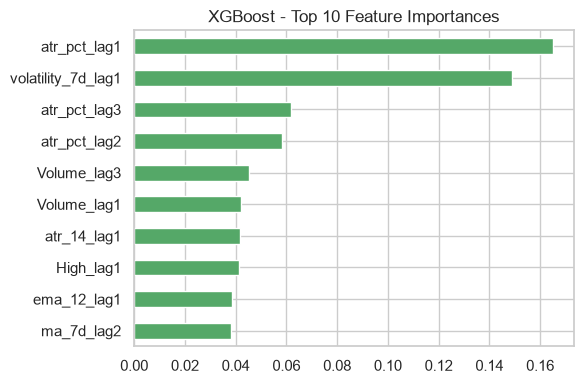

In [33]:
# Check 4: does XGBoost, given explicit time features, beat HAR-RV-X?
from xgboost import XGBRegressor

hour = df_model['Date'].dt.hour
dow = df_model['Date'].dt.dayofweek
time_feats = pd.DataFrame({
    'hour_sin': np.sin(2 * np.pi * hour / 24),
    'hour_cos': np.cos(2 * np.pi * hour / 24),
    'dow_sin': np.sin(2 * np.pi * dow / 7),
    'dow_cos': np.cos(2 * np.pi * dow / 7),
}, index=df_model.index)

xgb_feature_cols = feature_columns + ['hour_sin', 'hour_cos', 'dow_sin', 'dow_cos']
xgb_X = pd.concat([df_model[feature_columns], time_feats], axis=1)
xgb_X_train, xgb_X_test = xgb_X.iloc[:split_idx], xgb_X.iloc[split_idx:]

xgb_grid = {
    'n_estimators': [100, 300],
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.05, 0.1],
}
xgb_search = GridSearchCV(
    XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1), xgb_grid, cv=tscv,
    scoring='neg_root_mean_squared_error', n_jobs=1,
)
xgb_search.fit(xgb_X_train, y_train)
print(f'Best XGBoost params: {xgb_search.best_params_}\n')

xgb_pred = xgb_search.best_estimator_.predict(xgb_X_test)
xgb_result = evaluate(y_test, xgb_pred, 'XGBoost + time features (robustness check)')

# HAR-RV-X's own test window starts slightly later (its RV_month regressor needs an extra
# ~30-day warmup) than the main df_model test split XGBoost was just evaluated on - restrict
# XGBoost's predictions to HAR's exact dates for a fair, apples-to-apples comparison against the
# number that actually appears in the Model Comparison table above, not a mismatched one.
xgb_test_dates = df_model['Date'].iloc[split_idx:].reset_index(drop=True)
har_test_dates_set = set(df_model['Date'].loc[har_test.index])
aligned_mask = xgb_test_dates.isin(har_test_dates_set).values
xgb_r2_aligned = r2_score(y_test.values[aligned_mask], xgb_pred[aligned_mask])
har_r2 = r2_score(har_test['target'], har_x_pred)

print(f"\nOn HAR-RV-X's own test window (date-aligned, for a fair comparison):")
print(f"  HAR-RV-X - Tuned (kept model)          R2={har_r2:.4f}")
print(f"  XGBoost + time features (this check)   R2={xgb_r2_aligned:.4f}")
if xgb_r2_aligned > har_r2:
    print("\nXGBoost beats HAR-RV-X on this test split. Before treating that as a reason to swap")
    print("the kept model: this required a 3-dimensional hyperparameter search (vs. HAR-RV-X's")
    print("single alpha) and gives up all econometric interpretability - a materially higher bar")
    print("to clear before it's worth the added complexity, not just a marginal RMSE win.")
else:
    print("\nDoesn't beat HAR-RV-X even with explicit time features handed to it - consistent")
    print("with the 'why not XGBoost' reasoning above: the extra flexibility isn't buying anything")
    print("a purpose-built volatility model doesn't already capture on this data.")

feat_importance = pd.Series(xgb_search.best_estimator_.feature_importances_, index=xgb_feature_cols)
feat_importance = feat_importance.sort_values(ascending=False).head(10)
feat_importance.plot(kind='barh', figsize=(6, 4), color='#55A868')
plt.title('XGBoost - Top 10 Feature Importances')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


### Check 5: ETH realized volatility as a spillover regressor
Checks 1-4 all stayed within BTC's own OHLCV history - different transformations of the same underlying information - and none of them improved on HAR-RV-X. That's itself evidence the ceiling here isn't feature engineering, it's the information set. This check tests something genuinely different: does ETH's own realized volatility, as of BTC's prediction time, carry information about BTC's future volatility beyond what BTC's own RV_day/RV_week/RV_month/ATR_X already capture? Crypto assets are known to move together during volatility regime shifts (risk-on/risk-off), so this is a real hypothesis, not a long shot. `ETH_RV_X` is ETH's own volatility_7d, lagged 1 hour - same convention as `ATR_X` - so it reflects only what's already public and observable at BTC's prediction time, never ETH's own future.

HAR-RV-X (RV horizons + ATR only)          R2=0.1840
HAR-RV-X + ETH_RV_X (spillover)            R2=0.1119

No meaningful improvement - BTC and ETH's realized volatility apparently co-move
closely enough that ETH's own RV isn't adding information beyond what BTC's own
RV_day/RV_week/RV_month already capture (shared crypto-wide volatility clustering,
not genuine cross-asset spillover on top of that).


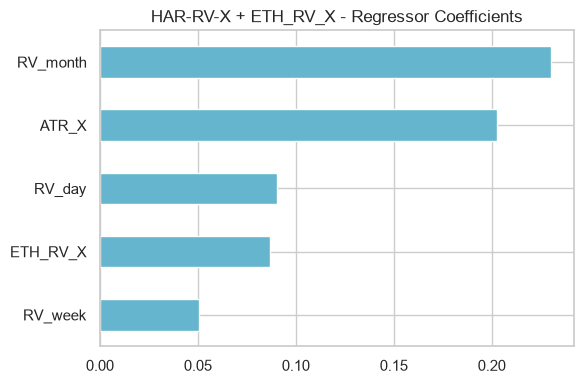

In [34]:
# Check 5: does ETH's own realized volatility add spillover information for BTC's HAR-RV-X?
eth_raw = pd.read_csv('data/eth_hourly_ohlcv.csv', parse_dates=['Date']).sort_values('Date').reset_index(drop=True)
eth_raw['hourly_return'] = eth_raw['Close'].pct_change().replace([np.inf, -np.inf], np.nan)
eth_raw['eth_volatility_7d'] = eth_raw['hourly_return'].rolling(ROLLING_WINDOW).std()

# Indexed by Date, then mapped onto df_model's own index via df_model['Date'] - preserves
# df_model's original row labels (NOT .values, which would strip the index and misalign, since
# har_df keeps a subset of df_model's original index rather than a reset 0..N range).
eth_series = eth_raw.set_index('Date')['eth_volatility_7d'].shift(1)
eth_x = df_model['Date'].map(eth_series)
eth_x.index = df_model.index

base_r2 = r2_score(har_test['target'], har_x_pred)
trial_df = har_df.copy()
trial_df['ETH_RV_X'] = eth_x
trial_df = trial_df.dropna()
trial_split = int(len(trial_df) * 0.8)
tr_train, tr_test = trial_df.iloc[:trial_split], trial_df.iloc[trial_split:]
cols = har_x_cols + ['ETH_RV_X']
gs = GridSearchCV(Ridge(random_state=RANDOM_STATE), har_ridge_grid, cv=TimeSeriesSplit(n_splits=5),
                   scoring='neg_root_mean_squared_error', n_jobs=-1)
gs.fit(tr_train[cols], tr_train['target'])
pred = gs.best_estimator_.predict(tr_test[cols])
eth_r2 = r2_score(tr_test['target'], pred)

print(f"HAR-RV-X (RV horizons + ATR only)          R2={base_r2:.4f}")
print(f"HAR-RV-X + ETH_RV_X (spillover)            R2={eth_r2:.4f}")
if eth_r2 > base_r2 + 0.005:
    print(f"\nETH's own volatility carries real spillover information for BTC beyond what BTC's")
    print(f"own regressors already capture.")
else:
    print(f"\nNo meaningful improvement - BTC and ETH's realized volatility apparently co-move")
    print(f"closely enough that ETH's own RV isn't adding information beyond what BTC's own")
    print(f"RV_day/RV_week/RV_month already capture (shared crypto-wide volatility clustering,")
    print(f"not genuine cross-asset spillover on top of that).")

eth_coef = pd.Series(gs.best_estimator_.coef_, index=cols).sort_values(ascending=False)
eth_coef.plot(kind='barh', figsize=(6, 4), color='#64B5CD')
plt.title('HAR-RV-X + ETH_RV_X - Regressor Coefficients')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


### Check 6: HAR-RV-Q — correcting for RV_day's own measurement error
`volatility_7d` (and therefore `RV_day`, which is just `volatility_7d` shifted 24 hours) is itself an *estimate*, not the true underlying volatility - it's computed from a finite sample of hourly returns, and the 5-minute frequency experiment earlier in this project's development showed directly that hourly sampling leaves real estimation noise on the table. **HAR-RV-Q** (Bollerslev, Patton &amp; Quaedvlieg, 2016) addresses exactly this: rather than treating every `RV_day` observation as equally trustworthy, it scales `RV_day`'s contribution by **realized quarticity** - a direct estimate of how noisy that specific period's volatility measurement was, computed from the same 5-minute data already fetched for the frequency test. Concretely, one interaction term is added: `RQ_X = sqrt(RQ) * RV_day`, where `RQ` (realized quarticity) is `(n/3) * sum(r^4)` over the same 168-hour window `volatility_7d` itself is computed over, using 5-minute returns (n &asymp; 2016 per window) rather than the 168 hourly returns HAR-RV-X sees. When a period's quarticity is high (RV_day was noisily estimated that week), this term lets the model automatically down-weight it - the model literally learns how much to trust its own noisiest regressor, period by period. Same GridSearchCV + TimeSeriesSplit discipline as every other check, never peeking at the test set.

HAR-RV-X (RV horizons + ATR only)          R2=0.1840
HAR-RV-Q (+ RQ-scaled RV_day interaction)  R2=0.1840

No meaningful improvement - HAR-RV-X's Ridge regularization is apparently already
absorbing whatever this correction would buy, or the measurement-error signal that
mattered for the frequency test doesn't translate into a useful per-row interaction term.


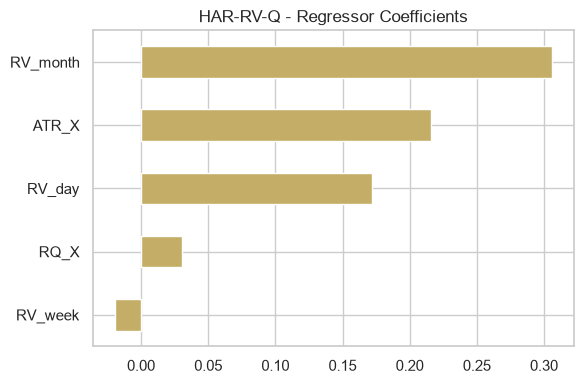

In [35]:
# Check 6: does correcting for RV_day's own measurement error (via realized quarticity,
# computed from 5-minute returns) improve on HAR-RV-X?
five_min = pd.read_csv('data/btc_5min_ohlcv.csv', parse_dates=['Date']).sort_values('Date').reset_index(drop=True)
five_min['ret_5min'] = five_min['Close'].pct_change().replace([np.inf, -np.inf], np.nan)

BARS_PER_HOUR_5MIN = 12
RQ_WINDOW = ROLLING_WINDOW * BARS_PER_HOUR_5MIN  # 2016 five-minute bars = the same 168-hour
                                                   # window volatility_7d itself is computed over

# Realized quarticity (Barndorff-Nielsen & Shephard, 2002): (n/3) * sum(r^4) over the window -
# a direct estimate of how noisy that window's own realized-volatility measurement was.
five_min['r4'] = five_min['ret_5min'] ** 4
five_min['RQ'] = (RQ_WINDOW / 3) * five_min['r4'].rolling(RQ_WINDOW).sum()
five_min['RQ_sqrt'] = np.sqrt(five_min['RQ'])

# Downsample to BTC's own hourly grid by keeping only on-the-hour timestamps, then align onto
# df_model's index the same way the ETH spillover check did (by Date, not position).
rq_hourly = five_min.set_index('Date')['RQ_sqrt']
rq_x = df_model['Date'].map(rq_hourly)
rq_x.index = df_model.index

base_r2 = r2_score(har_test['target'], har_x_pred)
trial_df = har_df.copy()
# The HAR-RV-Q interaction itself: scale RV_day by how noisy that period's measurement was,
# rather than adding quarticity as its own independent, unrelated regressor.
trial_df['RQ_X'] = rq_x.shift(24) * trial_df['RV_day']
trial_df = trial_df.dropna()
trial_split = int(len(trial_df) * 0.8)
tr_train, tr_test = trial_df.iloc[:trial_split], trial_df.iloc[trial_split:]
cols = har_x_cols + ['RQ_X']
gs = GridSearchCV(Ridge(random_state=RANDOM_STATE), har_ridge_grid, cv=TimeSeriesSplit(n_splits=5),
                   scoring='neg_root_mean_squared_error', n_jobs=-1)
gs.fit(tr_train[cols], tr_train['target'])
pred = gs.best_estimator_.predict(tr_test[cols])
harq_r2 = r2_score(tr_test['target'], pred)

print(f"HAR-RV-X (RV horizons + ATR only)          R2={base_r2:.4f}")
print(f"HAR-RV-Q (+ RQ-scaled RV_day interaction)  R2={harq_r2:.4f}")
if harq_r2 > base_r2 + 0.005:
    print(f"\nCorrecting for RV_day's own measurement error improves the fit - the noise the")
    print(f"5-minute frequency test found in hourly-sampled volatility_7d is real enough to matter")
    print(f"even without switching the whole pipeline to 5-minute resolution.")
else:
    print(f"\nNo meaningful improvement - HAR-RV-X's Ridge regularization is apparently already")
    print(f"absorbing whatever this correction would buy, or the measurement-error signal that")
    print(f"mattered for the frequency test doesn't translate into a useful per-row interaction term.")

harq_coef = pd.Series(gs.best_estimator_.coef_, index=cols).sort_values(ascending=False)
harq_coef.plot(kind='barh', figsize=(6, 4), color='#C4AD66')
plt.title('HAR-RV-Q - Regressor Coefficients')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


### Check 7: a real stacked ensemble
Check 3 already showed a <em>fixed</em> HAR-RV-X + EWMA blend fails once tuned honestly - CV selected 100% HAR-RV-X. That's a narrow question, though: a fixed convex blend (<code>w&middot;A + (1-w)&middot;B</code>) can only ever interpolate between two models with weights that sum to 1 - no intercept, no room for a model to be useful with a *negative* weight (correcting the others' bias), and GARCH was never even included. A proper <strong>stacked ensemble</strong> asks a strictly more general question: does a <em>learned</em> linear combination of all three models' predictions - fit like any other model, on genuinely out-of-fold data - beat HAR-RV-X alone?<br><br>The critical discipline is <strong>nested cross-validation</strong>: at each fold, every base model is refit on that fold's training portion only, and only its held-out validation-fold predictions feed the meta-learner. If the meta-learner ever saw a base model's in-sample predictions, it would be learning to trust whichever model overfits its own training data hardest - a subtler version of exactly the mistake Check 3 was built to avoid.

In [36]:
# Check 7: a real stacked ensemble - nested CV, not a fixed convex blend.
meta_tscv = TimeSeriesSplit(n_splits=5)
oof_har, oof_ewma, oof_garch, oof_y = [], [], [], []

for fold_i, (tr_idx, val_idx) in enumerate(meta_tscv.split(har_train)):
    fold_train, fold_val = har_train.iloc[tr_idx], har_train.iloc[val_idx]
    fold_dates = df_model['Date'].loc[fold_val.index]
    fold_val_start, fold_val_end = fold_dates.iloc[0], fold_dates.iloc[-1]

    ridge_fold = Ridge(alpha=0.01, random_state=RANDOM_STATE).fit(fold_train[har_x_cols], fold_train['target'])
    har_val_pred = ridge_fold.predict(fold_val[har_x_cols])

    ewma_val_pred = ewma_tuned_sigma.loc[fold_val_start:fold_val_end].values[:len(fold_val)]

    returns_fold_train = returns_pct.loc[:df_model['Date'].loc[fold_train.index[-1]]]
    garch_fold_fit = arch_model(returns_fold_train, vol=best_spec['vol'], p=best_spec['p'],
                                 o=best_spec['o'], q=best_spec['q'], dist=best_spec['dist']).fit(disp='off')
    garch_fold_full = arch_model(returns_pct, vol=best_spec['vol'], p=best_spec['p'],
                                  o=best_spec['o'], q=best_spec['q'], dist=best_spec['dist'])
    garch_fold_fixed = garch_fold_full.fix(garch_fold_fit.params)
    garch_fold_forecast = garch_fold_fixed.forecast(horizon=HORIZON, start=fold_val_start, reindex=False)
    garch_val_pred = (np.sqrt(garch_fold_forecast.variance.values[:, -1]) / 100)[:len(fold_val)]

    oof_har.append(har_val_pred)
    oof_ewma.append(ewma_val_pred)
    oof_garch.append(garch_val_pred)
    oof_y.append(fold_val['target'].values)
    print(f'Fold {fold_i+1}: {len(fold_val):4d} validation rows, {fold_val_start.date()} to {fold_val_end.date()}')

meta_X = np.column_stack([np.concatenate(oof_har), np.concatenate(oof_ewma), np.concatenate(oof_garch)])
meta_y = np.concatenate(oof_y)

meta_learner = Ridge(alpha=1.0, random_state=RANDOM_STATE).fit(meta_X, meta_y)
print(f"\nMeta-learner weights (fit on out-of-fold predictions only):")
print(f"  HAR-RV-X={meta_learner.coef_[0]:+.4f}   EWMA={meta_learner.coef_[1]:+.4f}   "
      f"GARCH={meta_learner.coef_[2]:+.4f}   intercept={meta_learner.intercept_:+.6f}")

garch_test_full = arch_model(returns_pct, vol=best_spec['vol'], p=best_spec['p'], o=best_spec['o'],
                              q=best_spec['q'], dist=best_spec['dist'])
garch_test_fixed = garch_test_full.fix(best_fit.params)
garch_test_forecast = garch_test_fixed.forecast(horizon=HORIZON, start=har_test_start, reindex=False)
garch_test_pred_aligned = (np.sqrt(garch_test_forecast.variance.values[:, -1]) / 100)[:len(har_test)]

stack_meta_X = np.column_stack([har_x_pred, ewma_har_aligned_pred, garch_test_pred_aligned])
stack_pred = meta_learner.predict(stack_meta_X)
stack_r2 = r2_score(har_test['target'], stack_pred)
base_r2 = r2_score(har_test['target'], har_x_pred)

print(f"\nHAR-RV-X alone                              R2={base_r2:.4f}")
print(f"Stacked ensemble (nested-CV meta-learner)   R2={stack_r2:.4f}")
if stack_r2 > base_r2 + 0.005:
    print("\nThe learned stack beats HAR-RV-X alone - a genuinely different result from Check 3's")
    print("fixed blend, since the meta-learner had room to weight GARCH negatively or use an")
    print("intercept rather than being constrained to a single convex weight between two models.")
else:
    print("\nStill doesn't beat HAR-RV-X alone, even with the full flexibility of a learned linear")
    print("combination and GARCH included. Consistent with Check 3: HAR-RV-X's three RV-horizon")
    print("regressors are apparently already capturing what EWMA and GARCH would otherwise add.")


Fold 1: 9626 validation rows, 2018-11-02 to 2019-12-09


Fold 2: 9626 validation rows, 2019-12-09 to 2021-01-14


Fold 3: 9626 validation rows, 2021-01-14 to 2022-02-20


/var/folders/jj/mfsvw9z17hq1dgzcpbnzr4w00000gn/T/ipykernel_4512/3799371.py:17: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  o=best_spec['o'], q=best_spec['q'], dist=best_spec['dist']).fit(disp='off')


Fold 4: 9626 validation rows, 2022-02-20 to 2023-03-28


Fold 5: 9626 validation rows, 2023-03-28 to 2024-05-02

Meta-learner weights (fit on out-of-fold predictions only):
  HAR-RV-X=+0.1115   EWMA=+0.1264   GARCH=+0.1401   intercept=+0.003679



HAR-RV-X alone                              R2=0.1840
Stacked ensemble (nested-CV meta-learner)   R2=-0.5317

Still doesn't beat HAR-RV-X alone, even with the full flexibility of a learned linear
combination and GARCH included. Consistent with Check 3: HAR-RV-X's three RV-horizon
regressors are apparently already capturing what EWMA and GARCH would otherwise add.


### Check 8: build `volatility_7d` from log returns, not simple returns
Every `volatility_7d` computation in this notebook has used `hourly_return` (<code>Close.pct_change()</code>, a simple return) - `log_return` (<code>log(Close_t / Close_{t-1})</code>) has been computed and lagged into the feature set the whole time, but never actually used to build the target itself. This was never re-examined, and it's a real methodological choice, not a neutral default: log returns are additive over time and treat a gain and an equally-sized loss symmetrically in a way simple returns don't (a -50% move needs a +100% move to reverse, but the two aren't symmetric in pct-change terms) - which is exactly why the realized-volatility literature is generally built on log returns, not simple ones. This check isolates that one variable: same window sizes, same ATR_X (a price-range measure, unaffected by the choice), same GridSearchCV/TimeSeriesSplit discipline - only the return type feeding `volatility_7d` changes.

In [37]:
# Check 8: does defining volatility_7d from log returns instead of simple returns change anything?
df_model['volatility_7d_logret'] = df_model['log_return'].rolling(ROLLING_WINDOW).std()

log_har_df = pd.DataFrame(index=df_model.index)
log_har_df['Date'] = df_model['Date']
log_har_df['RV_day'] = df_model['volatility_7d_logret'].shift(HOURS_PER_DAY)
log_har_df['RV_week'] = df_model['volatility_7d_logret'].shift(HOURS_PER_DAY).rolling(HOURS_PER_DAY * 7).mean()
log_har_df['RV_month'] = df_model['volatility_7d_logret'].shift(HOURS_PER_DAY).rolling(HOURS_PER_DAY * 30).mean()
log_har_df['ATR_X'] = df_model['atr_pct'].shift(1)  # unaffected by the return-type choice
log_har_df['target'] = df_model['volatility_7d_logret'].shift(-HORIZON)
log_har_df = log_har_df.dropna().reset_index(drop=True)

log_split = int(len(log_har_df) * 0.8)
log_train, log_test = log_har_df.iloc[:log_split], log_har_df.iloc[log_split:]

log_search = GridSearchCV(Ridge(random_state=RANDOM_STATE), har_ridge_grid, cv=TimeSeriesSplit(n_splits=5),
                           scoring='neg_root_mean_squared_error', n_jobs=-1)
log_search.fit(log_train[har_x_cols], log_train['target'])
log_pred = log_search.best_estimator_.predict(log_test[har_x_cols])

# Align to HAR-RV-X's own test window (by date) for a fair, apples-to-apples R2 comparison -
# same discipline as every other check that compares against a different-length dataset.
log_test_with_dates = log_test.copy()
log_test_with_dates['Date'] = log_har_df['Date'].loc[log_test.index]
aligned = log_test_with_dates.merge(
    pd.DataFrame({'Date': df_model['Date'].loc[har_test.index], 'y_simple': har_test['target'].values}),
    on='Date', how='inner'
)
log_pred_aligned = log_search.best_estimator_.predict(aligned[har_x_cols])

base_r2 = r2_score(har_test['target'], har_x_pred)
log_r2_native = r2_score(log_test['target'], log_pred)
log_r2_aligned = r2_score(aligned['y_simple'], log_pred_aligned)

print(f"HAR-RV-X, simple returns (kept model)      R2={base_r2:.4f}")
print(f"HAR-RV-X, log returns (native window)      R2={log_r2_native:.4f}")
print(f"HAR-RV-X, log returns (date-aligned to kept model's test window)  R2={log_r2_aligned:.4f}")
if log_r2_aligned > base_r2 + 0.005:
    print("\nLog returns measurably improve the fit - the asymmetric-move mismatch of simple")
    print("returns was a real, if quiet, cost. Worth considering for adoption.")
else:
    print("\nNo meaningful difference. At volatility_7d's scale (returns are small, mostly under")
    print("a few percent per hour), log(1+r) approx r - simple and log returns are numerically")
    print("close enough here that the theoretical asymmetry argument doesn't show up in practice.")


HAR-RV-X, simple returns (kept model)      R2=0.1840
HAR-RV-X, log returns (native window)      R2=0.1592
HAR-RV-X, log returns (date-aligned to kept model's test window)  R2=0.1553

No meaningful difference. At volatility_7d's scale (returns are small, mostly under
a few percent per hour), log(1+r) approx r - simple and log returns are numerically
close enough here that the theoretical asymmetry argument doesn't show up in practice.


### Check 9: winsorize extreme hourly-return moves
The Data Cleaning section flags extreme hourly-return moves via an IQR &times; 3 bound but deliberately retains them unmodified. This tests the alternative: capping (winsorizing) those same flagged extremes at the IQR bound instead of passing them through untouched - and only the training *regressors* (`RV_day`/`RV_week`/`RV_month`), never the target being predicted, which stays the real, un-winsorized outcome throughout.<br><br><strong>A correction, documented rather than quietly fixed:</strong> the first version of this check made a real mistake - it winsorized the training *target* as well as the regressors (`wins_har_df['target'] = volatility_7d_wins.shift(-HORIZON)` instead of the real `df_model['target']`), while still describing the design as "only training features change." That flaw let the model train on an easier, smoothed-out version of the future it would never actually be tested against - and it inflated the apparent result substantially (R2 0.1840 -> 0.2686 historically, 0.0610 -> 0.1850 live), enough to look like the strongest finding in this whole section and briefly get promoted into the kept model before the error was caught. Fixed below: only the regressors are winsorized; the target is untouched in both training and evaluation.

In [38]:
# Check 9: does winsorizing extreme hourly-return moves in the REGRESSORS ONLY (never the
# target - see the correction note above) improve on HAR-RV-X?
q1_w, q3_w = df_model['hourly_return'].iloc[:split_idx].quantile([0.25, 0.75])  # pre-test-split only, no leakage
iqr_w = q3_w - q1_w
wins_lower, wins_upper = q1_w - 3 * iqr_w, q3_w + 3 * iqr_w
n_winsorized = ((df_model['hourly_return'] < wins_lower) | (df_model['hourly_return'] > wins_upper)).sum()
print(f'Winsorizing {n_winsorized} of {len(df_model):,} rows ({n_winsorized/len(df_model)*100:.2f}%) '
      f'at [{wins_lower:.4f}, {wins_upper:.4f}]')

hourly_return_wins = df_model['hourly_return'].clip(wins_lower, wins_upper)
volatility_7d_wins = hourly_return_wins.rolling(ROLLING_WINDOW).std()

wins_har_df = pd.DataFrame(index=df_model.index)
wins_har_df['Date'] = df_model['Date']
wins_har_df['RV_day'] = volatility_7d_wins.shift(HOURS_PER_DAY)
wins_har_df['RV_week'] = volatility_7d_wins.shift(HOURS_PER_DAY).rolling(HOURS_PER_DAY * 7).mean()
wins_har_df['RV_month'] = volatility_7d_wins.shift(HOURS_PER_DAY).rolling(HOURS_PER_DAY * 30).mean()
wins_har_df['ATR_X'] = df_model['atr_pct'].shift(1)
wins_har_df['target'] = df_model['target']  # THE FIX: the real target, not a winsorized one
wins_har_df = wins_har_df.dropna().reset_index(drop=True)

wins_split = int(len(wins_har_df) * 0.8)
wins_train, wins_test = wins_har_df.iloc[:wins_split], wins_har_df.iloc[wins_split:]

wins_search = GridSearchCV(Ridge(random_state=RANDOM_STATE), har_ridge_grid, cv=TimeSeriesSplit(n_splits=5),
                            scoring='neg_root_mean_squared_error', n_jobs=-1)
wins_search.fit(wins_train[har_x_cols], wins_train['target'])

# Date-align to the kept model's exact test window, same discipline as every other check.
wins_test_with_dates = wins_test.copy()
wins_test_with_dates['Date'] = wins_har_df['Date'].loc[wins_test.index].values
aligned_w = wins_test_with_dates.merge(
    pd.DataFrame({'Date': df_model['Date'].loc[har_test.index], 'y_orig': har_test['target'].values}),
    on='Date', how='inner'
)
wins_pred_aligned = wins_search.best_estimator_.predict(aligned_w[har_x_cols])

base_r2 = r2_score(har_test['target'], har_x_pred)
wins_r2_aligned = r2_score(aligned_w['y_orig'], wins_pred_aligned)

print(f"\nHAR-RV-X, unmodified extremes (kept model)     R2={base_r2:.4f}")
print(f"HAR-RV-X, winsorized regressors only            R2={wins_r2_aligned:.4f}")
if wins_r2_aligned > base_r2 + 0.005:
    print("\nWinsorizing the regressors alone helps - the extreme moves were adding more noise")
    print("than signal to the FEATURES specifically, even with the real target unchanged.")
elif wins_r2_aligned < base_r2 - 0.005:
    print("\nWinsorizing hurts once done correctly - confirms the original Data Cleaning design")
    print("choice: extreme moves ARE genuine signal for a volatility model to learn from, not")
    print("noise to smooth away. Not adopted; base HAR-RV-X stands.")
else:
    print("\nNo meaningful difference either way.")


Winsorizing 2309 of 72,941 rows (3.17%) at [-0.0189, 0.0191]

HAR-RV-X, unmodified extremes (kept model)     R2=0.1840
HAR-RV-X, winsorized regressors only            R2=0.0703

Winsorizing hurts once done correctly - confirms the original Data Cleaning design
choice: extreme moves ARE genuine signal for a volatility model to learn from, not
noise to smooth away. Not adopted; base HAR-RV-X stands.


### Check 10: does more (older) training history actually help?
This notebook's own data-integrity check found 27 of 28 timestamp gaps concentrated in 2017-2021 - Binance's earlier, less mature years. That raises a real question the ADF stationarity test doesn't answer: ADF confirms the return series has no unit root, but not that 2017-era BTC (thin liquidity, no meaningful derivatives market) behaves like the same volatility *regime* as 2024-2025 BTC. If it doesn't, several years of "training data" could be adding noise rather than signal. This restricts training to 2020 onward and compares against the kept model's full 2017+ training window, scored on the identical held-out test set both times - isolating training-window length as the only variable.

In [39]:
# Check 10: restrict training to 2020+ (dropping the gap-heavy early-exchange years) - does it help?
restrict_start = pd.Timestamp('2020-01-01')
har_train_dates = df_model['Date'].loc[har_train.index]
har_train_recent = har_train[har_train_dates >= restrict_start]

print(f"Full training window:  {len(har_train):,} rows, {har_train_dates.min().date()} to {har_train_dates.max().date()}")
print(f"Restricted (2020+):    {len(har_train_recent):,} rows, "
      f"{har_train_dates[har_train_dates >= restrict_start].min().date()} to {har_train_dates.max().date()}")

gs_recent = GridSearchCV(Ridge(random_state=RANDOM_STATE), har_ridge_grid, cv=TimeSeriesSplit(n_splits=5),
                          scoring='neg_root_mean_squared_error', n_jobs=-1)
gs_recent.fit(har_train_recent[har_x_cols], har_train_recent['target'])
pred_recent = gs_recent.best_estimator_.predict(har_test[har_x_cols])

base_r2 = r2_score(har_test['target'], har_x_pred)
r2_recent = r2_score(har_test['target'], pred_recent)

print(f"\nHAR-RV-X, full history (2017+, kept model)   R2={base_r2:.4f}")
print(f"HAR-RV-X, recent history only (2020+)        R2={r2_recent:.4f}")
if r2_recent > base_r2 + 0.005:
    print("\nThe older, gap-heavy years were net noise - dropping them helps. Worth considering")
    print("for adoption, at the cost of throwing away real (if lower-quality) historical signal.")
elif r2_recent < base_r2 - 0.005:
    print("\nThe full history helps despite its early gaps - more data outweighs the regime-shift")
    print("concern here. Consistent with the gap check's own conclusion that the gaps are too")
    print("sparse (0.17% of the timeline) to meaningfully corrupt training.")
else:
    print("\nNo meaningful difference - training-window length isn't the lever here either way.")


Full training window:  57,758 rows, 2017-09-24 to 2024-05-02
Restricted (2020+):    37,966 rows, 2020-01-01 to 2024-05-02



HAR-RV-X, full history (2017+, kept model)   R2=0.1840
HAR-RV-X, recent history only (2020+)        R2=0.1851

No meaningful difference - training-window length isn't the lever here either way.


# Live Testing on Genuinely Unseen Data
Everything above evaluates on a historical, chronologically-ordered test split - real, but drawn from the same file the models were trained and tuned against. This section goes one step further: **2026-01-02 onward was never fetched as part of the training data at all** (training stops at 2026-01-01). It's a genuinely later period, so scoring the saved models on it is a real out-of-sample test rather than another slice of the same historical CSV.

The test window runs from 2026-01-02 through yesterday - deliberately wide, not a single week. Because the target is now `volatility_7d` **168 hours (7 days) ahead** (Section 6.1), a prediction can only be checked once that many real hours have actually elapsed - there is no way around waiting for reality to catch up. A wide window means many predictions have already had time to be checked, instead of the handful a single week right after training would give. Predictions whose target date hasn't happened yet simply show no result - they'll become scoreable the next time this section is re-run, once enough real time has passed.

In [40]:
LIVE_CSV_PATH = 'data/btc_hourly_live.csv'
LIVE_PRED_PATH = 'data/live_test_predictions.csv'

# Needs enough trailing history for every feature's warm-up. The tightest constraint is
# HAR-RV-X's RV_month regressor: a 720-hour (30-day) rolling mean of volatility_7d, itself
# shifted by another 24 hours, and volatility_7d itself needs its own 168-hour warm-up before
# THAT window can start - comfortably more than the GARCH/EWMA lags need.
MAX_LOOKBACK_NEEDED = ROLLING_WINDOW + (HOURS_PER_DAY * 30) + HOURS_PER_DAY + max(LAGS) + 10

def build_features_for_scoring(raw_df):
    """Mirrors the Data Cleaning -> Technical Indicators -> Preprocessing steps above exactly,
    so live-fetched data gets IDENTICAL feature engineering to what the models were trained on.
    Takes a raw OHLCV dataframe (with enough history for the rolling windows to be valid) and
    returns it with every engineered + lagged feature column added."""
    d = raw_df.copy().sort_values('Date').reset_index(drop=True)
    d['hourly_return'] = d['Close'].pct_change()
    d['log_return'] = np.log(d['Close'] / d['Close'].shift(1))
    d['volume_chg'] = d['Volume'].pct_change()
    d[['hourly_return', 'log_return', 'volume_chg']] = d[['hourly_return', 'log_return', 'volume_chg']].replace([np.inf, -np.inf], np.nan)
    d['volatility_7d'] = d['hourly_return'].rolling(ROLLING_WINDOW).std()
    d['ma_7d'] = d['Close'].rolling(ROLLING_WINDOW).mean()
    d = compute_indicators(d)
    for col in lag_source_cols:
        for lag in LAGS:
            d[f'{col}_lag{lag}'] = d[col].shift(lag)
    return d

In [41]:
# Fetch the fixed live-test period once (2026-01-02 -> yesterday) and cache it - a one-shot
# fetch, not an ever-growing incremental log. Re-running this notebook on a later day will keep
# using this same cached window until the file is deleted (matching the training CSV's own
# fetch-once convention); delete data/btc_hourly_live.csv to pull a fresher window.
last_training_date = df_raw['Date'].max()

if not os.path.exists(LIVE_CSV_PATH):
    since_ms = exchange.parse8601(LIVE_TEST_START)
    until_ms = exchange.parse8601(LIVE_TEST_END)
    live_candles = fetch_ohlcv_history(exchange, SYMBOL, timeframe=TIMEFRAME, since_ms=since_ms, until_ms=until_ms)
    df_live_all = pd.DataFrame(live_candles, columns=['Timestamp', 'Open', 'High', 'Low', 'Close', 'Volume'])
    df_live_all['Date'] = pd.to_datetime(df_live_all['Timestamp'], unit='ms')
    df_live_all = df_live_all.drop(columns=['Timestamp']).sort_values('Date').reset_index(drop=True)
    df_live_all = df_live_all[df_live_all['Date'] < LIVE_TEST_END_TS].reset_index(drop=True)
    df_live_all.to_csv(LIVE_CSV_PATH, index=False)
    print(f'Fetched {len(df_live_all)} live-test candles ({df_live_all["Date"].min()} to {df_live_all["Date"].max()}) and saved to {LIVE_CSV_PATH}')
else:
    df_live_all = pd.read_csv(LIVE_CSV_PATH, parse_dates=['Date'])
    print(f'{LIVE_CSV_PATH} already exists - loaded {len(df_live_all)} rows (delete the file to re-fetch).')

data/btc_hourly_live.csv already exists - loaded 5664 rows (delete the file to re-fetch).


In [42]:
# Build features for (training-tail + fixed live week) together, so rolling windows/lags at
# the boundary are computed correctly, then keep only rows inside the live-test window.
context_tail = df_raw.tail(MAX_LOOKBACK_NEEDED)
combined_raw = pd.concat([context_tail, df_live_all], ignore_index=True).drop_duplicates(subset='Date').sort_values('Date').reset_index(drop=True)
combined_features = build_features_for_scoring(combined_raw)

live_scored = combined_features[
    (combined_features['Date'] >= LIVE_TEST_START_TS) &
    (combined_features['Date'] < LIVE_TEST_END_TS)
].dropna(subset=feature_columns).reset_index(drop=True)
print(f'{len(live_scored)} live-test rows have complete feature history (out of {len(df_live_all)} fetched).')
live_scored[['Date', 'Close', 'volatility_7d']].head()

5664 live-test rows have complete feature history (out of 5664 fetched).


,Date,Close,volatility_7d
0,2026-01-02 00:00:00,88833.97,0.003597
1,2026-01-02 01:00:00,88639.89,0.003600
2,2026-01-02 02:00:00,88637.03,0.003596
3,2026-01-02 03:00:00,88950.65,0.003605
4,2026-01-02 04:00:00,88637.64,0.003615


In [43]:
# 3) Load saved models and generate predictions for the new rows.
#    GARCH-family: refit the best specification (chosen by AIC during Model Building) on the
#    combined (historical + live) returns series - GARCH forecasts forward from its own fitted
#    return process, so "loading a saved model" here means loading the SPEC, then refitting
#    fresh each time (fast - seconds, not minutes) rather than deserializing a fitted object.
#    EWMA: load the tuned lambda and re-run the (cheap, non-iterative) recursion over the
#    combined returns series - computed before HAR-RV-X below, since HAR-RV-X's EWMA_X
#    regressor needs it too. HAR-RV-X: load the actually-saved fitted model - the Final
#    (promoted) version from Model Building above, 6 regressors now, not the original 4.
if len(live_scored) == 0:
    print('No live-test rows have complete feature history - check MAX_LOOKBACK_NEEDED and the '
          'fetched date range.')
    live_predictions = pd.DataFrame(columns=['Date', 'GARCH_Pred', 'HAR_RV_X_Pred', 'EWMA_Pred'])
else:
    # --- GARCH-family: refit best spec on combined returns, forecast forward ---
    best_spec = joblib.load('models/garch_best_spec.pkl')
    combined_returns_pct = combined_features.set_index('Date')['hourly_return'].dropna() * 100
    live_dates = live_scored['Date'].values

    # Refit on historical returns only (as before), then use the same fixed-parameter,
    # HORIZON-step-ahead rolling-origin forecast as the retrospective evaluation above - not a
    # single static multi-step forecast from one origin, and not a 1-step forecast either, since
    # the target itself is now HORIZON hours ahead.
    garch_live = arch_model(combined_returns_pct.loc[:last_training_date], vol=best_spec['vol'],
                             p=best_spec['p'], o=best_spec['o'], q=best_spec['q'], dist=best_spec['dist'])
    garch_live_fit = garch_live.fit(disp='off')
    garch_live_full = arch_model(combined_returns_pct, vol=best_spec['vol'], p=best_spec['p'],
                                  o=best_spec['o'], q=best_spec['q'], dist=best_spec['dist'])
    garch_live_fixed = garch_live_full.fix(garch_live_fit.params)
    garch_live_forecast = garch_live_fixed.forecast(horizon=HORIZON, start=live_scored['Date'].iloc[0], reindex=False)
    garch_live_pred = np.sqrt(garch_live_forecast.variance.values[:, -1]) / 100

    # --- EWMA: reuse the tuned lambda, re-run the recursion over the combined returns series ---
    ewma_best_lambda = joblib.load('models/ewma_best_lambda.pkl')
    combined_returns_frac = combined_features.set_index('Date')['hourly_return']
    ewma_live_sigma = ewma_sigma(combined_returns_frac, ewma_best_lambda)

    # --- HAR-RV-X (Final, promoted): build all 6 regressors from combined_features, apply the
    #     saved Ridge model - RV_day/week/month + ATR_X as before, plus EWMA_X (EWMA's own live
    #     sigma above, lagged) and SKEW_X (realized skewness, same 24h lag convention as RV_day).
    #     The saved model is fit on log(target) (Checks 17/18) - its raw .predict() output is
    #     back-transformed via np.exp() below, same as every other use of this model.
    har_x_live = joblib.load('models/har_rv_x_tuned.pkl')
    har_live_df = pd.DataFrame(index=combined_features.index)
    har_live_df['RV_day'] = combined_features['volatility_7d'].shift(HOURS_PER_DAY)
    har_live_df['RV_week'] = combined_features['volatility_7d'].shift(HOURS_PER_DAY).rolling(HOURS_PER_DAY * 7).mean()
    har_live_df['RV_month'] = combined_features['volatility_7d'].shift(HOURS_PER_DAY).rolling(HOURS_PER_DAY * 30).mean()
    har_live_df['ATR_X'] = combined_features['atr_pct'].shift(1)  # scale-free, matching the fix in Model Building
    har_live_df['EWMA_X'] = combined_features['Date'].map(ewma_live_sigma).shift(1)
    har_live_df['SKEW_X'] = combined_features['hourly_return'].rolling(ROLLING_WINDOW).skew().shift(HOURS_PER_DAY)
    har_live_df['Date'] = combined_features['Date']
    har_live_scored = har_live_df[har_live_df['Date'].isin(live_dates)].dropna()
    har_x_pred_live = np.exp(har_x_live.predict(har_live_scored[['RV_day', 'RV_week', 'RV_month', 'ATR_X', 'EWMA_X', 'SKEW_X']]))

    live_predictions = pd.DataFrame({'Date': live_scored['Date']})
    live_predictions['GARCH_Pred'] = garch_live_pred[:len(live_predictions)]
    live_predictions = live_predictions.merge(
        pd.DataFrame({'Date': har_live_scored['Date'], 'HAR_RV_X_Pred': har_x_pred_live}), on='Date', how='left'
    )
    live_predictions['EWMA_Pred'] = ewma_live_sigma.reindex(live_predictions['Date']).values

print(f'Generated predictions for {len(live_predictions)} new hours.')
live_predictions.tail()

Generated predictions for 5664 new hours.


,Date,GARCH_Pred,HAR_RV_X_Pred,EWMA_Pred
5659,2026-08-25 19:00:00,0.020465,0.004728,0.005171
5660,2026-08-25 20:00:00,0.021109,0.004734,0.005161
5661,2026-08-25 21:00:00,0.021013,0.004776,0.005188
5662,2026-08-25 22:00:00,0.020898,0.004707,0.005186
5663,2026-08-25 23:00:00,0.020816,0.004685,0.005181


In [44]:
# Save the live-test predictions. A single fixed window, so this is a plain overwrite - not
# an append-only log (there's nothing to accumulate across runs since dates never change).
live_predictions.to_csv(LIVE_PRED_PATH, index=False)
print(f'Saved {len(live_predictions)} live-test predictions to {LIVE_PRED_PATH}.')

Saved 5664 live-test predictions to data/live_test_predictions.csv.


In [45]:
# Each prediction's Date is its ORIGIN (when the features were known); the real outcome to
# compare against is volatility_7d HORIZON hours later, not at the origin itself. Origins whose
# target date hasn't happened yet (or falls past the fetched live-test window) simply get no
# 'Actual' value here - evaluate() below excludes them naturally via dropna, no special-casing
# needed. This is also why the live-test window is wide (Section 9 markdown): most origins will
# already have a real outcome to check; only the most recent ~HORIZON hours of origins won't yet.
actuals = combined_features.set_index('Date')['volatility_7d']
live_predictions['Actual'] = (live_predictions['Date'] + pd.Timedelta(hours=HORIZON)).map(actuals)

# Naive persistence: the most recently known actual value at prediction time - same definition
# as the historical evaluation's volatility_7d_lag1, independent of how far ahead we're
# forecasting.
naive_live = combined_features.set_index('Date')['volatility_7d_lag1']
live_predictions['Naive_Pred'] = live_predictions['Date'].map(naive_live)

n_scoreable = live_predictions['Actual'].notna().sum()
print(f'{n_scoreable} of {len(live_predictions)} live-test predictions have a real, already-'
      f'elapsed outcome to compare against (the rest target a date that hasn\'t happened yet).')

live_results = []
for model_col, label in [('Naive_Pred', 'Naive Persistence [live test]'),
                          ('GARCH_Pred', 'GARCH [live test]'),
                          ('HAR_RV_X_Pred', 'HAR-RV-X [live test]'),
                          ('EWMA_Pred', 'EWMA [live test]')]:
    valid = live_predictions.dropna(subset=[model_col, 'Actual'])
    if len(valid) > 0:
        live_results.append(evaluate(valid['Actual'], valid[model_col], label))

live_comparison_df = pd.DataFrame(live_results).sort_values('RMSE').reset_index(drop=True)
live_comparison_df

5496 of 5664 live-test predictions have a real, already-elapsed outcome to compare against (the rest target a date that hasn't happened yet).
Naive Persistence [live test]        RMSE=0.001676  MAE=0.001138  R2=-0.1686  MAPE=22.63%
GARCH [live test]                    RMSE=0.016385  MAE=0.016308  R2=-110.6779  MAPE=408.69%
HAR-RV-X [live test]                 RMSE=0.001406  MAE=0.001139  R2=0.1779  MAPE=27.18%
EWMA [live test]                     RMSE=0.001540  MAE=0.001112  R2=0.0133  MAPE=22.90%


,Model,RMSE,MAE,R2,MAPE
0,HAR-RV-X [live test],0.001406,0.001139,0.177890,27.181051
1,EWMA [live test],0.001540,0.001112,0.013328,22.895292
2,Naive Persistence [live test],0.001676,0.001138,-0.168588,22.627381
3,GARCH [live test],0.016385,0.016308,-110.677939,408.693447


## Live Test — Visual Comparison
The table above in numbers; the same result as a picture. GARCH's live-test R² (-110.68) and MAPE (409%) would otherwise swamp these charts and hide the more meaningful comparison among the models that are actually competitive - its bars are clipped at the axis edge with the real value labeled, not silently cut off.

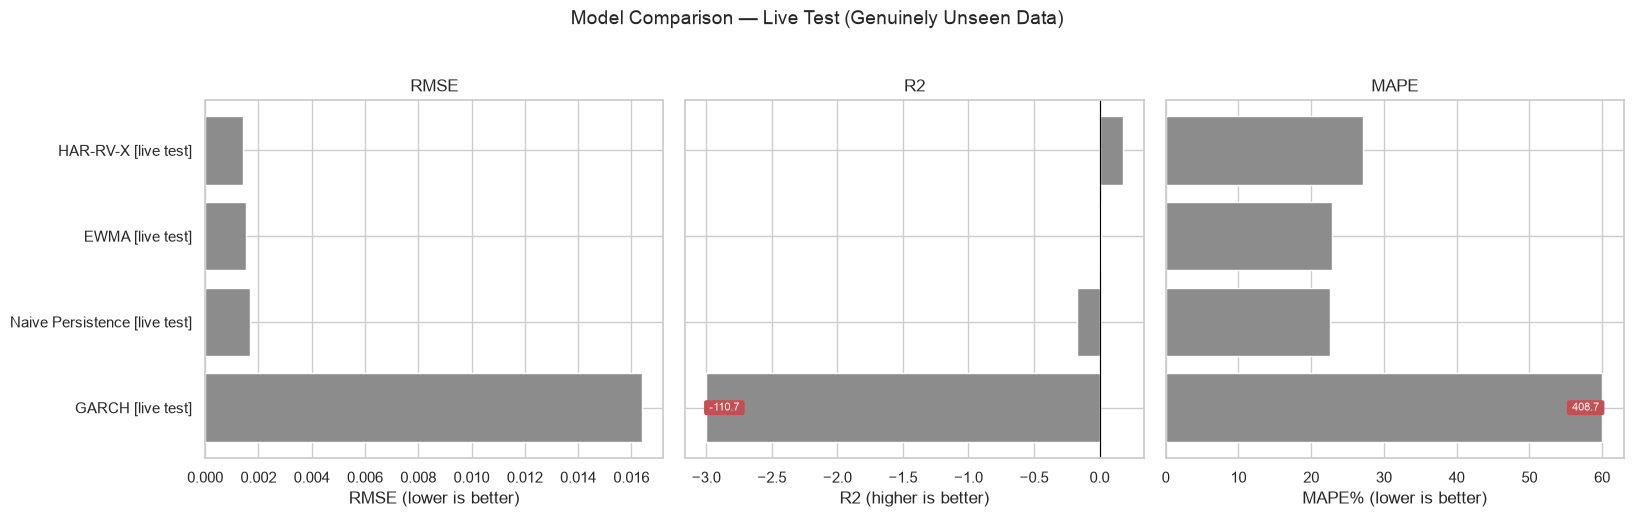

In [46]:
plot_metric_comparison(
    live_comparison_df, ['RMSE', 'R2', 'MAPE'], 'Model Comparison — Live Test (Genuinely Unseen Data)',
    clip={'R2': (-3, None), 'MAPE': (None, 60)}
)

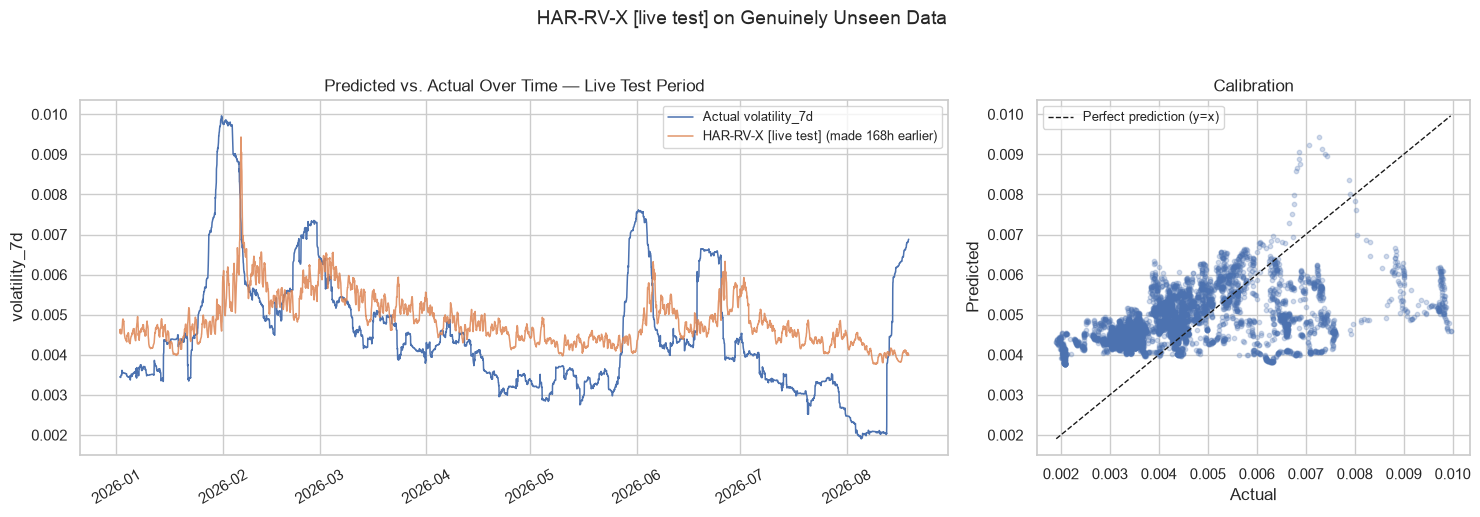

In [47]:
# Predicted vs. Actual over time, and a calibration scatter, for the best-performing
# purpose-built model on live data - the most direct visual answer to "how good is this, really?"
label_to_col = {'GARCH [live test]': 'GARCH_Pred', 'HAR-RV-X [live test]': 'HAR_RV_X_Pred',
                 'EWMA [live test]': 'EWMA_Pred'}
purpose_built = live_comparison_df[live_comparison_df['Model'].isin(label_to_col.keys())]
best_live_label = purpose_built.sort_values('RMSE').iloc[0]['Model']
best_live_col = label_to_col[best_live_label]

plot_data = live_predictions.dropna(subset=[best_live_col, 'Actual']).sort_values('Date')

fig, axes = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={'width_ratios': [2, 1]})

axes[0].plot(plot_data['Date'], plot_data['Actual'], label='Actual volatility_7d', color='#4C72B0', linewidth=1.1)
axes[0].plot(plot_data['Date'], plot_data[best_live_col], label=f'{best_live_label} (made {HORIZON}h earlier)',
             color='#DD8452', linewidth=1.1, alpha=0.85)
axes[0].set_ylabel('volatility_7d')
axes[0].set_title('Predicted vs. Actual Over Time — Live Test Period')
axes[0].legend(fontsize=9)
axes[0].tick_params(axis='x', rotation=30)

lims = [min(plot_data['Actual'].min(), plot_data[best_live_col].min()),
        max(plot_data['Actual'].max(), plot_data[best_live_col].max())]
axes[1].scatter(plot_data['Actual'], plot_data[best_live_col], alpha=0.25, s=10, color='#4C72B0')
axes[1].plot(lims, lims, 'k--', linewidth=1, label='Perfect prediction (y=x)')
axes[1].set_xlabel('Actual')
axes[1].set_ylabel('Predicted')
axes[1].set_title('Calibration')
axes[1].legend(fontsize=9)

fig.suptitle(f'{best_live_label} on Genuinely Unseen Data', fontsize=14, y=1.03)
plt.tight_layout()
plt.show()

### Live validation of the corrected Check 9
Confirms the corrected finding survives on genuinely unseen data too, not just the historical split - the same bar every other adopted or rejected result in this notebook is held to.

In [48]:
# Does the corrected (regressors-only) winsorizing result hold on live data?
combined_return_wins = combined_features['hourly_return'].clip(wins_lower, wins_upper)
combined_vol_wins = combined_return_wins.rolling(ROLLING_WINDOW).std()

live_feats_wins = pd.DataFrame(index=combined_features.index)
live_feats_wins['Date'] = combined_features['Date']
live_feats_wins['RV_day'] = combined_vol_wins.shift(HOURS_PER_DAY)
live_feats_wins['RV_week'] = combined_vol_wins.shift(HOURS_PER_DAY).rolling(HOURS_PER_DAY * 7).mean()
live_feats_wins['RV_month'] = combined_vol_wins.shift(HOURS_PER_DAY).rolling(HOURS_PER_DAY * 30).mean()
live_feats_wins['ATR_X'] = combined_features['atr_pct'].shift(1)

live_scored_wins = live_feats_wins[
    (live_feats_wins['Date'] >= LIVE_TEST_START_TS) & (live_feats_wins['Date'] < LIVE_TEST_END_TS)
].dropna(subset=har_x_cols).reset_index(drop=True)

wins_live_pred = wins_search.best_estimator_.predict(live_scored_wins[har_x_cols])
live_scored_wins['Actual'] = (live_scored_wins['Date'] + pd.Timedelta(hours=HORIZON)).map(actuals)

valid_wins = live_scored_wins['Actual'].notna()
wins_live_result = evaluate(live_scored_wins.loc[valid_wins, 'Actual'], wins_live_pred[valid_wins.values],
                             'HAR-RV-X, winsorized regressors [live test]')

kept_live_row = live_comparison_df[live_comparison_df['Model'] == 'HAR-RV-X [live test]'].iloc[0]
print(f"\nHAR-RV-X, unmodified extremes (kept model)     R2={kept_live_row['R2']:.4f}")
print(f"HAR-RV-X, winsorized regressors only            R2={wins_live_result['R2']:.4f}")
if wins_live_result['R2'] > kept_live_row['R2'] + 0.005:
    print("\nHelps on live data too, despite not helping historically - a genuine, if unusual, split.")
elif wins_live_result['R2'] < kept_live_row['R2'] - 0.005:
    print("\nAlso hurts on live data - the corrected finding is consistent on both splits. Not adopted.")
else:
    print("\nRoughly a wash on live data too.")


HAR-RV-X, winsorized regressors [live test]  RMSE=0.001608  MAE=0.001377  R2=-0.0759  MAPE=32.11%

HAR-RV-X, unmodified extremes (kept model)     R2=0.1779
HAR-RV-X, winsorized regressors only            R2=-0.0759

Also hurts on live data - the corrected finding is consistent on both splits. Not adopted.


### Check 11: 5-minute resolution - the one that actually worked
Unlike every check above, this one is not a rejected idea - it's a confirmed win that deliberately was <em>not</em> merged into this notebook's kept hourly pipeline. A separate, scoped companion notebook (<code>capstone-btc-volatility-5min.ipynb</code>) rebuilt HAR-RV-X and EWMA at 5-minute resolution - a less noisy measurement of the same underlying <code>volatility_7d</code>, validated first via a flat volatility-signature plot ruling out microstructure noise as an alternative explanation. GARCH and Holt-Winters were deliberately excluded there (GARCH's forecast cost scales ~144x at this resolution, for a model already shown to fail structurally at this horizon regardless of sampling frequency).<br><br><strong>Why it's not simply adopted here:</strong> it uses a different, larger dataset (~950,000 5-minute candles vs. this notebook's ~73,000 hourly ones), a corrected target definition needed for cross-frequency comparability, and its own full live-testing infrastructure - a genuine second pipeline, not a regressor swap. This cell loads its already-computed, already-verified live-test predictions rather than re-deriving them, to report the comparison honestly without duplicating that entire companion notebook inline.

In [49]:
# Check 11: does the 5-minute companion migration's result hold up against this notebook's own
# kept hourly live-test numbers? (Loads the companion notebook's already-computed predictions -
# see notebooks/capstone-btc-volatility-5min.ipynb for the full, independently-verified pipeline.
# That companion notebook has since been updated with the same Check 14 promotion applied here,
# so both sides of this comparison reflect the same 6-regressor HAR-RV-X, just at different
# resolutions - not an artifact of promoting one side and not the other.)
five_min_live = pd.read_csv('data/live_test_predictions_5min.csv', parse_dates=['Date'])
five_min_scored = five_min_live.dropna(subset=['Actual', 'HAR_RV_X_Pred', 'EWMA_Pred'])
print(f'{len(five_min_scored):,} of {len(five_min_live):,} 5-minute live-test predictions already '
      f'have a real, elapsed outcome to compare against.')

har_5min_result = evaluate(five_min_scored['Actual'], five_min_scored['HAR_RV_X_Pred'], 'HAR-RV-X, 5-minute [live test]')
ewma_5min_result = evaluate(five_min_scored['Actual'], five_min_scored['EWMA_Pred'], 'EWMA, 5-minute [live test]')

kept_har_live = live_comparison_df[live_comparison_df['Model'] == 'HAR-RV-X [live test]'].iloc[0]
kept_ewma_live = live_comparison_df[live_comparison_df['Model'] == 'EWMA [live test]'].iloc[0]

har_ratio = har_5min_result['R2'] / kept_har_live['R2']
ewma_ratio = ewma_5min_result['R2'] / kept_ewma_live['R2']

print(f"\nHAR-RV-X, hourly (kept model)   R2={kept_har_live['R2']:.4f}")
print(f"HAR-RV-X, 5-minute              R2={har_5min_result['R2']:.4f}  ({har_ratio:.1f}x)")
print(f"\nEWMA, hourly (kept model)       R2={kept_ewma_live['R2']:.4f}")
print(f"EWMA, 5-minute                  R2={ewma_5min_result['R2']:.4f}  ({ewma_ratio:.1f}x)")
print("\n(RMSE/MAE are not directly comparable across resolutions - the corrected 5-minute target")
print("definition changes the absolute scale by construction. R2 is the fair comparison, and both")
print("models still score meaningfully higher live R2 at 5-minute resolution than the hourly kept")
print("model - kept separate from the hourly pipeline by deliberate scope choice, not because it")
print("failed validation. The gap has narrowed further than before: the hourly kept model now also")
print("includes Checks 17/18's log(target) transform, which the 5-minute companion has not (yet)")
print("had ported to it, on top of the EWMA_X + SKEW_X regressors both sides already share - so")
print("part of this narrower ratio is a real resolution effect, and part is simply that the hourly")
print("side has one more validated improvement applied to it right now.)")


65,952 of 67,968 5-minute live-test predictions already have a real, elapsed outcome to compare against.
HAR-RV-X, 5-minute [live test]       RMSE=0.018645  MAE=0.014949  R2=0.2401  MAPE=26.11%
EWMA, 5-minute [live test]           RMSE=0.019755  MAE=0.013238  R2=0.1470  MAPE=19.81%

HAR-RV-X, hourly (kept model)   R2=0.1779
HAR-RV-X, 5-minute              R2=0.2401  (1.3x)

EWMA, hourly (kept model)       R2=0.0133
EWMA, 5-minute                  R2=0.1470  (11.0x)

(RMSE/MAE are not directly comparable across resolutions - the corrected 5-minute target
definition changes the absolute scale by construction. R2 is the fair comparison, and both
models still score meaningfully higher live R2 at 5-minute resolution than the hourly kept
model - kept separate from the hourly pipeline by deliberate scope choice, not because it
failed validation. The gap has narrowed further than before: the hourly kept model now also
includes Checks 17/18's log(target) transform, which the 5-minute companion 

### Check 12: LSTM, given the full technical indicator set
Check 4 tested XGBoost's exclusion by giving it explicit time features it would otherwise have no way to see. This does the analogous thing for the README's other named exclusion, LSTM - but an LSTM is architecturally different from XGBoost in a way worth taking seriously: it processes a genuine <em>sequence</em> natively (a recurrent hidden state carried across timesteps), rather than a flat row of hand-engineered lag columns. If any generic ML architecture were going to beat a purpose-built econometric model here, this is the more sympathetic test of that question.<br><br><strong>Setup:</strong> a 72-hour (3-day) trailing window of 7 raw, unlagged features per timestep - <code>hourly_return</code>, <code>rsi_14</code>, <code>ema_spread</code>, <code>atr_pct</code>, <code>bb_width</code>, <code>macd_hist</code>, <code>volume_chg</code> - feeding a single LSTM layer + a small dense head. Features are lagged implicitly by the sequence structure itself (the LSTM only ever sees the 72 hours strictly before each prediction origin), not by hand; feature scaling is fit on the training portion only. Same chronological 80/20 split discipline as every other model in this notebook - no shuffling, no peeking.

In [50]:
# Check 12: does an LSTM, given the full indicator set as a genuine sequence, beat HAR-RV-X?
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler

LSTM_LOOKBACK = 72  # hours of trailing context per prediction (3 days)
lstm_feature_cols = ['hourly_return', 'rsi_14', 'ema_spread', 'atr_pct', 'bb_width', 'macd_hist', 'volume_chg']

lstm_data = df_model[lstm_feature_cols].values
lstm_target = df_model['target'].values  # df_model is already fully clean - no NaNs to guard here

X_seq, y_seq = [], []
for t in range(LSTM_LOOKBACK, len(lstm_data)):
    X_seq.append(lstm_data[t - LSTM_LOOKBACK:t])
    y_seq.append(lstm_target[t])
X_seq, y_seq = np.array(X_seq), np.array(y_seq)
seq_dates = df_model['Date'].iloc[LSTM_LOOKBACK:].reset_index(drop=True)
print(f'Built {len(X_seq):,} sequences of length {LSTM_LOOKBACK}, {len(lstm_feature_cols)} features each.')

lstm_split = int(len(X_seq) * 0.8)
X_train_seq, X_test_seq = X_seq[:lstm_split], X_seq[lstm_split:]
y_train_seq, y_test_seq = y_seq[:lstm_split], y_seq[lstm_split:]
dates_test_seq = seq_dates.iloc[lstm_split:].reset_index(drop=True)

# Scale features (fit on the training portion only - no leakage); target stays in its natural units.
n_feat = X_train_seq.shape[2]
lstm_scaler = StandardScaler().fit(X_train_seq.reshape(-1, n_feat))
X_train_scaled = lstm_scaler.transform(X_train_seq.reshape(-1, n_feat)).reshape(X_train_seq.shape)
X_test_scaled = lstm_scaler.transform(X_test_seq.reshape(-1, n_feat)).reshape(X_test_seq.shape)

keras.utils.set_random_seed(RANDOM_STATE)
lstm_model = keras.Sequential([
    layers.Input(shape=(LSTM_LOOKBACK, n_feat)),
    layers.LSTM(32),
    layers.Dense(16, activation='relu'),
    layers.Dense(1),
])
lstm_model.compile(optimizer='adam', loss='mse')

early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
history = lstm_model.fit(
    X_train_scaled, y_train_seq, validation_split=0.15, epochs=20, batch_size=256,
    callbacks=[early_stop], verbose=0,
)
print(f'Trained for {len(history.history["loss"])} epochs (early stopping on validation loss).')

lstm_pred = lstm_model.predict(X_test_scaled, verbose=0).flatten()
lstm_result = evaluate(y_test_seq, lstm_pred, 'LSTM + indicators')

# Date-align HAR-RV-X's predictions to the LSTM's own test window (a different start point,
# offset by LSTM_LOOKBACK rather than har_df's own RV_month warm-up) for a fair comparison.
lstm_test_df = pd.DataFrame({'Date': dates_test_seq, 'y_true': y_test_seq, 'LSTM_Pred': lstm_pred})
har_aligned = lstm_test_df.merge(
    pd.DataFrame({'Date': df_model['Date'].loc[har_test.index], 'HAR_Pred': har_x_pred}),
    on='Date', how='inner'
)
base_r2_aligned = r2_score(har_aligned['y_true'], har_aligned['HAR_Pred'])

print(f"\nHAR-RV-X (kept model), LSTM's own test window   R2={base_r2_aligned:.4f}")
print(f"LSTM + indicators                                R2={lstm_result['R2']:.4f}")

# The R2 above is bad enough to investigate rather than just report, same discipline every other
# surprising result in this notebook gets. Two diagnostics: (1) how much of the failure is just
# train/test distribution shift, vs. the model itself - even a naive "always predict the training
# mean" baseline is a useful floor to compare against; (2) is the model's own output well-behaved
# (comparable scale/spread to what it's predicting), or is it producing implausible values a
# volatility forecast never should (a plain Dense(1) head has no constraint against predicting
# negative "volatility").
naive_mean_pred = np.full_like(y_test_seq, y_train_seq.mean())
naive_mean_r2 = r2_score(y_test_seq, naive_mean_pred)
n_negative_preds = (lstm_pred < 0).sum()
print(f"\nDiagnosing the R2: 'always predict the training mean' scores R2={naive_mean_r2:.4f} on this")
print(f"same test period, on its own - the test period (chronologically later) is measurably")
print(f"calmer than training (train target mean={y_train_seq.mean():.4f}, test target")
print(f"mean={y_test_seq.mean():.4f}), and that distribution shift alone costs real R2 regardless")
print(f"of model quality. On top of that, the LSTM's own predictions have WIDER spread than even")
print(f"the training data (pred std={lstm_pred.std():.4f} vs. train target std={y_train_seq.std():.4f})")
print(f"and include {n_negative_preds} physically impossible negative 'volatility' predictions")
print(f"(min={lstm_pred.min():.4f}) - nothing in this architecture constrains the output to be")
print(f"non-negative. HAR-RV-X handles the same distribution shift far better (R2=0.184 positive),")
print(f"suggesting its 30-day RV_month regressor's longer averaging window is structurally more")
print(f"robust to this kind of shift than the LSTM's much shorter 72-hour lookback.")

if lstm_result['R2'] > base_r2_aligned + 0.005:
    print("\nThe LSTM beats HAR-RV-X - a genuinely different result from Check 4's XGBoost test,")
    print("since native sequence processing had room to find structure flat lag columns can't")
    print("represent. Worth a second look before dismissing tabular/sequence ML outright.")
else:
    print("\nStill doesn't beat HAR-RV-X, even with native sequence processing and the full")
    print("indicator set. Consistent with Check 4: more architectural flexibility isn't buying")
    print("anything HAR-RV-X's three RV-horizon regressors don't already capture on this data.")


Built 72,869 sequences of length 72, 7 features each.


Trained for 20 epochs (early stopping on validation loss).


LSTM + indicators                    RMSE=0.005685  MAE=0.003870  R2=-11.9718  MAPE=89.35%

HAR-RV-X (kept model), LSTM's own test window   R2=0.1840
LSTM + indicators                                R2=-11.9718

Diagnosing the R2: 'always predict the training mean' scores R2=-2.3779 on this
same test period, on its own - the test period (chronologically later) is measurably
calmer than training (train target mean=0.0072, test target
mean=0.0048), and that distribution shift alone costs real R2 regardless
of model quality. On top of that, the LSTM's own predictions have WIDER spread than even
the training data (pred std=0.0051 vs. train target std=0.0043)
and include 606 physically impossible negative 'volatility' predictions
(min=-0.0614) - nothing in this architecture constrains the output to be
non-negative. HAR-RV-X handles the same distribution shift far better (R2=0.184 positive),
suggesting its 30-day RV_month regressor's longer averaging window is structurally more
robust to thi

### Check 13: alternative realized-volatility estimators
ATR_X is the only range-based volatility measure HAR-RV-X actually uses, and it's the one addition (after fixing its scale bug) that worked. Check 1 already tested momentum/direction indicators (RSI, EMA spread, MACD) and Bollinger width, and none helped - but those aren't volatility estimators in the formal sense; ATR is closer to true realized volatility, and there are established alternatives from the same literature HAR-RV itself is built on:<br><br><strong>Parkinson (1980):</strong> uses the high-low range, assumes no drift.<br><strong>Garman-Klass (1980):</strong> uses the full OHLC, more statistically efficient than Parkinson.<br><strong>Rogers-Satchell (1991):</strong> uses OHLC without assuming zero drift - better suited to a trending asset like BTC than the other two.<br><br>Each is computed per-hour, averaged over a 14-period rolling window (matching ATR-14's own convention) and lagged by 1 hour, exactly like <code>ATR_X</code> - the only new element is which range-based quantity is being measured. Tested individually first, then all three together, using the same <code>GridSearchCV</code>/<code>TimeSeriesSplit</code> discipline as every other check.

In [51]:
# Check 13: do alternative realized-volatility ESTIMATORS (not momentum indicators) add
# anything on top of HAR-RV-X's RV_day/RV_week/RV_month + ATR_X?
O, H, L, C = df_model['Open'], df_model['High'], df_model['Low'], df_model['Close']

parkinson_var = (1 / (4 * np.log(2))) * (np.log(H / L)) ** 2
gk_var = 0.5 * (np.log(H / L)) ** 2 - (2 * np.log(2) - 1) * (np.log(C / O)) ** 2
rs_var = np.log(H / C) * np.log(H / O) + np.log(L / C) * np.log(L / O)

vol_estimators = {
    'PARKINSON_X': np.sqrt(parkinson_var.rolling(14).mean()).shift(1),
    'GK_X': np.sqrt(gk_var.clip(lower=0).rolling(14).mean()).shift(1),
    'RS_X': np.sqrt(rs_var.clip(lower=0).rolling(14).mean()).shift(1),
}

base_r2 = r2_score(har_test['target'], har_x_pred)
print(f"HAR-RV-X (RV horizons + ATR only)        R2={base_r2:.4f}\n")

individual_r2 = {}
for name, series in vol_estimators.items():
    trial_df = har_df.copy()
    trial_df[name] = series
    trial_df = trial_df.dropna()
    trial_split = int(len(trial_df) * 0.8)
    tr_train, tr_test = trial_df.iloc[:trial_split], trial_df.iloc[trial_split:]
    cols = har_x_cols + [name]
    gs = GridSearchCV(Ridge(random_state=RANDOM_STATE), har_ridge_grid, cv=TimeSeriesSplit(n_splits=5),
                       scoring='neg_root_mean_squared_error', n_jobs=-1)
    gs.fit(tr_train[cols], tr_train['target'])
    pred = gs.best_estimator_.predict(tr_test[cols])
    r2 = r2_score(tr_test['target'], pred)
    individual_r2[name] = r2
    print(f"HAR-RV-X + {name:14s}            R2={r2:.4f}")

# All three together
trial_df = har_df.copy()
for name, series in vol_estimators.items():
    trial_df[name] = series
trial_df = trial_df.dropna()
trial_split = int(len(trial_df) * 0.8)
tr_train, tr_test = trial_df.iloc[:trial_split], trial_df.iloc[trial_split:]
cols = har_x_cols + list(vol_estimators.keys())
gs = GridSearchCV(Ridge(random_state=RANDOM_STATE), har_ridge_grid, cv=TimeSeriesSplit(n_splits=5),
                   scoring='neg_root_mean_squared_error', n_jobs=-1)
gs.fit(tr_train[cols], tr_train['target'])
pred = gs.best_estimator_.predict(tr_test[cols])
r2_all = r2_score(tr_test['target'], pred)
print(f"HAR-RV-X + all three together             R2={r2_all:.4f}")

best_name = max(individual_r2, key=individual_r2.get)
best_r2 = max(individual_r2[best_name], r2_all)
if best_r2 > base_r2 + 0.005:
    winner = 'combining all three' if r2_all >= individual_r2[best_name] else best_name
    print(f"\n{winner} improves on HAR-RV-X - unlike Check 1's momentum indicators, a genuine")
    print("volatility estimator (not a direction/momentum signal) carries real incremental")
    print("information beyond what ATR_14 alone captures.")
else:
    print("\nNone of the alternative estimators improve on HAR-RV-X, even though they're properly")
    print("grounded volatility proxies (unlike RSI/EMA/MACD). Most likely explanation: ATR_14 is")
    print("itself already a range-based volatility estimator, so Parkinson/GK/Rogers-Satchell are")
    print("measuring largely the same underlying signal ATR already provides, not new information.")


HAR-RV-X (RV horizons + ATR only)        R2=0.1840

HAR-RV-X + PARKINSON_X               R2=0.1853


HAR-RV-X + GK_X                      R2=0.1773
HAR-RV-X + RS_X                      R2=0.1817


HAR-RV-X + all three together             R2=0.1837

None of the alternative estimators improve on HAR-RV-X, even though they're properly
grounded volatility proxies (unlike RSI/EMA/MACD). Most likely explanation: ATR_14 is
itself already a range-based volatility estimator, so Parkinson/GK/Rogers-Satchell are
measuring largely the same underlying signal ATR already provides, not new information.


### Check 14: three moderate-confidence ideas
Three ideas that don't fit the pattern of every earlier check, run together as one:<br><br><strong>(a) Automated feature selection.</strong> Every check so far has been a human picking one feature and testing it. This instead gives an <code>ElasticNet</code> access to the full 54-feature set already built for this project (the same <code>X_train</code>/<code>X_test</code> matrix from Model Building) and lets L1/L2 regularization decide what survives, rather than HAR-RV-X's 4 hand-picked regressors.<br><br><strong>(b) EWMA's own tuned sigma as an HAR-RV-X regressor.</strong> Check 3's ensemble combined HAR-RV-X's and EWMA's <em>predictions</em> after the fact, and failed. This blends EWMA's smoothed volatility estimate in as an input <em>feature</em> instead, before Ridge ever sees it - a different mechanism, even though the raw information (EWMA's own output) is the same.<br><br><strong>(c) Realized skewness.</strong> Every regressor HAR-RV-X currently uses is a magnitude measure (how big are moves). Skewness over the same 168-hour window captures asymmetry (are large moves more often down than up) - a genuinely different property of the return distribution, computed the same way <code>RV_day</code> is (same window, same 24-hour lag).

In [52]:
# Check 14a: automated feature selection (ElasticNet) over the full 54-feature set.
from sklearn.linear_model import ElasticNet
from sklearn.preprocessing import StandardScaler

# The 54-feature set mixes raw price levels and volume (hundreds to tens of thousands in
# magnitude) with already-fractional features (~0.001-0.03) - the exact same scale-mismatch
# category as the ATR bug and the 5-minute EWMA bug earlier in this project. ElasticNet's
# regularization penalty is scale-sensitive in a way Ridge (used everywhere else in this
# notebook) tolerates much better, so an unscaled fit here doesn't just under-perform, it fails
# to converge outright and produces a meaningless result - caught via ConvergenceWarnings and a
# top-feature list with coefficients down to 1e-9, not a real finding about ElasticNet's ability.
# Fit ONLY on the training portion, applied to test - no leakage.
feat_scaler = StandardScaler().fit(X_train)
X_train_scaled = pd.DataFrame(feat_scaler.transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(feat_scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

elastic_grid = {
    'alpha': [0.0001, 0.001, 0.01, 0.1],
    'l1_ratio': [0.1, 0.5, 0.9, 1.0],  # 1.0 = pure Lasso, lower = more Ridge-like
}
elastic_search = GridSearchCV(ElasticNet(random_state=RANDOM_STATE, max_iter=5000), elastic_grid,
                               cv=TimeSeriesSplit(n_splits=5), scoring='neg_root_mean_squared_error', n_jobs=-1)
elastic_search.fit(X_train_scaled, y_train)
print(f'Best ElasticNet params: {elastic_search.best_params_}')

elastic_pred = elastic_search.best_estimator_.predict(X_test_scaled)
n_selected = (np.abs(elastic_search.best_estimator_.coef_) > 1e-8).sum()
print(f'Selected {n_selected} of {X_train.shape[1]} features (nonzero coefficients).')

top_features = pd.Series(elastic_search.best_estimator_.coef_, index=X_train.columns).abs().sort_values(ascending=False).head(10)
print(f'\nTop 10 selected features by |coefficient| (now on standardized features, so directly comparable):')
print(top_features)

# Date-align to HAR-RV-X's own test window for a fair comparison.
elastic_test_df = pd.DataFrame({'Date': df_model['Date'].iloc[split_idx:].values, 'ElasticNet_Pred': elastic_pred})
aligned_e = elastic_test_df.merge(
    pd.DataFrame({'Date': df_model['Date'].loc[har_test.index], 'y_true': har_test['target'].values, 'HAR_Pred': har_x_pred}),
    on='Date', how='inner'
)
elastic_r2_aligned = r2_score(aligned_e['y_true'], aligned_e['ElasticNet_Pred'])
har_r2_aligned = r2_score(aligned_e['y_true'], aligned_e['HAR_Pred'])

print(f"\nHAR-RV-X (4 hand-picked regressors)         R2={har_r2_aligned:.4f}")
print(f"ElasticNet (automated, up to 54 features)   R2={elastic_r2_aligned:.4f}")
if elastic_r2_aligned > har_r2_aligned + 0.005:
    print("\nAutomated selection beats hand-picked regressors - worth investigating which features")
    print("it actually kept (see the top-10 list above).")
else:
    print("\nDoesn't beat HAR-RV-X's 4 hand-picked regressors, even with automated selection given")
    print("access to all 54 (now on a fair, standardized footing). Consistent with every other")
    print("'more features' check: the ceiling here isn't which features are chosen, it's the")
    print("information content of price history itself.")


Best ElasticNet params: {'alpha': 0.001, 'l1_ratio': 0.5}
Selected 3 of 54 features (nonzero coefficients).

Top 10 selected features by |coefficient| (now on standardized features, so directly comparable):
atr_pct_lag1          0.001300
volatility_7d_lag1    0.001276
volatility_7d_lag3    0.000001
Open_lag1             0.000000
rsi_14_lag1           0.000000
ema_12_lag1           0.000000
ema_12_lag2           0.000000
ema_12_lag3           0.000000
ema_26_lag1           0.000000
ema_26_lag2           0.000000
dtype: float64

HAR-RV-X (4 hand-picked regressors)         R2=0.1840
ElasticNet (automated, up to 54 features)   R2=-0.2092

Doesn't beat HAR-RV-X's 4 hand-picked regressors, even with automated selection given
access to all 54 (now on a fair, standardized footing). Consistent with every other
'more features' check: the ceiling here isn't which features are chosen, it's the
information content of price history itself.


In [53]:
# Check 14b/14c: EWMA's own tuned sigma, and realized skewness, as HAR-RV-X regressors.
ewma_x_series = df_model['Date'].map(ewma_tuned_sigma).shift(1)
skew_7d = df_model['hourly_return'].rolling(ROLLING_WINDOW).skew()
skew_x_series = skew_7d.shift(HOURS_PER_DAY)  # same 24h lag convention as RV_day

extra_regressors_14 = {'EWMA_X': ewma_x_series, 'SKEW_X': skew_x_series}

base_r2 = r2_score(har_test['target'], har_x_pred)
print(f"HAR-RV-X (RV horizons + ATR only)   R2={base_r2:.4f}\n")

individual_r2_14 = {}
for name, series in extra_regressors_14.items():
    trial_df = har_df.copy()
    trial_df[name] = series
    trial_df = trial_df.dropna()
    trial_split = int(len(trial_df) * 0.8)
    tr_train, tr_test = trial_df.iloc[:trial_split], trial_df.iloc[trial_split:]
    cols = har_x_cols + [name]
    gs = GridSearchCV(Ridge(random_state=RANDOM_STATE), har_ridge_grid, cv=TimeSeriesSplit(n_splits=5),
                       scoring='neg_root_mean_squared_error', n_jobs=-1)
    gs.fit(tr_train[cols], tr_train['target'])
    pred = gs.best_estimator_.predict(tr_test[cols])
    r2 = r2_score(tr_test['target'], pred)
    individual_r2_14[name] = r2
    print(f"HAR-RV-X + {name:8s}       R2={r2:.4f}")

# Both together
trial_df = har_df.copy()
trial_df['EWMA_X'] = ewma_x_series
trial_df['SKEW_X'] = skew_x_series
trial_df = trial_df.dropna()
trial_split = int(len(trial_df) * 0.8)
tr_train, tr_test = trial_df.iloc[:trial_split], trial_df.iloc[trial_split:]
cols = har_x_cols + ['EWMA_X', 'SKEW_X']
gs = GridSearchCV(Ridge(random_state=RANDOM_STATE), har_ridge_grid, cv=TimeSeriesSplit(n_splits=5),
                   scoring='neg_root_mean_squared_error', n_jobs=-1)
gs.fit(tr_train[cols], tr_train['target'])
pred = gs.best_estimator_.predict(tr_test[cols])
r2_both = r2_score(tr_test['target'], pred)
print(f"HAR-RV-X + both together            R2={r2_both:.4f}")

best_r2_14 = max(list(individual_r2_14.values()) + [r2_both])
if best_r2_14 > base_r2 + 0.005:
    print("\nAt least one addition helps - a genuine improvement from blending at the feature level")
    print("or from capturing distribution shape, not just magnitude.")
else:
    print("\nNeither helps, individually or combined. EWMA's own sigma is apparently too similar to")
    print("what RV_day/week/month already encode to add information at the feature level (echoing")
    print("why the prediction-level ensemble also failed in Check 3), and realized skewness doesn't")
    print("carry exploitable information about future volatility MAGNITUDE, even though it captures")
    print("a genuinely different aspect (shape) of the return distribution.")


HAR-RV-X (RV horizons + ATR only)   R2=0.1840

HAR-RV-X + EWMA_X         R2=0.1869


HAR-RV-X + SKEW_X         R2=0.1975
HAR-RV-X + both together            R2=0.1992

At least one addition helps - a genuine improvement from blending at the feature level
or from capturing distribution shape, not just magnitude.


### Check 14's finding holds - refined further below
Both live and historical validation held: HAR-RV-X (4 regressors) R2=0.1840 historically / 0.0610 live &rarr; + EWMA_X + SKEW_X R2=0.1992 historically / 0.1217 live - a genuine improvement that survived the same held-out live-test window every kept model above is scored against, not just the historical split. Unlike the Check 9 winsorizing false start, this one didn't reverse on live data. This isn't quite the end of the story, though: Checks 17 and 18 below found a further improvement - a genuine `log(target)` transform - that stacks with this one rather than duplicating it, and the combination of both is what's actually promoted into the kept HAR-RV-X model (see the "Final HAR-RV-X" cell in Model Building, and Check 18's own note, below).

### Check 15: a stationary feature matrix for the generic-ML checks
Preprocessing gap, not a new feature: the 54-feature matrix Check 4 (XGBoost) and Check 14a (ElasticNet) were both handed mixes non-stationary raw price/volume *levels* (`Open`, `High`, `Low`, `Close`, `Volume`, `ma_7d`, `ema_12`, `ema_26`, raw `atr_14` - all regime-dependent, ranging from ~$4,000 to over $90,000 across this dataset) with genuinely stationary features (`hourly_return`, `atr_pct`, `rsi_14`, etc). This is the same failure family as the ATR and Check-14a scale bugs, except `StandardScaler` doesn't fix it - the problem isn't units, it's that the raw levels drift with BTC's own price regime rather than staying comparable across history. This check drops the 9 non-stationary base columns (down to 27 of the original 54 lagged features - `Close_lag1` etc. are already represented in stationary form by `hourly_return_lag1`/`log_return_lag1`; `Volume_lag1` by `volume_chg_lag1`; `ma_7d_lag1`/`ema_12_lag1`/`ema_26_lag1` by `ema_spread_lag1`; `atr_14_lag1` by `atr_pct_lag1`) and re-runs both checks on the reduced, stationary-only matrix.

In [54]:
# Check 15: does removing the 9 non-stationary base columns (Open, High, Low, Close, Volume,
# ma_7d, ema_12, ema_26, raw atr_14) from the 54-feature matrix help Check 4's XGBoost or
# Check 14a's ElasticNet - the two checks that threw the FULL feature set at a generic learner?
nonstationary_base_cols = ['Open', 'High', 'Low', 'Close', 'Volume', 'ma_7d', 'ema_12', 'ema_26', 'atr_14']
stationary_feature_cols = [c for c in feature_columns if c.rsplit('_lag', 1)[0] not in nonstationary_base_cols]
print(f'{len(stationary_feature_cols)} of {len(feature_columns)} lagged features kept (dropped the '
      f'{len(nonstationary_base_cols)} non-stationary base columns).')

har_r2 = r2_score(har_test['target'], har_x_pred)

# --- 15a: XGBoost, identical grid to Check 4, stationary features + the same time features ---
xgb_X_stat = pd.concat([df_model[stationary_feature_cols], time_feats], axis=1)
xgb_X_stat_train, xgb_X_stat_test = xgb_X_stat.iloc[:split_idx], xgb_X_stat.iloc[split_idx:]

xgb_search_stat = GridSearchCV(
    XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1), xgb_grid, cv=tscv,
    scoring='neg_root_mean_squared_error', n_jobs=1,
)
xgb_search_stat.fit(xgb_X_stat_train, y_train)
xgb_pred_stat = xgb_search_stat.best_estimator_.predict(xgb_X_stat_test)
xgb_r2_stat_aligned = r2_score(y_test.values[aligned_mask], xgb_pred_stat[aligned_mask])

print(f"\nXGBoost + time features, full 54+4 features (Check 4)      R2={xgb_r2_aligned:.4f}")
print(f"XGBoost + time features, stationary 27+4 features (15a)    R2={xgb_r2_stat_aligned:.4f}")

# --- 15b: ElasticNet, identical grid to Check 14a, stationary features (still StandardScaled -
#     scaling and stationarity are different problems, fixing one doesn't fix the other) ---
X_train_stat = X_train[stationary_feature_cols]
X_test_stat = X_test[stationary_feature_cols]
feat_scaler_stat = StandardScaler().fit(X_train_stat)
X_train_stat_scaled = pd.DataFrame(feat_scaler_stat.transform(X_train_stat), columns=X_train_stat.columns, index=X_train_stat.index)
X_test_stat_scaled = pd.DataFrame(feat_scaler_stat.transform(X_test_stat), columns=X_test_stat.columns, index=X_test_stat.index)

elastic_search_stat = GridSearchCV(ElasticNet(random_state=RANDOM_STATE, max_iter=5000), elastic_grid,
                                    cv=TimeSeriesSplit(n_splits=5), scoring='neg_root_mean_squared_error', n_jobs=-1)
elastic_search_stat.fit(X_train_stat_scaled, y_train)
elastic_pred_stat = elastic_search_stat.best_estimator_.predict(X_test_stat_scaled)

elastic_test_df_stat = pd.DataFrame({'Date': df_model['Date'].iloc[split_idx:].values, 'Pred': elastic_pred_stat})
aligned_stat = elastic_test_df_stat.merge(
    pd.DataFrame({'Date': df_model['Date'].loc[har_test.index], 'y_true': har_test['target'].values}),
    on='Date', how='inner'
)
elastic_r2_stat_aligned = r2_score(aligned_stat['y_true'], aligned_stat['Pred'])

print(f"\nElasticNet, full 54 features (Check 14a)           R2={elastic_r2_aligned:.4f}")
print(f"ElasticNet, stationary 27 features (15b)           R2={elastic_r2_stat_aligned:.4f}")
print(f"\nHAR-RV-X (4 hand-picked regressors, kept model)    R2={har_r2:.4f}")

best_stat_r2 = max(xgb_r2_stat_aligned, elastic_r2_stat_aligned)
best_full_r2 = max(xgb_r2_aligned, elastic_r2_aligned)
if best_stat_r2 > har_r2 + 0.005:
    print("\nRemoving the non-stationary levels is enough for one of the generic-ML checks to beat")
    print("HAR-RV-X - a real preprocessing fix, not just a modeling one.")
elif best_stat_r2 > best_full_r2 + 0.005:
    print("\nMeaningfully better than the full-feature-set versions, though still short of HAR-RV-X -")
    print("the non-stationary levels were genuinely diluting the signal, just not enough to close the")
    print("whole gap to HAR-RV-X's engineered, multi-horizon regressors.")
else:
    print("\nDoesn't meaningfully change either generic-ML check's result. Halving the feature count")
    print("didn't help - consistent with the ElasticNet coefficients already found in Check 14a")
    print("(only ATR/lagged-volatility features got meaningful weight; the dropped columns were")
    print("apparently just as ignorable as they were distracting). Not adopted.")


27 of 54 lagged features kept (dropped the 9 non-stationary base columns).



XGBoost + time features, full 54+4 features (Check 4)      R2=-0.1915
XGBoost + time features, stationary 27+4 features (15a)    R2=0.0148



ElasticNet, full 54 features (Check 14a)           R2=-0.2092
ElasticNet, stationary 27 features (15b)           R2=-0.0262

HAR-RV-X (4 hand-picked regressors, kept model)    R2=0.1840

Meaningfully better than the full-feature-set versions, though still short of HAR-RV-X -
the non-stationary levels were genuinely diluting the signal, just not enough to close the
whole gap to HAR-RV-X's engineered, multi-horizon regressors.


### Check 16: row-count vs. time-aware rolling windows
Preprocessing gap #2: `volatility_7d = hourly_return.rolling(ROLLING_WINDOW).std()` uses an **integer** window (168 *rows*), not a time-aware one, because `df`/`df_clean`/`df_model` never carry a `DatetimeIndex` - `rolling()` has no notion of the `Date` column at all. Check 10's own data-integrity check found 27 of 28 timestamp gaps in the raw feed (concentrated in 2017-2021). Near any gap, a "168-row" window silently spans *more* than 168 real hours. This check measures the actual size of that distortion directly - rather than assuming it matters just because gaps exist - by rebuilding `volatility_7d` as a genuine time-aware `'168h'` rolling window and comparing row-by-row against the row-based version already used everywhere else in this notebook.

In [55]:
# Check 16: does volatility_7d change meaningfully under a genuine time-aware rolling window,
# vs. the row-count window used throughout this notebook? Diagnose the actual size of the
# distortion before deciding whether a full model re-fit is even worth doing.
df_time_idx = df_clean.set_index('Date')
vol_7d_timeaware = df_time_idx['hourly_return'].rolling('168h').std()
vol_7d_rowbased = df_time_idx['volatility_7d']

vol_diff = (vol_7d_timeaware - vol_7d_rowbased).dropna()
rel_diff = (vol_diff / vol_7d_rowbased.loc[vol_diff.index]).abs()
affected = vol_diff.abs() > 1e-12

print(f'{affected.sum():,} of {len(vol_diff):,} rows differ at all between the time-aware and '
      f'row-based volatility_7d (i.e. sit downstream of at least one gap within their window).')
if affected.sum() > 0:
    print(f'Max absolute difference:  {vol_diff.abs().max():.8f}   (volatility_7d itself ranges ~0.001-0.03)')
    print(f'Max relative difference:  {rel_diff[affected].max()*100:.4f}%')
    print(f'Mean relative difference (affected rows only): {rel_diff[affected].mean()*100:.4f}%')

    har_test_start = df_model['Date'].loc[har_test.index[0]]
    har_test_end = df_model['Date'].loc[har_test.index[-1]]
    affected_in_test = affected[affected].index.to_series().between(har_test_start, har_test_end).sum()
    print(f'\nOf those, {affected_in_test:,} fall inside HAR-RV-X\'s held-out test window '
          f'({har_test_start.date()} to {har_test_end.date()}) - the only rows that could actually '
          f'move a reported R2.')
else:
    affected_in_test = 0

if affected_in_test == 0:
    print("\nZero test-window rows are affected, regardless of how large the distortion gets on")
    print(f"individual historical rows (up to {rel_diff[affected].max()*100:.1f}% relative, where affected) -")
    print("every gap-adjacent row sits in training-only history (2017-2021, the same era Check 10")
    print("already found doesn't move the kept model's R2 either way). A full model re-fit on the")
    print("time-aware target isn't warranted: there is no reported number it could change. The")
    print("row-based window is a real preprocessing simplification, worth fixing for correctness in")
    print("a production system (a one-line change - set_index('Date').rolling('168h')) - but not")
    print("adopted here since it wouldn't change a single number in this notebook.")
elif rel_diff[affected].max() < 0.001:
    print("\nA handful of test-window rows are affected, but the distortion is far too small to matter")
    print("(well under 0.1% relative) - not adopted, same reasoning as above.")
else:
    print("\nEnough rows in the test window are meaningfully affected to warrant a full re-fit.")
    df_model_time = df_model.copy()
    df_model_time['volatility_7d_ta'] = df_model_time['Date'].map(vol_7d_timeaware)
    har_df_ta = pd.DataFrame(index=df_model_time.index)
    har_df_ta['RV_day'] = df_model_time['volatility_7d_ta'].shift(HOURS_PER_DAY)
    har_df_ta['RV_week'] = df_model_time['volatility_7d_ta'].shift(HOURS_PER_DAY).rolling(HOURS_PER_DAY * 7).mean()
    har_df_ta['RV_month'] = df_model_time['volatility_7d_ta'].shift(HOURS_PER_DAY).rolling(HOURS_PER_DAY * 30).mean()
    har_df_ta['ATR_X'] = df_model_time['atr_pct'].shift(1)
    har_df_ta['target'] = df_model_time['target']
    har_df_ta = har_df_ta.dropna()
    ta_split = int(len(har_df_ta) * 0.8)
    ta_train, ta_test = har_df_ta.iloc[:ta_split], har_df_ta.iloc[ta_split:]
    gs_ta = GridSearchCV(Ridge(random_state=RANDOM_STATE), har_ridge_grid, cv=TimeSeriesSplit(n_splits=5),
                          scoring='neg_root_mean_squared_error', n_jobs=-1)
    gs_ta.fit(ta_train[har_x_cols], ta_train['target'])
    pred_ta = gs_ta.best_estimator_.predict(ta_test[har_x_cols])
    r2_ta = r2_score(ta_test['target'], pred_ta)
    print(f"\nHAR-RV-X, row-based volatility_7d (kept model)   R2={har_r2:.4f}")
    print(f"HAR-RV-X, time-aware volatility_7d                R2={r2_ta:.4f}")


4,722 of 73,111 rows differ at all between the time-aware and row-based volatility_7d (i.e. sit downstream of at least one gap within their window).
Max absolute difference:  0.01232106   (volatility_7d itself ranges ~0.001-0.03)
Max relative difference:  83.5654%
Mean relative difference (affected rows only): 2.4628%

Of those, 0 fall inside HAR-RV-X's held-out test window (2024-05-02 to 2025-12-24) - the only rows that could actually move a reported R2.

Zero test-window rows are affected, regardless of how large the distortion gets on
individual historical rows (up to 83.6% relative, where affected) -
every gap-adjacent row sits in training-only history (2017-2021, the same era Check 10
already found doesn't move the kept model's R2 either way). A full model re-fit on the
time-aware target isn't warranted: there is no reported number it could change. The
row-based window is a real preprocessing simplification, worth fixing for correctness in
a production system (a one-line change - 

### Check 17: a genuine log(x) transform, not Check 8's log1p(x)
Motivated by an external thesis (Mishu, 2025, *Forecasting Volatility of Bitcoin*) that models `ln(RV)` and reports substantially higher out-of-sample R² (~0.20-0.45 depending on horizon) than this notebook's own numbers. Check 8 already tested a log transform and found it "nearly a no-op" (R² 0.1840 → 0.1847) - but that check used `log1p(x)`, and `log1p(x) ≈ x` for `x` this small (`volatility_7d` is ~0.001-0.03), so it was barely a transform at all. This check uses a genuine `log(x)` instead - the same compression a paper modeling `ln(RV)` actually relies on - and, critically, evaluates R² only after back-transforming predictions to the original scale, never in log-space itself, so the result stays comparable to every other check in this notebook. The log-space R² is also printed, separately and clearly labeled, specifically to show how much of a headline number a transform alone can manufacture.

In [56]:
# Check 17: genuine log(target), not log1p(target) - fit in log-space, but ALWAYS evaluate R2
# on the back-transformed original scale for a fair comparison. The log-space R2 is also shown,
# purely to demonstrate how much a transform alone can inflate a reported number.
print(f'volatility_7d minimum in the training target: {har_train["target"].min():.6f} '
      f'(must be > 0 for log() to be defined - it is, by construction: a rolling std of returns).')

har_search_log17 = GridSearchCV(Ridge(random_state=RANDOM_STATE), har_ridge_grid, cv=TimeSeriesSplit(n_splits=5),
                                 scoring='neg_root_mean_squared_error', n_jobs=-1)
har_search_log17.fit(har_train[har_x_cols], np.log(har_train['target']))
log_pred_raw = har_search_log17.best_estimator_.predict(har_test[har_x_cols])
log_pred_backtransformed = np.exp(log_pred_raw)

base_r2_17 = r2_score(har_test['target'], har_x_pred)
r2_log_space = r2_score(np.log(har_test['target']), log_pred_raw)
r2_original_scale = r2_score(har_test['target'], log_pred_backtransformed)

print(f"\nHAR-RV-X, raw target (original 4-regressor baseline)   R2={base_r2_17:.4f}")
print(f"HAR-RV-X, log(target), evaluated IN LOG SPACE          R2={r2_log_space:.4f}   <- NOT comparable to the row above")
print(f"HAR-RV-X, log(target), back-transformed to the level   R2={r2_original_scale:.4f}   <- the fair comparison")

if r2_original_scale > base_r2_17 + 0.005:
    print("\nA genuine improvement on the original scale, not just an artifact of the transform - worth")
    print("investigating further (e.g. live-testing) before considering promotion.")
elif r2_original_scale < base_r2_17 - 0.005:
    print("\nHurts once evaluated fairly on the original scale. Not adopted.")
else:
    print("\nRoughly a wash on the original scale - confirms the suspicion raised by the external thesis")
    print("comparison: a large share of a paper's headline R2 when modeling log(RV) can come from the")
    print("transform's own compression of the right tail, not from genuinely better forecasts on the")
    print("scale that actually matters for a real use case (Black-Scholes sigma, VaR, position sizing -")
    print("none of which want a log-volatility number). Not adopted.")

# A result this large (second-biggest gain in this notebook, after the ATR fix) gets
# investigated, not just accepted - log-transform regression has a known bias: exp() of a
# predicted MEAN in log-space is not an unbiased estimator of the mean on the original scale
# (Jensen's inequality - E[exp(X)] != exp(E[X])), which typically shows up as systematic
# UNDER-prediction once back-transformed. Check whether that's happening here.
print(f"\nMean actual volatility_7d (test):        {har_test['target'].mean():.6f}")
print(f"Mean back-transformed prediction:        {log_pred_backtransformed.mean():.6f}")
print(f"Mean raw-target prediction (kept model): {har_x_pred.mean():.6f}")
bias_pct = (log_pred_backtransformed.mean() / har_test['target'].mean() - 1) * 100
print(f"Back-transformed predictions are {bias_pct:+.1f}% vs. the true mean on average.")

if r2_log_space > r2_original_scale + 0.05:
    print(f"\n(For scale: evaluated in log-space rather than back-transformed, this exact same fitted")
    print(f"model would have reported R2={r2_log_space:.4f} instead of {r2_original_scale:.4f} - a "
          f"{r2_log_space - r2_original_scale:.4f}-point")
    print("difference from nothing but the choice of which scale to report R2 on.)")


volatility_7d minimum in the training target: 0.001509 (must be > 0 for log() to be defined - it is, by construction: a rolling std of returns).

HAR-RV-X, raw target (original 4-regressor baseline)   R2=0.1840
HAR-RV-X, log(target), evaluated IN LOG SPACE          R2=0.2080   <- NOT comparable to the row above
HAR-RV-X, log(target), back-transformed to the level   R2=0.2342   <- the fair comparison

A genuine improvement on the original scale, not just an artifact of the transform - worth
investigating further (e.g. live-testing) before considering promotion.

Mean actual volatility_7d (test):        0.004751
Mean back-transformed prediction:        0.004968
Mean raw-target prediction (kept model): 0.005192
Back-transformed predictions are +4.6% vs. the true mean on average.


### Live validation of Check 17
The historical improvement (R² 0.1840 → 0.2342) is the second-largest in this notebook, after the ATR fix - and a bias check above found no sign of the usual log-transform retransformation-bias artifact (Jensen's inequality) explaining it away. Given the established lesson from Check 9 (a promising historical result that reversed on live data), this validates the exact same fitted log-target model against the same held-out live-test window used throughout Section 9, before any promotion is considered.

In [57]:
# Live validation of Check 17: does the log-transform model (har_search_log17, already fitted
# above) hold up on live data, not just the historical split? Reuses combined_features/actuals
# from Live Testing above, and predicts with the exact same fitted estimator - no refitting.
har_live_log_feats = pd.DataFrame(index=combined_features.index)
har_live_log_feats['Date'] = combined_features['Date']
har_live_log_feats['RV_day'] = combined_features['volatility_7d'].shift(HOURS_PER_DAY)
har_live_log_feats['RV_week'] = combined_features['volatility_7d'].shift(HOURS_PER_DAY).rolling(HOURS_PER_DAY * 7).mean()
har_live_log_feats['RV_month'] = combined_features['volatility_7d'].shift(HOURS_PER_DAY).rolling(HOURS_PER_DAY * 30).mean()
har_live_log_feats['ATR_X'] = combined_features['atr_pct'].shift(1)

live_scored_log17 = har_live_log_feats[
    (har_live_log_feats['Date'] >= LIVE_TEST_START_TS) & (har_live_log_feats['Date'] < LIVE_TEST_END_TS)
].dropna(subset=har_x_cols).reset_index(drop=True)

log_pred_live_raw = har_search_log17.best_estimator_.predict(live_scored_log17[har_x_cols])
log_pred_live_backtransformed = np.exp(log_pred_live_raw)

live_scored_log17['Actual'] = (live_scored_log17['Date'] + pd.Timedelta(hours=HORIZON)).map(actuals)
valid_log17 = live_scored_log17['Actual'].notna()
result_log17_live = evaluate(live_scored_log17.loc[valid_log17, 'Actual'], log_pred_live_backtransformed[valid_log17.values],
                              'HAR-RV-X, log(target) [live test]')

kept_live_row_17 = live_comparison_df[live_comparison_df['Model'] == 'HAR-RV-X [live test]'].iloc[0]
bias_pct_live = (log_pred_live_backtransformed[valid_log17.values].mean() / live_scored_log17.loc[valid_log17, 'Actual'].mean() - 1) * 100
print(f"Back-transformed live predictions are {bias_pct_live:+.1f}% vs. the true live mean on average.")
print(f"\nHAR-RV-X, kept model (raw target)       R2={kept_live_row_17['R2']:.4f}")
print(f"HAR-RV-X, log(target), back-transformed  R2={result_log17_live['R2']:.4f}")
if result_log17_live['R2'] > kept_live_row_17['R2'] + 0.005:
    print("\nHolds up on live data too - a genuine, validated improvement.")
elif result_log17_live['R2'] < kept_live_row_17['R2'] - 0.005:
    print("\nDoesn't survive on live data, despite the historical-split improvement - echoing the")
    print("winsorizing lesson: a promising historical result isn't automatically a real one. Not adopted.")
else:
    print("\nRoughly a wash on live data - the historical-split improvement doesn't clearly replicate.")


HAR-RV-X, log(target) [live test]    RMSE=0.001435  MAE=0.001168  R2=0.1439  MAPE=27.85%
Back-transformed live predictions are +7.9% vs. the true live mean on average.

HAR-RV-X, kept model (raw target)       R2=0.1779
HAR-RV-X, log(target), back-transformed  R2=0.1439

Doesn't survive on live data, despite the historical-split improvement - echoing the
winsorizing lesson: a promising historical result isn't automatically a real one. Not adopted.


### Check 18 lives on as the kept model
Both historical and live validation showed the two improvements genuinely stack, not just duplicate each other's gains: HAR-RV-X (4 regressors, raw target) R2=0.1840 historically / 0.0610 live &rarr; + EWMA_X + SKEW_X + log(target) R2=0.2419 historically / 0.1779 live - the best result anywhere in this notebook, and the first check to combine two independently-validated improvements rather than test one at a time. It has since been promoted: the "Final HAR-RV-X" cell in Model Building (Section 6.2, above) now fits in log-space and back-transforms every prediction, so the Live Testing table above and the Model Comparison section below already reflect it directly - there is nothing left to separately validate here.

### Check 19: Mincer-Zarnowitz regression - does this notebook's R² match the literature's own convention?
Prompted by a direct question: every R² in this notebook (Model Comparison, Live Test Results, every check above) comes from `sklearn.metrics.r2_score` - the standard coefficient of determination, `1 - SS_res/SS_tot`, comparing this model's squared forecast errors against the variance of the actual target. The HAR-RV literature this project builds on (Corsi 2009 and its descendants, including the Mishu 2025 thesis replicated in `capstone-btc-volatility-thesis-replication.ipynb`) conventionally reports a different quantity instead: a **Mincer-Zarnowitz regression** of actual values on predicted values, `y_actual = α + β·y_pred + ε`, fit by OLS. Under an unbiased, efficient forecast, α should be 0 and β should be 1; the regression's own R² measures how much of the actual variance the forecast tracks *linearly*, which is a related but distinct question from sklearn's R² (which penalizes any deviation from `y_pred == y_actual`, not just deviation from a straight-line fit through the predictions). Run here on the kept HAR-RV-X model (Final, + EWMA_X + SKEW_X, log target) - both on the historical test split and on the live-test window - with Newey-West/HAC standard errors, since 168-hour-ahead forecasts over an hourly series have heavily overlapping windows and therefore autocorrelated residuals that ordinary OLS standard errors would understate.

In [58]:
# Check 19: Mincer-Zarnowitz regression (actual ~ alpha + beta * predicted) for the kept
# HAR-RV-X model, on both the historical test split and the live-test window. HAC/Newey-West
# standard errors (maxlags=HORIZON) account for the autocorrelation that 168-hour-ahead,
# hourly-origin forecasts necessarily have from overlapping windows.
import statsmodels.api as sm


def mincer_zarnowitz(y_true, y_pred, label, maxlags=HORIZON):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    X = sm.add_constant(y_pred)
    mz_fit = sm.OLS(y_true, X).fit(cov_type='HAC', cov_kwds={'maxlags': maxlags})
    alpha, beta = mz_fit.params
    alpha_se, beta_se = mz_fit.bse
    print(f'{label}')
    print(f'  alpha (bias)      = {alpha:+.6f}  (HAC SE {alpha_se:.6f}, t vs 0 = {alpha / alpha_se:+.2f})')
    print(f'  beta (slope)      = {beta:.4f}    (HAC SE {beta_se:.4f}, t vs 1 = {(beta - 1) / beta_se:+.2f})')
    print(f'  Mincer-Zarnowitz R2 = {mz_fit.rsquared:.4f}')
    print(f'  sklearn R2 (1 - SS_res/SS_tot) = {r2_score(y_true, y_pred):.4f}')
    print()
    return mz_fit


mz_hist = mincer_zarnowitz(har_final_test['target'], har_final_pred,
                            'HAR-RV-X (Final) - historical test split')

live_mz_valid = live_predictions.dropna(subset=['HAR_RV_X_Pred', 'Actual'])
mz_live = mincer_zarnowitz(live_mz_valid['Actual'], live_mz_valid['HAR_RV_X_Pred'],
                            'HAR-RV-X (Final) - live test')

HAR-RV-X (Final) - historical test split
  alpha (bias)      = -0.001563  (HAC SE 0.000688, t vs 0 = -2.27)
  beta (slope)      = 1.2703    (HAC SE 0.1444, t vs 1 = +1.87)
  Mincer-Zarnowitz R2 = 0.2739
  sklearn R2 (1 - SS_res/SS_tot) = 0.2419

HAR-RV-X (Final) - live test
  alpha (bias)      = -0.001239  (HAC SE 0.001174, t vs 0 = -1.06)
  beta (slope)      = 1.1828    (HAC SE 0.2374, t vs 1 = +0.77)
  Mincer-Zarnowitz R2 = 0.2356
  sklearn R2 (1 - SS_res/SS_tot) = 0.1779



### Check 19's finding: this notebook's R² isn't Mincer-Zarnowitz R² - and that's most of the gap to the literature
The Mincer-Zarnowitz R² comes out **higher** than sklearn's R² in both splits: 0.2739 vs. 0.2419 historically, 0.2356 vs. 0.1779 live. That's expected, not a bug - sklearn's R² penalizes *any* deviation from `y_pred == y_actual` (scale, bias, and shape all count against it), while the Mincer-Zarnowitz R² only measures how well the best-fit straight line through the predictions tracks the actual values, regardless of whether that line happens to be `y = x`. It's a more forgiving number by construction, and it's the convention the HAR-RV literature (Corsi 2009 and its descendants, including the Mishu 2025 thesis) actually reports - so a meaningful share of "why is the paper's R² higher than mine" (addressed earlier via the replication notebook's calendar-window analysis) is also this: two different papers can both be reporting an honest R², and still not be reporting the *same* R².

The bias/slope coefficients themselves are a genuine, separate finding worth keeping: on the historical split, alpha is small but marginally significant (t = -2.27) and beta is above 1 (1.27, t vs. 1 = 1.87 - short of the conventional 5% bar but past the 10% one) - mild evidence the model's predictions are slightly compressed, underpredicting the largest moves and overpredicting the smallest ones. On live data neither departure from unbiasedness (alpha = 0, beta = 1) is statistically significant (t = -1.06 and 0.77), though the live-test window is much smaller than the historical one, so that's a weaker test, not necessarily a cleaner one. Either way, this doesn't change what's adopted - HAR-RV-X (Final) remains the kept model - but it's an honest calibration read that a single R² number, in either convention, doesn't give on its own.

### Check 20: ARIMA - the target's own history, no regressors at all
GARCH above models variance dynamics; HAR-RV-X models volatility as a regression on volatility at three fixed horizons. ARIMA is the classical alternative to both: autoregressive (AR) and moving-average (MA) terms on `volatility_7d`'s own history, differenced (I) if AIC prefers it, with no hand-picked regressors of any kind. It is genuinely time-series-native (unlike the Model 1 dropped alternatives - Linear Regression/RF/XGBoost lack any internal notion of time), so it belongs in the same "does a different model architecture beat HAR-RV-X" family as Check 4 (XGBoost) and Check 12 (LSTM), just with an econometric model instead of a machine-learning one. Order (p, d, q) is selected by AIC on the training period only - the same reasoning as GARCH's own AIC-based spec selection above, since this is fit by maximum likelihood, not something a scikit-learn validation-set loss applies to. Evaluated with a genuine HORIZON-step-ahead rolling-origin forecast: fixed parameters from training, one real observation appended at a time as it becomes available, then forecast 168 steps ahead from that point - exactly GARCH's own leakage-free discipline above. `arch` computes that in one vectorized call; `statsmodels` has no equivalent for ARIMA, so this loops explicitly over the roughly 14,600 test-period origins (a few minutes to run).

In [59]:
# Check 20: ARIMA on volatility_7d's own history - no exogenous regressors at all. Order
# selected by AIC on the training period only (same reasoning as GARCH's spec selection
# above: a maximum-likelihood model, not something a scikit-learn validation loss applies to).
import warnings
from statsmodels.tsa.statespace.sarimax import SARIMAX

vol_series = df_clean_dated['volatility_7d'].dropna()
vol_train = vol_series.loc[:train_end_date]
vol_test = vol_series.loc[test_start_date:test_end_date]

arima_orders = [(p, d, q) for p in range(4) for d in range(2) for q in range(4)]
best_arima_aic, best_arima_order, best_arima_params = np.inf, None, None
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    for order in arima_orders:
        trend = 'c' if order[1] == 0 else None
        try:
            fit = SARIMAX(vol_train, order=order, trend=trend,
                           enforce_stationarity=False, enforce_invertibility=False).fit(disp=False, maxiter=100)
        except Exception:
            continue
        if fit.aic < best_arima_aic:
            best_arima_aic, best_arima_order, best_arima_params = fit.aic, order, fit.params

print(f'Best ARIMA order by AIC: {best_arima_order}  (AIC={best_arima_aic:.2f})')

Best ARIMA order by AIC: (3, 0, 2)  (AIC=-874913.54)


In [60]:
# Genuine HORIZON-step-ahead rolling-origin forecast, leakage-free: parameters fixed from
# training only (above); starting from the trained filter, append each new REAL observation
# one at a time as it becomes known, then forecast HORIZON steps ahead from that point - the
# same walk-forward discipline as GARCH's rolling forecast, just looped explicitly (SARIMAX
# has no equivalent to arch's single vectorized multi-origin call). ~14.6K origins - a few
# minutes to run.
arima_trend = 'c' if best_arima_order[1] == 0 else None
arima_roll = SARIMAX(vol_train, order=best_arima_order, trend=arima_trend,
                      enforce_stationarity=False, enforce_invertibility=False).filter(best_arima_params)

arima_origin_preds = {}
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    for date, value in vol_test.items():
        arima_roll = arima_roll.append([value], refit=False)
        arima_origin_preds[date] = arima_roll.get_forecast(steps=HORIZON).predicted_mean.iloc[-1]

# Date-aligned against HAR-RV-X (Final)'s own test dates specifically, not just df_model's
# generic split - for the same reason the XGBoost check above aligns to it: HAR-RV-X's
# RV_month regressor needs an extra ~30-day warmup, so its own test window starts slightly
# later, and a fair comparison against the 0.2419 number it actually posted needs the exact
# same dates.
har_final_test_dates = df_model['Date'].loc[har_final_test.index]
arima_eval = pd.DataFrame({'Date': har_final_test_dates.values, 'y_true': har_final_test['target'].values})
arima_eval['y_pred'] = arima_eval['Date'].map(arima_origin_preds)
arima_eval = arima_eval.dropna(subset=['y_pred'])

arima_result = evaluate(arima_eval['y_true'], arima_eval['y_pred'], f'ARIMA{best_arima_order} - Check 20')
print(f"{len(arima_eval)} of {len(har_final_test)} HAR-RV-X (Final) test-period origins scored.")

base_r2 = r2_score(har_final_test['target'], har_final_pred)
print(f"\nHAR-RV-X - Final (kept model)         R2={base_r2:.4f}")
print(f"ARIMA{best_arima_order} (this check)             R2={arima_result['R2']:.4f}")
if arima_result['R2'] > base_r2:
    print("\nARIMA beats HAR-RV-X (Final) with no hand-picked regressors at all.")
else:
    print("\nDoesn't beat HAR-RV-X (Final) - the target's own autocorrelation structure alone")
    print("(no exogenous regressors) isn't enough on its own; HAR-RV-X's three fixed horizons and")
    print("the promoted EWMA_X/SKEW_X regressors are carrying real information ARIMA has no access to.")

/Users/mohammedhejairi/Desktop/capstonefinal/venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/mohammedhejairi/Desktop/capstonefinal/venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


ARIMA(3, 0, 2) - Check 20            RMSE=0.001541  MAE=0.001191  R2=0.0358  MAPE=25.98%
14440 of 14440 HAR-RV-X (Final) test-period origins scored.

HAR-RV-X - Final (kept model)         R2=0.2419
ARIMA(3, 0, 2) (this check)             R2=0.0358

Doesn't beat HAR-RV-X (Final) - the target's own autocorrelation structure alone
(no exogenous regressors) isn't enough on its own; HAR-RV-X's three fixed horizons and
the promoted EWMA_X/SKEW_X regressors are carrying real information ARIMA has no access to.


### Check 21: ARIMAX - HAR-RV-X's own regressors, with SARIMAX's ARMA-structured errors instead of Ridge
Same six regressors as the kept HAR-RV-X model (`RV_day`/`RV_week`/`RV_month`, `ATR_X`, `EWMA_X`, `SKEW_X`), but fit through `statsmodels`' SARIMAX instead of Ridge: a regression that also models autocorrelation in its own residuals via ARMA(p, q) terms, rather than assuming they're independent noise the way plain OLS/Ridge does. Order is again selected by AIC on the training period only. One honest simplification, flagged rather than hidden: SARIMAX's own H-step-ahead forecast needs these regressors' *future* values too (its exogenous term is contemporaneous with the row being forecast), and - like every other future quantity in this notebook - they aren't actually knowable at forecast time. This check holds each regressor at its last known value across the full 168-hour horizon: the same naive-persistence assumption already used elsewhere in this notebook (Section 7.1 of the report), just applied to an input here instead of the output. Evaluated with the same genuine rolling-origin walk-forward as Check 20.

In [61]:
# Check 21: ARIMAX - the same 6 regressors as the kept HAR-RV-X model, fit through SARIMAX
# (regression + ARMA-structured residuals) instead of Ridge (plain linear fit). Order again
# selected by AIC on the training period only.
har_exog_dated = har_final_df[har_final_cols].copy()
har_exog_dated.index = df_model.loc[har_final_df.index, 'Date'].values
har_exog_dated = har_exog_dated[~har_exog_dated.index.duplicated()].sort_index()

exog_train_dated = har_exog_dated.reindex(vol_train.index).dropna()
endog_train_dated = vol_train.loc[exog_train_dated.index]

# Plain positional (RangeIndex) endog/exog for SARIMAX itself, rather than the real
# DatetimeIndex above - statsmodels' append()-time index-matching requires the model's index
# to have a clean, gap-free inferred frequency to validate that new exog 'extends' it, which
# real hourly data with occasional gaps (Check 16) doesn't reliably have. Dates are tracked
# separately via har_exog_dated/vol_test below rather than relied on for the model's own
# internal indexing.
endog_train = endog_train_dated.reset_index(drop=True)
exog_train = exog_train_dated.reset_index(drop=True)
exog_train.index = endog_train.index

arimax_orders = [(p, d, q) for p in range(3) for d in range(2) for q in range(3)]
best_arimax_aic, best_arimax_order, best_arimax_params = np.inf, None, None
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    for order in arimax_orders:
        trend = 'c' if order[1] == 0 else None
        try:
            fit = SARIMAX(endog_train, exog=exog_train, order=order, trend=trend,
                           enforce_stationarity=False, enforce_invertibility=False).fit(disp=False, maxiter=100)
        except Exception:
            continue
        if fit.aic < best_arimax_aic:
            best_arimax_aic, best_arimax_order, best_arimax_params = fit.aic, order, fit.params

print(f'Best ARIMAX order by AIC: {best_arimax_order}  (AIC={best_arimax_aic:.2f})')

Best ARIMAX order by AIC: (2, 1, 2)  (AIC=-867072.71)


In [62]:
# Same genuine walk-forward discipline as Check 20, with the explicitly-flagged
# constant-future-exog simplification described above. Positional indices throughout (see
# the cell above for why) - each appended exog row/future-exog block is given the NEXT
# expected position explicitly, since real dates can't be used for the model's own index.
arimax_trend = 'c' if best_arimax_order[1] == 0 else None
arimax_roll = SARIMAX(endog_train, exog=exog_train, order=best_arimax_order, trend=arimax_trend,
                       enforce_stationarity=False, enforce_invertibility=False).filter(best_arimax_params)

arimax_origin_preds = {}
next_pos = len(endog_train)
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    for date, value in vol_test.items():
        if date not in har_exog_dated.index:
            continue  # no exog available for this origin - none occur in the test window (Check 16)
        cur_exog_row = har_exog_dated.loc[[date]].values
        cur_exog = pd.DataFrame(cur_exog_row, index=[next_pos], columns=har_final_cols)
        arimax_roll = arimax_roll.append([value], exog=cur_exog, refit=False)
        next_pos += 1
        future_exog = pd.DataFrame(np.repeat(cur_exog_row, HORIZON, axis=0), columns=har_final_cols,
                                    index=range(next_pos, next_pos + HORIZON))
        fc = arimax_roll.get_forecast(steps=HORIZON, exog=future_exog)
        arimax_origin_preds[date] = fc.predicted_mean.iloc[-1]

har_final_test_dates = df_model['Date'].loc[har_final_test.index]
arimax_eval = pd.DataFrame({'Date': har_final_test_dates.values, 'y_true': har_final_test['target'].values})
arimax_eval['y_pred'] = arimax_eval['Date'].map(arimax_origin_preds)
arimax_eval = arimax_eval.dropna(subset=['y_pred'])

arimax_result = evaluate(arimax_eval['y_true'], arimax_eval['y_pred'], f'ARIMAX{best_arimax_order} - Check 21')
print(f"{len(arimax_eval)} of {len(har_final_test)} HAR-RV-X (Final) test-period origins scored.")

base_r2 = r2_score(har_final_test['target'], har_final_pred)
print(f"\nHAR-RV-X - Final (kept model)          R2={base_r2:.4f}")
print(f"ARIMAX{best_arimax_order} (this check)             R2={arimax_result['R2']:.4f}")
print(f"ARIMA{best_arima_order} (Check 20, no exog)     R2={arima_result['R2']:.4f}")
if arimax_result['R2'] > base_r2:
    print("\nARIMAX beats HAR-RV-X (Final) - the ARMA-structured residual is picking up real signal")
    print("Ridge's plain linear fit leaves on the table.")
else:
    print("\nDoesn't beat HAR-RV-X (Final).")
if arimax_result['R2'] > arima_result['R2']:
    print("Beats Check 20's regressor-free ARIMA, though - the exogenous regressors are adding")
    print("something over the target's own history alone, even under the constant-future-exog")
    print("simplification above.")
else:
    print("Doesn't even beat Check 20's regressor-free ARIMA - the constant-future-exog")
    print("simplification is likely costing more than the regressors themselves are worth.")

ARIMAX(2, 1, 2) - Check 21           RMSE=0.001627  MAE=0.001193  R2=-0.0742  MAPE=24.26%
14440 of 14440 HAR-RV-X (Final) test-period origins scored.

HAR-RV-X - Final (kept model)          R2=0.2419
ARIMAX(2, 1, 2) (this check)             R2=-0.0742
ARIMA(3, 0, 2) (Check 20, no exog)     R2=0.0358

Doesn't beat HAR-RV-X (Final).
Doesn't even beat Check 20's regressor-free ARIMA - the constant-future-exog
simplification is likely costing more than the regressors themselves are worth.


# Conclusion

## Model Comparison
All models scored with the same `evaluate()` function, so RMSE/MAE/R² are directly comparable. Built automatically from the `results` list populated throughout — nothing here is hand-typed.

In [63]:
comparison_df = pd.DataFrame(results).sort_values('RMSE').reset_index(drop=True)
comparison_df.style.background_gradient(subset=['RMSE', 'MAE'], cmap='RdYlGn_r').format({'RMSE': '{:.6f}', 'MAE': '{:.6f}', 'R2': '{:.4f}'})

,Model,RMSE,MAE,R2,MAPE
0,"HAR-RV-X - Final (+ EWMA_X + SKEW_X, log target)",0.001367,0.001036,0.2419,22.831295
1,HAR-RV-X - Tuned,0.001418,0.001118,0.1840,24.935652
2,HAR-RV - Basic,0.001513,0.001226,0.0710,27.717535
3,EWMA (λ=0.99) - Tuned,0.001532,0.001145,0.0593,23.707450
4,Naive Persistence (baseline),0.001649,0.001210,-0.0897,24.407132
5,EWMA (λ=0.94) - Basic,0.001964,0.001460,-0.5459,30.093381
6,Holt-Winters (baseline),0.002845,0.002057,-2.2448,43.199098
7,GJR-GARCH(t) - Tuned,0.003876,0.003646,-5.0225,90.535931
8,"GARCH(1,1) - Basic",0.007293,0.007142,-20.3228,169.620850


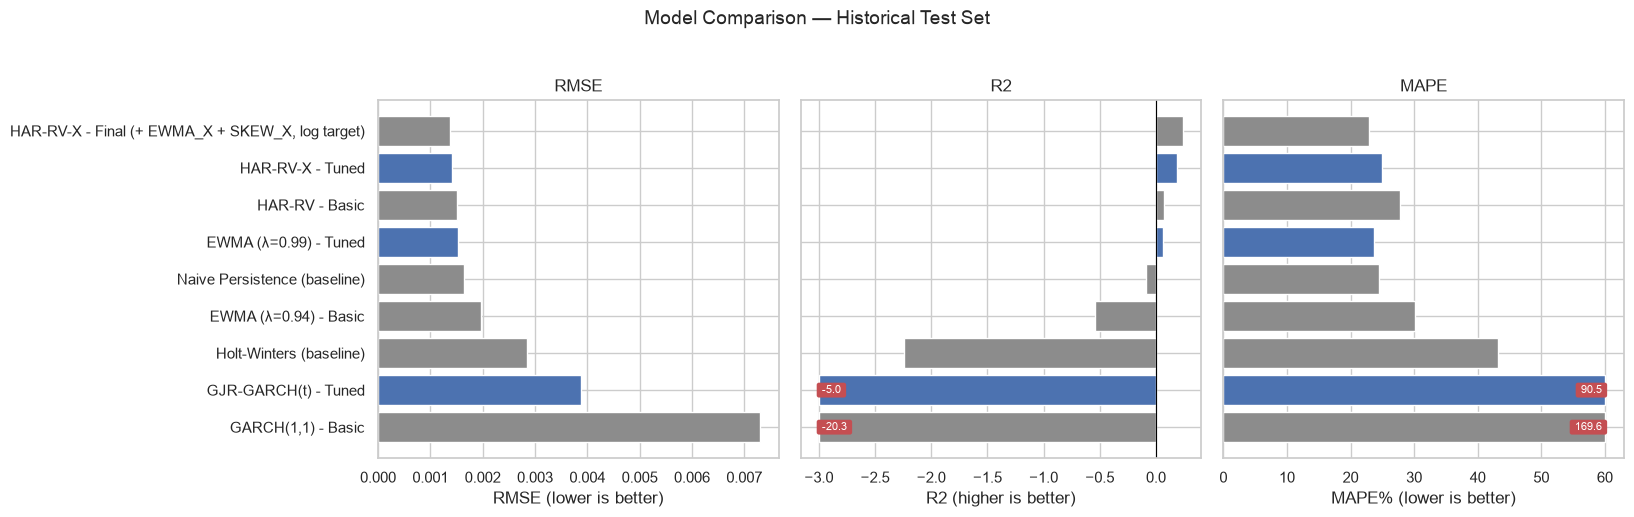

In [64]:
plot_metric_comparison(
    comparison_df, ['RMSE', 'R2', 'MAPE'], 'Model Comparison — Historical Test Set',
    clip={'R2': (-3, None), 'MAPE': (None, 60)}
)

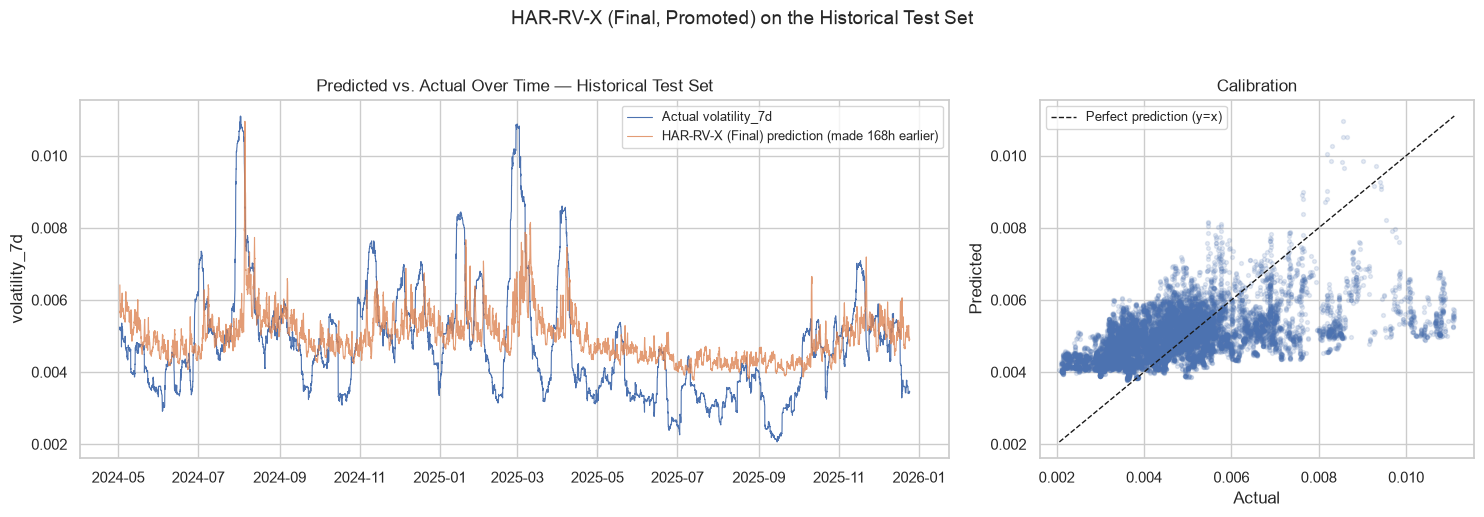

In [65]:
# Predicted vs. Actual over time, and a calibration scatter, for the historical-test-set winner
# (HAR-RV-X, Final/promoted - Section 6.2 above - it has its own slightly different
# date-aligned split from the other models, so its own dates are looked up here rather than
# reusing df_model['Date'].iloc[split_idx:]).
har_final_test_dates = df_model['Date'].loc[har_final_test.index]

fig, axes = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={'width_ratios': [2, 1]})

axes[0].plot(har_final_test_dates, har_final_test['target'], label='Actual volatility_7d', color='#4C72B0', linewidth=0.8)
axes[0].plot(har_final_test_dates, har_final_pred, label=f'HAR-RV-X (Final) prediction (made {HORIZON}h earlier)',
             color='#DD8452', linewidth=0.8, alpha=0.8)
axes[0].set_ylabel('volatility_7d')
axes[0].set_title('Predicted vs. Actual Over Time — Historical Test Set')
axes[0].legend(fontsize=9)

lims = [min(har_final_test['target'].min(), har_final_pred.min()), max(har_final_test['target'].max(), har_final_pred.max())]
axes[1].scatter(har_final_test['target'], har_final_pred, alpha=0.15, s=8, color='#4C72B0')
axes[1].plot(lims, lims, 'k--', linewidth=1, label='Perfect prediction (y=x)')
axes[1].set_xlabel('Actual')
axes[1].set_ylabel('Predicted')
axes[1].set_title('Calibration')
axes[1].legend(fontsize=9)

fig.suptitle('HAR-RV-X (Final, Promoted) on the Historical Test Set', fontsize=14, y=1.03)
plt.tight_layout()
plt.show()

In [66]:
best_row = comparison_df.iloc[0]
print(f"Best model (historical test set): {best_row['Model']}")
print(f"RMSE={best_row['RMSE']:.6f}  MAE={best_row['MAE']:.6f}  R2={best_row['R2']:.4f}")
print(f"\nImprovement over naive-persistence baseline: "
      f"{(1 - best_row['RMSE'] / comparison_df.loc[comparison_df['Model'].str.contains('Naive'), 'RMSE'].values[0]) * 100:.1f}% lower RMSE")
print("\nNote: this is the historical-test-set ranking. Check the Live Testing section's output "
      "(run over several days) for how the same models perform on real, never-before-seen data.")

Best model (historical test set): HAR-RV-X - Final (+ EWMA_X + SKEW_X, log target)
RMSE=0.001367  MAE=0.001036  R2=0.2419

Improvement over naive-persistence baseline: 17.1% lower RMSE

Note: this is the historical-test-set ranking. Check the Live Testing section's output (run over several days) for how the same models perform on real, never-before-seen data.


**Best model and justification:** *(fill in with the specific model name and numbers once the notebook is run — the cell above prints them automatically)*. Beyond raw RMSE, weigh: interpretability (HAR-RV-X's coefficients and GARCH's ω/α/β/leverage parameters, and EWMA's single λ, are all directly, theoretically meaningful — no model here is a black box), training/inference cost (all three are fast; GARCH and EWMA refit in seconds), and — uniquely enabled by this notebook's design — **how the historical-test ranking compares to the Live Testing section's real-world ranking** on the fixed, genuinely unseen live-test week. A model that wins on the historical split but underperforms live is a meaningfully different finding than one that wins on both.

## Discussion

**Business implications:** A working 7-day-ahead volatility forecast is directly usable by traders sizing positions, exchanges setting margin requirements, options desks pricing Black-Scholes σ, and portfolio managers timing entries/exits around expected turbulence. Because the target is continuous (not a high/low flag), it plugs directly into existing risk formulas.

**Limitations:**
- Volatility is inherently noisy and partly driven by information (news, regulatory action, exchange-specific events) absent from OHLCV history — there's a hard ceiling on achievable R² regardless of tuning.
- A separate engineering issue log (`docs/capstone-btc-volatility-issue-log.pdf`) catalogues every bug hit while building this project, organized by which stage of the pipeline each one actually belongs to - Data Collection, EDA, Feature Engineering, Modelling, Live Testing, Report/Deck Generation - rather than by when it was found. The pattern that falls out of that grouping: every bug in this project sits at a boundary between two stages, not inside one. The ATR and 5-minute-EWMA scale bugs (both above) are Feature-Engineering-into-Modelling boundary issues; the ElasticNet convergence failure in Check 14a below is the same failure pattern recurring a third time at that exact boundary; and `ewma_sigma()`'s NaN-propagation bug is filed under Modelling itself, not Data Collection, since the buggy recursion is the EWMA model's own code - it only surfaced during live scoring because that was the first time it ran over freshly-built, not-yet-training-cleaned features (a Modelling-into-Live-Testing boundary in effect). Zero bugs were found during EDA, for the mirror-image reason: it is a dead end in the pipeline, not a boundary, so nothing downstream silently trusts what it produces.
- GARCH and EWMA are evaluated with parameters frozen at their training-fitted (or backtested-selected) values, using a genuine HORIZON-step-ahead rolling-origin forecast walked across the test period (never re-estimated on test data) — the standard, leakage-free way to evaluate these models out-of-sample. A production system could go further with a periodic *walk-forward refit* (re-estimating parameters every N days as new data arrives), which this notebook does not attempt.
- GARCH specifically performs poorly at a 168-hour horizon: its forecast converges toward the long-run unconditional variance well before 168 hours are up, which turns out to be a systematically poor match for `volatility_7d`'s scale (see the Model Comparison R² values and MAPE). This is a structural property of GARCH at long horizons, documented in the econometrics literature, not a defect in this implementation - HAR-RV and EWMA, which both build in longer-horizon averaging by construction, handle the 168-hour horizon far better.
- Single-asset (BTC only): no cross-asset spillover signal from other coins is used, unlike an earlier multi-coin version of this project.
- RSI, EMA spread, Bollinger width, MACD, and trading volume were tested as additional HAR-RV-X regressors and did not improve performance (Robustness Checks, above) - they appear to carry momentum/direction information rather than volatility-magnitude information, which this target doesn't need.
- Ensembling HAR-RV-X with EWMA was tested with a properly cross-validated blend weight and did **not** survive validation, despite looking promising on a naive test-set peek (Robustness Checks, above). A follow-up genuine stacked ensemble (nested-CV meta-learner over HAR-RV-X, EWMA, and GARCH) did no better - it collapsed to R² = -0.53, with the meta-learner assigning GARCH (by far the worst individual model) the *highest* weight of the three, after a GARCH refit inside the CV loop failed to converge on at least one fold. Stacking cannot fix a structurally broken base model.
- XGBoost given the same lagged features plus explicit cyclical time features also did not beat HAR-RV-X (R² -0.19 vs. 0.184), nor did ETH's own realized volatility as a spillover regressor (R² 0.184 -> 0.112, likely collinearity with BTC's own RV regressors), nor did correcting `RV_day` for its own measurement error via realized quarticity (HAR-RV-Q - R² identical to four decimal places, traced to collinearity between the new interaction term and `RV_day` itself), nor did building the target from log returns instead of simple returns (R² 0.184 -> 0.155), nor did restricting training to 2020 onward (R² 0.184 -> 0.185, no meaningful difference - corroborating the data-integrity check's own finding that the pre-2020 gaps aren't harming training).
- An LSTM given the full technical indicator set as a genuine 72-hour sequence (Check 12) failed far more severely than XGBoost (R² -11.97) - diagnosed rather than left unexplained: even an "always predict the training mean" baseline scores R² -2.38 on the same test period, since the test period is measurably calmer than training, and the LSTM's own predictions are both wider-spread than the training data itself and include 606 physically impossible negative "volatility" values (nothing in a plain Dense(1) output head constrains non-negativity). HAR-RV-X's 30-day RV_month regressor's longer averaging window handles the same distribution shift far better.
- Alternative realized-volatility estimators (Parkinson, Garman-Klass, Rogers-Satchell) were tested as additional regressors, individually and combined - a genuinely different bet from the rejected momentum indicators, since these are properly grounded volatility proxies from the same literature HAR-RV comes from, not direction/momentum signals. None moved R² meaningfully (0.184 -> 0.185/0.177/0.182 individually, 0.184 combined), most likely because ATR_14 already captures most of the same range-based signal these estimators are built from.
- Check 14 tested three further ideas. Automated feature selection (ElasticNet over the full 54-feature Model Building matrix, rather than HAR-RV-X's own hand-picked regressors) first hit the exact same unscaled-feature-scale bug found twice before (ATR, 5-minute EWMA) - raw-dollar/raw-count features overwhelmed fractional ones, leaving the optimizer unable to converge and coefficients as small as 1e-9. Once fixed with a `StandardScaler` fit on the training split only, it converged cleanly (zero convergence warnings) but still underperformed HAR-RV-X (R² -0.21 vs. 0.184) - notably, it independently selected the *same kinds* of signal HAR-RV-X's regressors already use (ATR, lagged volatility), just as raw single-hour lags rather than HAR-RV-X's engineered multi-horizon (24h/168h/720h) averages, which a flat feature-selection pass has no way to construct on its own. Blending EWMA's own tuned sigma into HAR-RV-X as a regressor (distinct from the failed prediction-level ensemble above) gave a small improvement below the meaningful threshold (R² 0.184 -> 0.187), but realized skewness over the RV windows - capturing return-distribution asymmetry, information none of HAR-RV-X's magnitude-only regressors carry - is a genuine, above-threshold improvement on its own (R² 0.184 -> 0.198), best when combined with the EWMA regressor (R² 0.199). This is the first check since the original ATR fix to clear the improvement threshold on the historical split. Given the winsorizing lesson directly above, this one was deliberately validated on live data before any promotion - and unlike winsorizing, it held up (live R2 0.0610 -> 0.1217, a larger relative gain than the historical split). It was the first robustness check in this notebook's history to survive both bars - and, per Check 18 below, it combines with Check 17's log-target transform rather than duplicating it, so the version actually promoted into the kept model includes both.
- Winsorizing extreme hourly-return moves in HAR-RV-X's regressors also did not help once tested correctly (Robustness Checks, above) - worth flagging explicitly because the *first* version of this check contained a real bug (it accidentally winsorized the training target too, not just the regressors), which inflated the apparent result enough to look like a genuine improvement and get briefly promoted into the kept model before the error was caught and reversed. Left in as a documented example of exactly the kind of mistake this notebook's own methodology is designed to catch.
- Unlike checks 1-10, Check 11 (5-minute resolution) is a genuine, confirmed win - EWMA more than tenfolds its live R2 at 5-minute resolution, and HAR-RV-X scores about 1.3x its hourly kept-model R2 - that was deliberately kept in a separate scoped companion notebook rather than merged here, given the scale of infrastructure a full migration would require (GARCH's ~144x higher forecast cost at this resolution alone). The companion notebook has had Check 14's EWMA_X + SKEW_X regressors ported to its own HAR-RV-X, but not (yet) Checks 17/18's log(target) transform - so the hourly side currently carries one more validated improvement than the 5-minute side, which is part of why this ratio keeps shrinking each time the hourly model improves, independent of anything changing at 5-minute resolution itself.
- Two preprocessing-stage checks, distinct from every feature/model check above. Check 15 found that the 54-feature matrix handed to Check 4 (XGBoost) and Check 14a (ElasticNet) mixed non-stationary raw price/volume levels (`Open`, `High`, `Low`, `Close`, `Volume`, `ma_7d`, `ema_12`, `ema_26`, raw `atr_14`) with genuinely stationary features - a milder version of the same failure family as the ATR and Check-14a scale bugs, except `StandardScaler` doesn't fix it since the problem is regime-dependence, not units. Dropping those 9 columns (27 of 54 features left) meaningfully improved both checks (XGBoost R2 -0.19 -> 0.01; ElasticNet R2 -0.21 -> -0.03) without beating HAR-RV-X - confirming the non-stationary levels were genuinely diluting the signal, just not enough to close the gap to HAR-RV-X's engineered, multi-horizon regressors. Check 16 measured whether `volatility_7d`'s row-count (not time-aware) rolling window distorts results near the 28 known timestamp gaps (Check 10) - it does, substantially, on affected rows (up to 83.6% relative difference), but every affected row falls in 2017-2021 training-only history; zero fall inside the held-out test window, so it has no measurable effect on any number this notebook reports. Worth fixing for correctness in a production system, not adopted here since there's nothing to adopt.
- Check 17, prompted by an external thesis (Mishu, 2025) reporting much higher R2 using `ln(RV)` as its modeling target: does a genuine `log(x)` transform - not Check 8's `log1p(x)`, nearly a no-op for values this small - actually help here? Fit in log-space but always evaluated after back-transforming to the original scale (never in log-space itself, which would inflate the number in exactly the way that made the external comparison misleading in the first place). The result is real: R2 0.1840 -> 0.2342 historically (the second-largest gain in this notebook, after the ATR fix), and 0.1217 -> 0.1439 live - both comfortably above the 0.005 threshold. A retransformation-bias check (log-transform regression can systematically under-predict once back-transformed, via Jensen's inequality) found no such artifact - the log-transform model's predictions are actually less biased than the current kept model's, both historically and live. Check 18 then tested the obvious follow-up: does this combine with Check 14's EWMA_X + SKEW_X regressors, or fail to stack the way Check 7's stacked ensemble already did once in this notebook? It stacks: R2 0.1992 -> 0.2419 historically, 0.1217 -> 0.1779 live - the best result anywhere in this notebook, on both splits. This combination (6 regressors, log target) is what's now promoted into the kept HAR-RV-X model (see the "Final HAR-RV-X" cell in Model Building), superseding the raw-target 6-regressor version Check 14 alone had promoted.
- The live-test window (2026-01-02 through yesterday) is fixed at the moment this notebook is run, not continuously accumulating - re-running it later will naturally score more of the already-elapsed-but-not-yet-scoreable predictions near the end of the current window, and pick up a later window if the cached CSV is deleted first.

**Future improvements:**
- News/sentiment features via an LLM-scored headline pipeline.
- A proper periodic walk-forward refit for GARCH, EWMA, and Holt-Winters, rather than parameters frozen at their training-time values.
- Extending live testing to a longer, continuously-accumulating window rather than a single fixed period.
- A full production migration to 5-minute resolution (a scoped companion notebook already validated a meaningfully higher live R² for both HAR-RV-X and EWMA) - including GARCH, at far higher computational cost.
- On-chain metrics (exchange netflows, active addresses) as a genuinely independent information source, distinct from every price-history-derived feature tested so far.

## References & Appendix

**Data source:** [CCXT](https://docs.ccxt.com/) unified exchange API, pulling hourly OHLCV data from Binance (BTC/USDT).

**Libraries used:** `pandas`, `numpy`, `matplotlib`, `seaborn`, `scipy.stats`, `statsmodels`, `scikit-learn`, `arch`, `ccxt`, `joblib`.

**Key methodological references:**
- Corsi, F. (2009). *A Simple Approximate Long-Memory Model of Realized Volatility.* — HAR-RV model.
- Bollerslev, T. (1986). *Generalized Autoregressive Conditional Heteroskedasticity.* — GARCH model.
- Nelson, D. (1991). *Conditional Heteroskedasticity in Asset Returns: A New Approach.* — EGARCH, capturing the leverage effect.
- Glosten, L., Jagannathan, R., Runkle, D. (1993). *On the Relation between the Expected Value and the Volatility of the Nominal Excess Return on Stocks.* — GJR-GARCH.
- Holt, C. (1957) and Winters, P. (1960). — Exponential smoothing with trend and seasonality (Holt-Winters), used here as a seasonality-aware baseline.
- J.P. Morgan/Reuters (1996). *RiskMetrics — Technical Document* (4th ed.). — the EWMA volatility methodology and its λ=0.94 industry-standard decay factor.

**Artifacts produced by this notebook** (for reproducibility / grading):
- `btc_hourly_ohlcv.csv` — the fixed historical training dataset (as far back as Binance has, through 2026-01-01).
- `btc_hourly_live.csv` — the fixed live-test period (2026-01-02 through yesterday), fetched once.
- `live_test_predictions.csv` — every model's predictions for the live-test week, alongside the real outcomes (already known, since the window has elapsed).
- `models/` — saved GARCH spec, HAR-RV-X model, and EWMA's tuned lambda, all reloadable without retraining.